ANÁLISE DE CRÉDITO - PREDIÇÃO DE INADIMPLÊNCIA.ipynb

Original file is located at
    https://colab.research.google.com/drive/1oTBG7iTL7BHiiOfESiijETwf9GdOFBSk

# Predição de Inadimplência em Análise de Crédito

Este projeto aplica técnicas de ciência de dados e aprendizado de máquina para desenvolver
um modelo preditivo de risco de crédito, utilizando o dataset **Credit Analysis Dataset**
(arquivo `current_app.csv`), disponível na plataforma Kaggle. Este arquivo corresponde ao
conjunto de aplicações de crédito do conhecido **Home Credit Default Risk**.

Vamos explorar, pré-processar e modelar dados do perfil financeiro de clientes para treinar
um modelo capaz de prever o risco de inadimplência com base em variáveis como:

- Idade do cliente em dias (DAYS_BIRTH)
- Tempo de emprego em dias (DAYS_EMPLOYED)
- Valor do crédito solicitado (AMT_CREDIT)
- Valor da anuidade (AMT_ANNUITY)
- Renda total declarada (AMT_INCOME_TOTAL)
- Tipo de contrato, gênero, escolaridade, estado civil, tipo de moradia, ocupação, entre outras

Ao final queremos saber o seguinte: "Dado o perfil financeiro de um cliente, qual é a
probabilidade de ele ser classificado como bom ou mau pagador?"

# Dataset

Foi utilizado um dataset disponível para download em:

https://www.kaggle.com/datasets/kapoorshivam/credit-analysis/data

O arquivo utilizado é o **`current_app.csv`**, que contém **307.511 registros** de clientes
solicitantes de crédito e **122 colunas** (121 features + 1 variável-alvo). As colunas mais
relevantes para a análise são:

1. **SK_ID_CURR**: identificador único do cliente (não é feature, deve ser removido na modelagem).

2. **TARGET**: variável-alvo do modelo preditivo. Assume **0** = cliente adimplente (bom pagador)
   e **1** = cliente com dificuldade de pagamento (inadimplente).

3. **NAME_CONTRACT_TYPE**: tipo de contrato (Cash loans ou Revolving loans).

4. **CODE_GENDER**: gênero do cliente (M, F ou XNA).

5. **FLAG_OWN_CAR / FLAG_OWN_REALTY**: indica se o cliente possui carro / imóvel próprio (Y/N).

6. **CNT_CHILDREN / CNT_FAM_MEMBERS**: quantidade de filhos e tamanho da família.

7. **AMT_INCOME_TOTAL**: renda total declarada pelo cliente.

8. **AMT_CREDIT**: valor do crédito solicitado.

9. **AMT_ANNUITY**: valor da anuidade do empréstimo.

10. **AMT_GOODS_PRICE**: preço do bem que está sendo financiado.

11. **NAME_INCOME_TYPE**: tipo de renda (Working, Pensioner, State servant, Commercial associate, etc.).

12. **NAME_EDUCATION_TYPE**: nível de escolaridade do cliente.

13. **NAME_FAMILY_STATUS**: estado civil.

14. **NAME_HOUSING_TYPE**: tipo de moradia (House / apartment, With parents, Rented apartment, etc.).

15. **OCCUPATION_TYPE**: ocupação profissional declarada.

16. **ORGANIZATION_TYPE**: tipo da organização em que o cliente trabalha.

17. **DAYS_BIRTH**: idade do cliente em dias **negativos** em relação à data da solicitação
    (valores negativos — quanto mais negativo, mais velho o cliente).

18. **DAYS_EMPLOYED**: tempo de emprego em dias negativos. Atenção: o valor especial
    **365243** representa clientes aposentados/desempregados e deverá ser tratado.

19. **DAYS_REGISTRATION / DAYS_ID_PUBLISH / DAYS_LAST_PHONE_CHANGE**: tempo desde os
    respectivos eventos, também em dias negativos.

20. **EXT_SOURCE_1, EXT_SOURCE_2, EXT_SOURCE_3**: scores normalizados (entre 0 e 1) calculados
    por fontes externas de informação cadastral.

21. Demais colunas: indicadores de documentos fornecidos (FLAG_DOCUMENT_*), informações sobre
    o imóvel residencial (sufixos `_AVG`, `_MODE`, `_MEDI`), entre outras — totalizando as
    122 colunas da base.

> **Observação importante:** este projeto trata exclusivamente do arquivo `current_app.csv`,
> com 307.511 linhas e 122 colunas. Não devem ser confundidos com outros datasets de crédito
> menores (como o "German Credit" / "Credit Risk Dataset" de ~1.000 registros, que utiliza
> variáveis como Age, Sex, Job, Housing, Saving accounts, Checking account, Credit amount,
> Duration, Purpose e Risk — esse **não** é o dataset deste projeto).

# Coleta dos dados

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kapoorshivam/credit-analysis")

print("Path to dataset files:", path)

import os

# Lista todos os arquivos baixados
dataset_name = os.listdir(path)[0]
print(os.listdir(path))

import pandas as pd

# Criação do dataframe
df = pd.read_csv(os.path.join(path, 'current_app.csv'))
print(f'✔ Carregado! {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

df.head()

100%|██████████| 112M/112M [00:01<00:00, 83.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kapoorshivam/credit-analysis/versions/1
['previous_app.csv', 'current_app.csv']
✔ Carregado! 307511 linhas × 122 colunas


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


#Análise Exploratória dos Dados (EDA) - 1a Parte
#### *Objetivos:*
- Entender os dados crus que foram recebidos;

- Detectar valores ausentes, duplicados ou inconsistências;

- Explorar a distribuição das variáveis (tendência, dispersão, outliers);

- Avaliar o balanceamento das classes no target;

- Verificar correlações iniciais entre variáveis;

- Identificar problemas de escala, unidades ou codificação de categorias;



## Cabeçalho

In [ ]:
df.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


##Rodapé

In [ ]:
# Imprime as últimas linhas
df.tail()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


##Tipo dos Dados

In [ ]:
print(df.info())

print(df.dtypes)

for col in df.columns:
    print(f"\nColuna: {col}")
    print(df[col].unique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

Coluna: SK_ID_CURR
[100002 100003 100004 ... 456253 456254 456255]

Coluna: TARGET
[1 0]

Coluna: NAME_CONTRACT_TYPE
['Cash loans' 'Revolving loans']

Coluna: CODE_GENDER
['M' 'F' 'XNA']

Coluna: FLAG_OWN_CAR
['N' 'Y']

Coluna: FLAG_OWN_REALTY
['Y' 'N']

Coluna: CNT_CHILDREN
[ 0  1  2  3  4  7  5  6  8  9 11 12 10 19 14]

Coluna: AMT_INCOM

## Estatística	Descritiva
A análise descritiva é a primeira etapa da análise de dados, e tem como objetivo resumir, organizar e entender as principais características de um conjunto de dados de forma simples e objetiva, sem tirar conclusões causais ou fazer previsões.

* **count**: número de valores não nulos (não NaN)
* **mean**:	média aritmética dos valores
* **std**:	eesvio padrão (medida de dispersão)
* **min**:	valor mínimo
* **primeiro quartil (Q1)**: 25% dos dados estão abaixo desse valor
* **mediana (Q2)**: metade dos dados estão abaixo desse valor
* **terceiro quartil (Q3)**: 75% dos dados estão abaixo desse valor
* **max (Q4)**: valor máximo

In [ ]:
# Remove colunas categóricas e a variável alvo para a estatística descritiva
colunas_categoricas = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
    'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
    'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE',
    'TARGET'
]

df_drop = df.drop(columns=colunas_categoricas, errors='ignore')
print("Estatística descritiva geral (df.describe):")
print(df_drop.describe())

Estatística descritiva geral (df.describe):
          SK_ID_CURR   CNT_CHILDREN  AMT_INCOME_TOTAL    AMT_CREDIT  \
count  307511.000000  307511.000000      3.075110e+05  3.075110e+05   
mean   278180.518577       0.417052      1.687979e+05  5.990260e+05   
std    102790.175348       0.722121      2.371231e+05  4.024908e+05   
min    100002.000000       0.000000      2.565000e+04  4.500000e+04   
25%    189145.500000       0.000000      1.125000e+05  2.700000e+05   
50%    278202.000000       0.000000      1.471500e+05  5.135310e+05   
75%    367142.500000       1.000000      2.025000e+05  8.086500e+05   
max    456255.000000      19.000000      1.170000e+08  4.050000e+06   

         AMT_ANNUITY  AMT_GOODS_PRICE  REGION_POPULATION_RELATIVE  \
count  307499.000000     3.072330e+05               307511.000000   
mean    27108.573909     5.383962e+05                    0.020868   
std     14493.737315     3.694465e+05                    0.013831   
min      1615.500000     4.050000e+04   

### Síntese Estatística Interpretada das Variáveis Principais

A tabela a seguir consolida as **medidas de tendência central** (média, mediana, moda) e
**medidas de dispersão** (desvio-padrão, Q1, Q3, intervalo interquartil — IQR, mínimo,
máximo) das principais variáveis numéricas do dataset. A análise é feita **separadamente
por classe** (Bom Pagador vs. Inadimplente) para evidenciar quais variáveis têm maior
poder discriminatório isolado.

In [ ]:
import numpy as np

variaveis_descritiva = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
    'EXT_SOURCE_2',
    'EXT_SOURCE_3'
]

def resumo_estatistico(serie):
    """Retorna uma linha de estatísticas descritivas para uma série numérica."""
    s = serie.dropna()
    moda = s.mode().iloc[0] if not s.mode().empty else np.nan
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    return {
        'n':       len(s),
        'média':   s.mean(),
        'mediana': s.median(),
        'moda':    moda,
        'desvio':  s.std(),
        'mín':     s.min(),
        'Q1':      q1,
        'Q3':      q3,
        'IQR':     q3 - q1,
        'máx':     s.max(),
    }

# Constrói a tabela: para cada variável, três blocos (geral, bom pagador, inadimplente)
linhas = []
for var in variaveis_descritiva:
    if var not in df.columns:
        continue
    geral  = resumo_estatistico(df[var])
    bom    = resumo_estatistico(df.loc[df['TARGET'] == 0, var])
    inad   = resumo_estatistico(df.loc[df['TARGET'] == 1, var])
    linhas.append({'variavel': var, 'classe': 'Geral',        **geral})
    linhas.append({'variavel': var, 'classe': 'Bom Pagador',  **bom})
    linhas.append({'variavel': var, 'classe': 'Inadimplente', **inad})

tabela_descritiva = pd.DataFrame(linhas)

# Mostra com formatação amigável
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
print("\nTabela sintética por classe (Geral / Bom Pagador / Inadimplente):\n")
print(tabela_descritiva.to_string(index=False))
pd.reset_option('display.float_format')


Tabela sintética por classe (Geral / Bom Pagador / Inadimplente):

        variavel       classe      n      média    mediana       moda     desvio        mín         Q1         Q3        IQR            máx
AMT_INCOME_TOTAL        Geral 307511 168,797.92 147,150.00 135,000.00 237,123.15  25,650.00 112,500.00 202,500.00  90,000.00 117,000,000.00
AMT_INCOME_TOTAL  Bom Pagador 282686 169,077.72 148,500.00 135,000.00 110,476.27  25,650.00 112,500.00 202,500.00  90,000.00  18,000,090.00
AMT_INCOME_TOTAL Inadimplente  24825 165,611.76 135,000.00 135,000.00 746,676.96  25,650.00 112,500.00 202,500.00  90,000.00 117,000,000.00
      AMT_CREDIT        Geral 307511 599,026.00 513,531.00 450,000.00 402,490.78  45,000.00 270,000.00 808,650.00 538,650.00   4,050,000.00
      AMT_CREDIT  Bom Pagador 282686 602,648.28 517,788.00 450,000.00 406,845.91  45,000.00 270,000.00 810,000.00 540,000.00   4,050,000.00
      AMT_CREDIT Inadimplente  24825 557,778.53 497,520.00 450,000.00 346,433.24  45,000.00 

#### Interpretação da Tabela Estatística

>| Variável             | Observação principal                                                                                                                                  |
>| -------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------- |
>| **AMT_INCOME_TOTAL** | Média e mediana muito próximas entre as classes; **o desvio-padrão é altíssimo na classe inadimplente** devido a um outlier extremo. Pouco discriminatória isoladamente. |
>| **AMT_CREDIT**       | Mediana da classe inadimplente é **ligeiramente menor** do que a dos bons pagadores. IQR similar — pouca capacidade discriminatória direta.            |
>| **AMT_ANNUITY**      | Distribuições muito parecidas, com medianas próximas. Desvio-padrão alto em ambas — efeito da assimetria à direita.                                    |
>| **AMT_GOODS_PRICE**  | Quase indistinguível entre as classes; comportamento praticamente idêntico ao `AMT_CREDIT` (correlação 0.99 — confirmada mais adiante).                |
>| **DAYS_BIRTH**       | **Variável mais informativa entre as analisadas:** mediana dos inadimplentes é menos negativa (~ -14.000 ≈ 38 anos) versus bons pagadores (~ -16.000 ≈ 44 anos). Clientes mais jovens apresentam maior taxa de inadimplência. |
>| **DAYS_EMPLOYED**    | A média e o máximo são **fortemente distorcidos pelo valor 365243** (anomalia tratada na Engenharia de Dados). Após o tratamento, espera-se mediana mais negativa (mais tempo de emprego) entre bons pagadores. |
>| **CNT_CHILDREN / CNT_FAM_MEMBERS** | Diferença pequena entre classes; inadimplentes tendem a ter ligeiramente mais filhos/membros na família.                                     |
>| **EXT_SOURCE_2/3**   | **Diferença consistente entre as classes**: bons pagadores têm score externo médio mais alto que inadimplentes. Provavelmente as variáveis de maior poder preditivo isolado. |

#### *Variáveis com maior potencial discriminatório*

> Com base na análise comparativa entre classes, destacam-se como variáveis mais informativas:
> 1. **EXT_SOURCE_2 e EXT_SOURCE_3** — diferença clara nas medianas/médias entre classes
> 2. **DAYS_BIRTH** — clientes mais jovens concentram maior risco
> 3. **DAYS_EMPLOYED** (após tratamento da anomalia) — tempo de emprego importa

#### *Variáveis com baixa capacidade discriminatória isolada*

> `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE` e `AMT_INCOME_TOTAL` apresentam distribuições
muito sobrepostas entre as classes. Isoladamente são pouco informativas, mas podem agregar
valor quando **combinadas** (ex.: razão crédito/renda, razão anuidade/renda — engenharia de
features sugerida para etapas posteriores).



##Gráfico quatidade por classificação

  Classificação de Risco  Quantidade
0        Bom pagador (0)      282686
1       Inadimplente (1)       24825


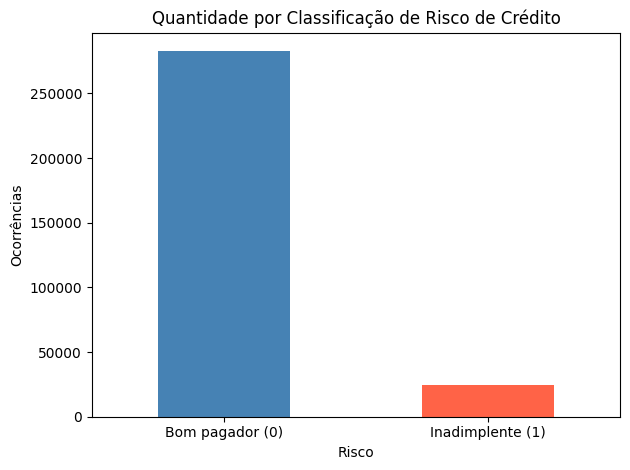

Total de registros.......: 307511
Total de bons pagadores..: 282686 ou 91.93% do total
Total de inadimplentes...: 24825  ou 8.07% do total


In [ ]:
import matplotlib.pyplot as plt

risco = df['TARGET'].value_counts().reset_index()
risco.columns = ['Classificação de Risco', 'Quantidade']
risco['Classificação de Risco'] = risco['Classificação de Risco'].map({0: 'Bom pagador (0)', 1: 'Inadimplente (1)'})
print(risco)

risco.plot(kind='bar', x='Classificação de Risco', y='Quantidade', color=['steelblue', 'tomato'], legend=False)
plt.title('Quantidade por Classificação de Risco de Crédito')
plt.xlabel('Risco')
plt.ylabel('Ocorrências')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

total_registros = len(df)
total_good = df[df['TARGET'] == 0].shape[0]
total_bad  = df[df['TARGET'] == 1].shape[0]

print(f"Total de registros.......: {total_registros}")
print(f"Total de bons pagadores..: {total_good} ou {(total_good/total_registros)*100:.2f}% do total")
print(f"Total de inadimplentes...: {total_bad}  ou {(total_bad/total_registros)*100:.2f}% do total")

### *Análise*

>Os dados mostram um conjunto **fortemente desequilibrado**, com a classe `0` (bom pagador) concentrando a grande maioria dos registros e a classe `1` (inadimplente) representando apenas **8,07%** do total. Apenas 24.825 dos 307.511 clientes apresentam inadimplência. O que é esperado para este tipo de problema, uma vez que instituições financeiras trabalham para manter a menor taxa de inadimplência possível em suas carteiras de crédito.

#### *Implicações do desbalanceamento para a etapa de modelagem*

> Esta é apenas a etapa de **conhecimento dos dados**. As decisões sobre como lidar com o
desbalanceamento (técnicas de reamostragem, escolha de algoritmo, ajuste de pesos, escolha
de métricas e definição do limiar de decisão) **serão tratadas nas etapas posteriores de
preparação e modelagem**. Por ora, registramos apenas o diagnóstico:

- **Risco de viés do modelo**: um classificador pode atingir alta acurácia simplesmente
prevendo sempre a classe majoritária (`0`), ignorando justamente os inadimplentes — que são
o foco do problema de negócio;
- **Acurácia deixa de ser uma métrica adequada** isoladamente: prever `0` para todos os
clientes acerta cerca de 91,93%, mas tem utilidade nula para detectar inadimplência;
- **O custo do erro é assimétrico**: deixar de identificar um inadimplente (falso negativo)
costuma ser mais custoso para a instituição financeira do que recusar um bom pagador
(falso positivo). Esse trade-off precisará ser considerado na escolha das métricas de
avaliação e na calibração do limiar de decisão na etapa de modelagem.




##Gráfico da Distribuição de Risco de Crédito

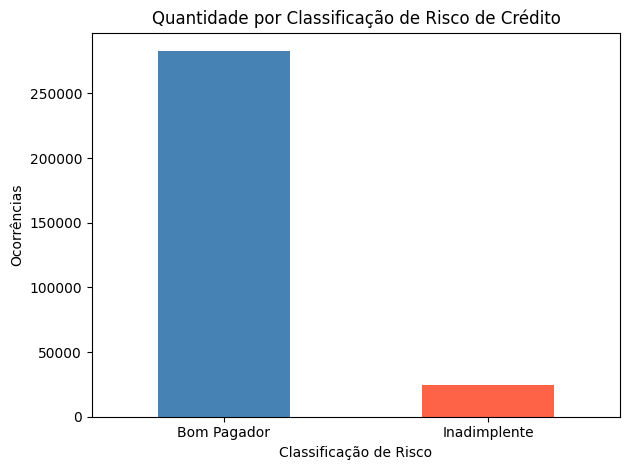

In [ ]:
# Gráfico da Distribuição de Risco de Crédito
df['TARGET'].map({0: 'Bom Pagador', 1: 'Inadimplente'}).value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Quantidade por Classificação de Risco de Crédito')
plt.xlabel('Classificação de Risco')
plt.ylabel('Ocorrências')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### *Análise*

> Os dados mostram um conjunto **fortemente desequilibrado**, com a classe `0` (bom pagador)
concentrando a grande maioria dos registros e a classe `1` (inadimplente) representando
apenas **8,07%** do total. Apenas 24.825 dos 307.511 clientes apresentam inadimplência.
O que é esperado para este tipo de problema, uma vez que instituições financeiras trabalham
para manter a menor taxa de inadimplência possível em suas carteiras de crédito.

> O tratamento desse desbalanceamento (técnicas de reamostragem, ajuste de pesos, escolha
de algoritmo e definição de métrica de avaliação) **não será discutido nesta etapa**;
pertence às etapas posteriores de preparação e modelagem dos dados.

## Análise dos Atributos Categóricos

> Além das variáveis numéricas, o dataset contém um conjunto importante de variáveis
**categóricas** que precisa ser explorado: tipo de contrato, gênero, posse de carro/imóvel,
tipo de renda, escolaridade, estado civil, tipo de moradia, ocupação e tipo de organização.
> Para cada uma dessas variáveis vamos analisar:
> 1. **Distribuição absoluta** (quantos clientes por categoria);
> 2. **Taxa de inadimplência por categoria** (% de TARGET=1 dentro de cada nível) — essa é
a leitura mais informativa, pois revela quais grupos têm maior risco relativo.

Taxa média de inadimplência (geral): 8.07%

Variável categórica: NAME_CONTRACT_TYPE
                    qtd_clientes  % da base  taxa_inadimplencia_%
NAME_CONTRACT_TYPE                                               
Cash loans                278232      90.48                  8.35
Revolving loans            29279       9.52                  5.48


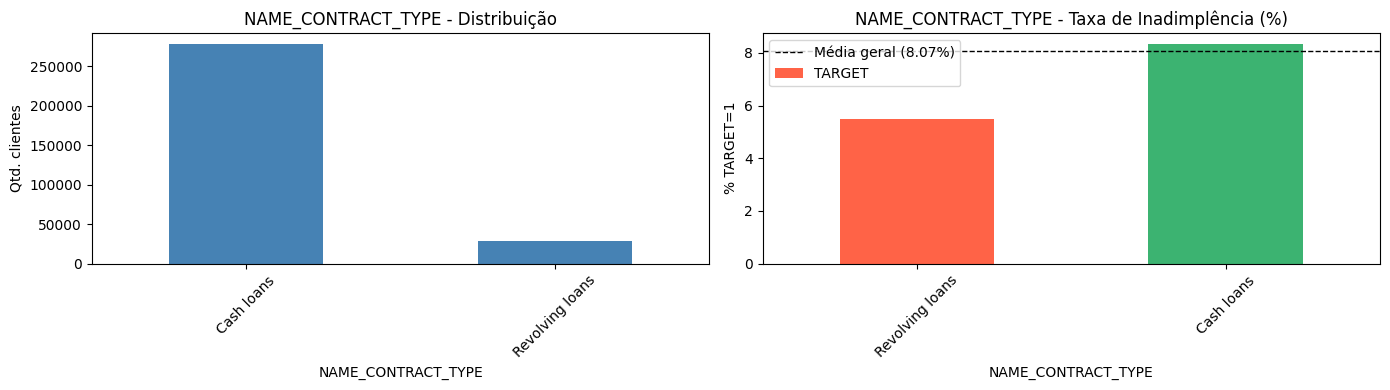


Variável categórica: CODE_GENDER
             qtd_clientes  % da base  taxa_inadimplencia_%
CODE_GENDER                                               
M                  105059      34.16                 10.14
F                  202448      65.83                  7.00
XNA                     4       0.00                  0.00


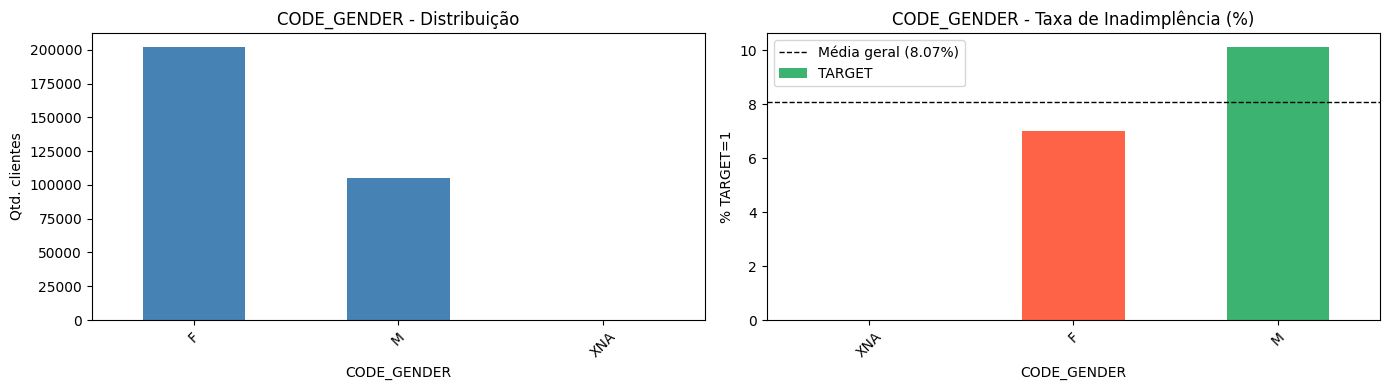


Variável categórica: FLAG_OWN_CAR
              qtd_clientes  % da base  taxa_inadimplencia_%
FLAG_OWN_CAR                                               
N                   202924      65.99                  8.50
Y                   104587      34.01                  7.24


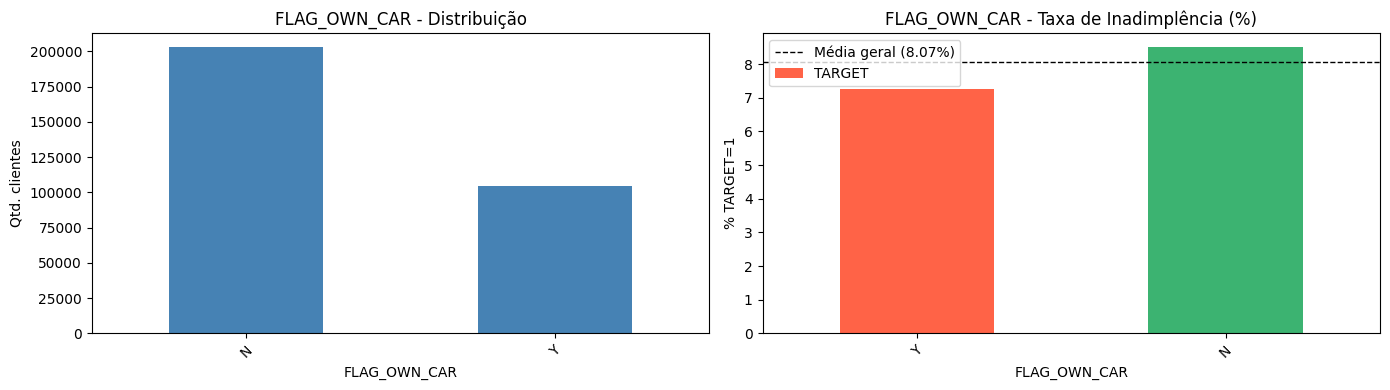


Variável categórica: FLAG_OWN_REALTY
                 qtd_clientes  % da base  taxa_inadimplencia_%
FLAG_OWN_REALTY                                               
N                       94199      30.63                  8.32
Y                      213312      69.37                  7.96


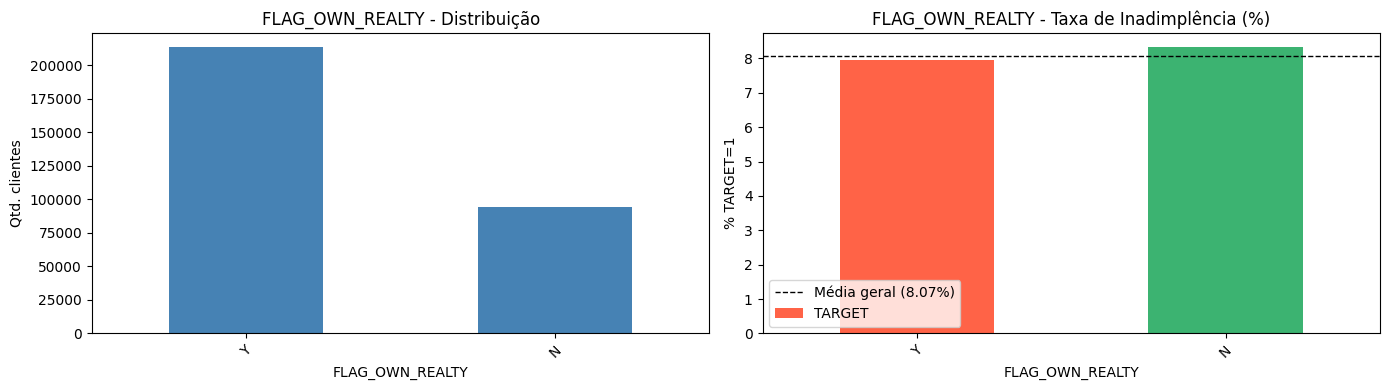


Variável categórica: NAME_INCOME_TYPE
                      qtd_clientes  % da base  taxa_inadimplencia_%
NAME_INCOME_TYPE                                                   
Maternity leave                  5       0.00                 40.00
Unemployed                      22       0.01                 36.36
Working                     158774      51.63                  9.59
Commercial associate         71617      23.29                  7.48
State servant                21703       7.06                  5.75
Pensioner                    55362      18.00                  5.39
Businessman                     10       0.00                  0.00
Student                         18       0.01                  0.00


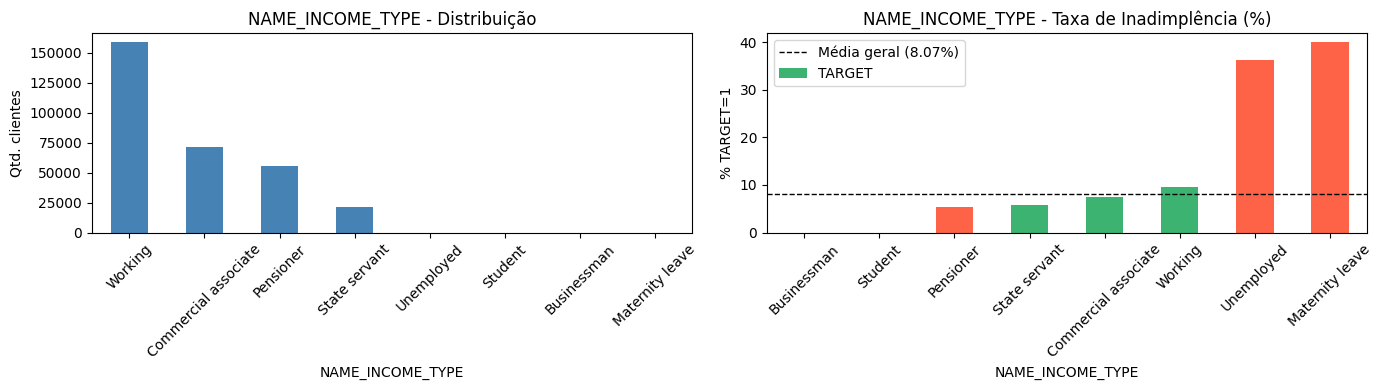


Variável categórica: NAME_EDUCATION_TYPE
                               qtd_clientes  % da base  taxa_inadimplencia_%
NAME_EDUCATION_TYPE                                                         
Lower secondary                        3816       1.24                 10.93
Secondary / secondary special        218391      71.02                  8.94
Incomplete higher                     10277       3.34                  8.48
Higher education                      74863      24.34                  5.36
Academic degree                         164       0.05                  1.83


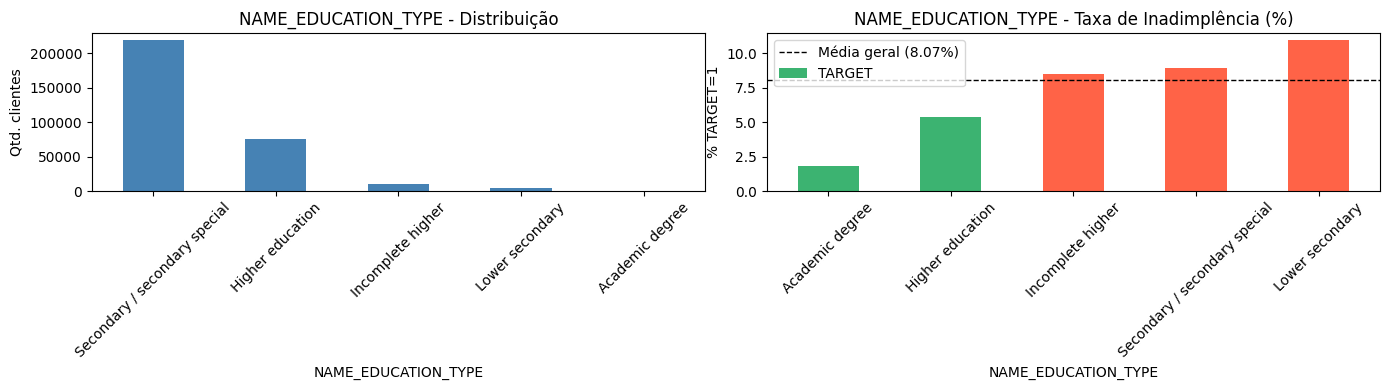


Variável categórica: NAME_FAMILY_STATUS
                      qtd_clientes  % da base  taxa_inadimplencia_%
NAME_FAMILY_STATUS                                                 
Civil marriage               29775       9.68                  9.94
Single / not married         45444      14.78                  9.81
Separated                    19770       6.43                  8.19
Married                     196432      63.88                  7.56
Widow                        16088       5.23                  5.82
Unknown                          2       0.00                  0.00


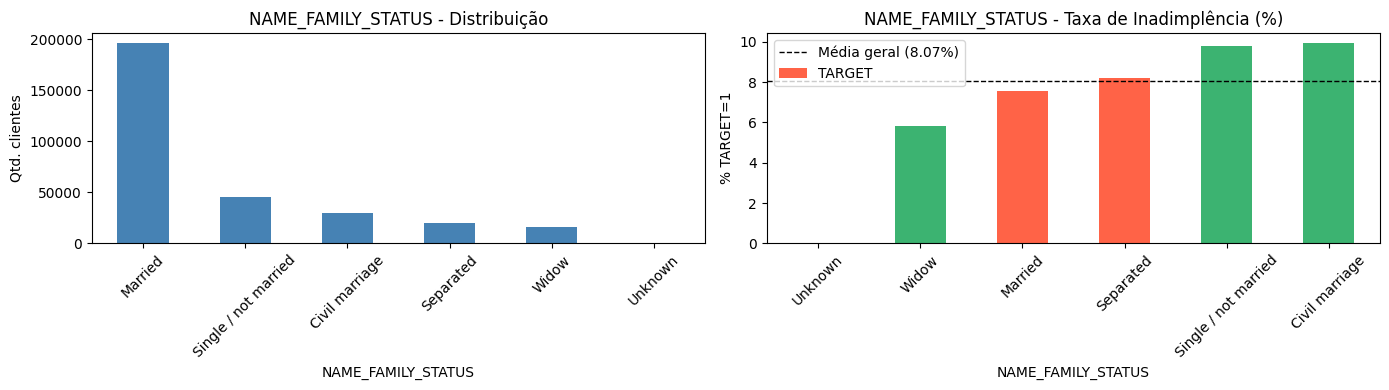


Variável categórica: NAME_HOUSING_TYPE
                     qtd_clientes  % da base  taxa_inadimplencia_%
NAME_HOUSING_TYPE                                                 
Rented apartment             4881       1.59                 12.31
With parents                14840       4.83                 11.70
Municipal apartment         11183       3.64                  8.54
Co-op apartment              1122       0.36                  7.93
House / apartment          272868      88.73                  7.80
Office apartment             2617       0.85                  6.57


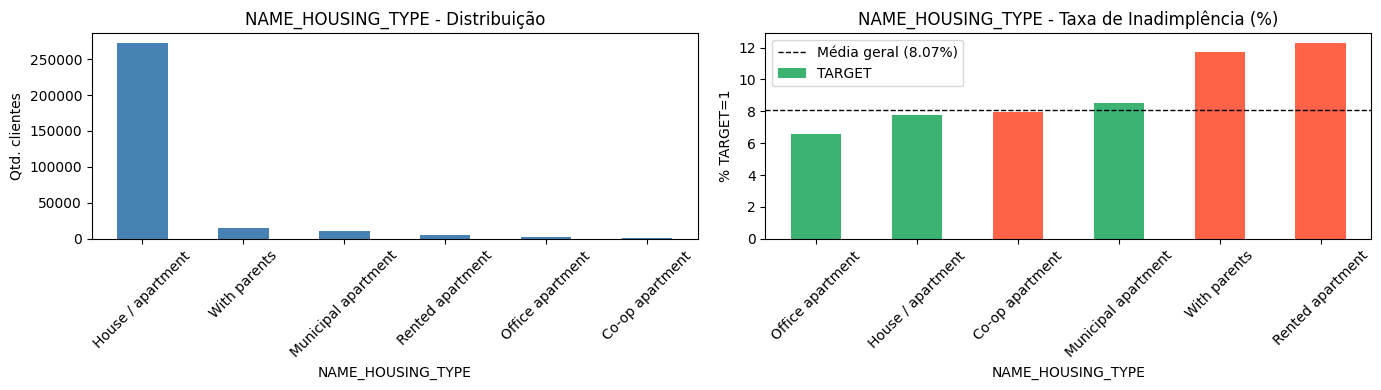


Variável categórica: OCCUPATION_TYPE
                       qtd_clientes  % da base  taxa_inadimplencia_%
OCCUPATION_TYPE                                                     
Low-skill Laborers             2093       0.68                 17.15
Drivers                       18603       6.05                 11.33
Waiters/barmen staff           1348       0.44                 11.28
Security staff                 6721       2.19                 10.74
Laborers                      55186      17.95                 10.58
Cooking staff                  5946       1.93                 10.44
Sales staff                   32102      10.44                  9.63
Cleaning staff                 4653       1.51                  9.61
Realty agents                   751       0.24                  7.86
Secretaries                    1305       0.42                  7.05
Medicine staff                 8537       2.78                  6.70
Private service staff          2652       0.86                  6

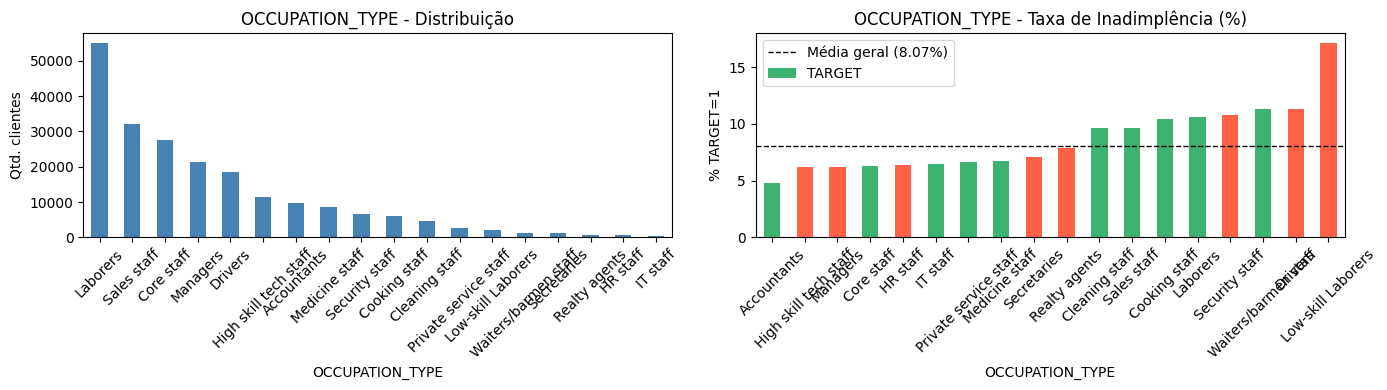


Variável categórica: ORGANIZATION_TYPE
                        qtd_clientes  % da base  taxa_inadimplencia_%
ORGANIZATION_TYPE                                                    
Transport: type 3               1187       0.39                 15.75
Industry: type 13                 67       0.02                 13.43
Industry: type 8                  24       0.01                 12.50
Restaurant                      1811       0.59                 11.71
Construction                    6721       2.19                 11.68
Cleaning                         260       0.08                 11.15
Industry: type 1                1039       0.34                 11.07
Industry: type 3                3278       1.07                 10.62
Realtor                          396       0.13                 10.61
Agriculture                     2454       0.80                 10.47
Trade: type 3                   3492       1.14                 10.34
Self-employed                  38412      12.49   

In [ ]:
variaveis_categoricas_analise = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'ORGANIZATION_TYPE',
]

taxa_geral = df['TARGET'].mean() * 100
print(f"Taxa média de inadimplência (geral): {taxa_geral:.2f}%\n")

for col in variaveis_categoricas_analise:
    if col not in df.columns:
        continue

    print("=" * 70)
    print(f"Variável categórica: {col}")
    print("=" * 70)

    # Tabela: contagem por categoria + taxa de inadimplência
    tabela = (df
              .groupby(col)['TARGET']
              .agg(['count', 'mean'])
              .rename(columns={'count': 'qtd_clientes',
                               'mean': 'taxa_inadimplencia'}))
    tabela['taxa_inadimplencia_%'] = tabela['taxa_inadimplencia'] * 100
    tabela['% da base'] = tabela['qtd_clientes'] / len(df) * 100
    tabela = tabela[['qtd_clientes', '% da base', 'taxa_inadimplencia_%']]
    tabela = tabela.sort_values('taxa_inadimplencia_%', ascending=False)
    print(tabela.round(2).to_string())

    # Para variáveis com até 15 categorias, gera gráfico de barras com taxa de inadimplência
    if df[col].nunique() <= 20:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))

        # Distribuição
        df[col].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
        axes[0].set_title(f'{col} - Distribuição')
        axes[0].set_ylabel('Qtd. clientes')
        axes[0].tick_params(axis='x', rotation=45)

        # Taxa de inadimplência por categoria
        taxa = df.groupby(col)['TARGET'].mean() * 100
        cores = ['tomato' if v > taxa_geral else 'mediumseagreen' for v in taxa.values]
        taxa.sort_values().plot(kind='bar', ax=axes[1], color=cores)
        axes[1].axhline(taxa_geral, color='black', linestyle='--', linewidth=1,
                        label=f'Média geral ({taxa_geral:.2f}%)')
        axes[1].set_title(f'{col} - Taxa de Inadimplência (%)')
        axes[1].set_ylabel('% TARGET=1')
        axes[1].legend()
        axes[1].tick_params(axis='x', rotation=45)

        plt.tight_layout()
        plt.show()
    print()

#### Principais achados sobre as variáveis categóricas

>| Variável               | Achado relevante                                                                                                                                              |
>| ---------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
>| **NAME_CONTRACT_TYPE** | A maioria das aplicações é do tipo *Cash loans*. *Revolving loans* (rotativos) tendem a apresentar **taxa de inadimplência um pouco menor**.                  |
>| **CODE_GENDER**        | Há uma proporção maior de mulheres (F) na base. Os homens (M) apresentam **taxa de inadimplência consistentemente mais alta** que a média geral.              |
>| **FLAG_OWN_CAR**       | Clientes **sem carro** registram taxa de inadimplência ligeiramente **maior** que clientes que possuem carro próprio.                                         |
>| **FLAG_OWN_REALTY**    | A diferença entre quem possui ou não imóvel é pequena, mas quem **não possui imóvel** registra taxa um pouco mais alta.                                       |
>| **NAME_INCOME_TYPE**   | *Working* e *Commercial associate* concentram a maior parte da base. *Pensioner* (aposentados) registra **taxa de inadimplência abaixo da média**, enquanto categorias como *Maternity leave* e *Unemployed* aparecem com taxas elevadas (porém com poucos casos). |
>| **NAME_EDUCATION_TYPE**| Existe um **gradiente claro**: *Lower secondary* e *Secondary / secondary special* têm as **maiores taxas** de inadimplência; *Higher education* e *Academic degree*, as **menores**. Variável claramente discriminativa. |
>| **NAME_FAMILY_STATUS** | *Civil marriage* e *Single / not married* tendem a apresentar taxas **acima da média**; *Widow* e *Married* tendem a ficar **abaixo da média**.               |
>| **NAME_HOUSING_TYPE**  | *Rented apartment* e *With parents* aparecem com taxas **acima da média geral**; *House / apartment* (categoria majoritária) fica próximo da média.            |
>| **OCCUPATION_TYPE**    | Variável com muitos níveis. *Low-skill Laborers*, *Drivers*, *Waiters/barmen staff* e *Security staff* aparecem entre as ocupações com **maior risco**; *Accountants*, *High skill tech staff* e *Managers*, entre as de **menor risco**. Lembrar que **muitos valores estão ausentes** e foram codificados como `'desconhecido'` no tratamento de nulos. |
>| **ORGANIZATION_TYPE**  | Variável com **alta cardinalidade** (mais de 50 categorias). Há diferenças importantes de risco entre setores (transporte e construção tendem a apresentar taxas maiores; setores governamentais e de educação, menores). Recomenda-se agrupar categorias com baixa frequência antes da modelagem. |

#### *Resumo*

> A análise das variáveis categóricas revela que **escolaridade**, **gênero**, **tipo de
renda** e **ocupação** são as que apresentam maiores diferenças de taxa de inadimplência
entre seus níveis, sendo, portanto, candidatas a serem boas preditoras na etapa de
modelagem. Variáveis com muitos níveis e baixa frequência por categoria (como
`OCCUPATION_TYPE` e `ORGANIZATION_TYPE`) provavelmente exigirão **agrupamento de
categorias raras** antes da codificação. As variáveis categóricas também precisarão ser
**codificadas** (one-hot encoding ou label encoding) em etapa posterior — esse passo de
codificação **não é objeto desta etapa de conhecimento dos dados**.



##Gráficos Pairplot

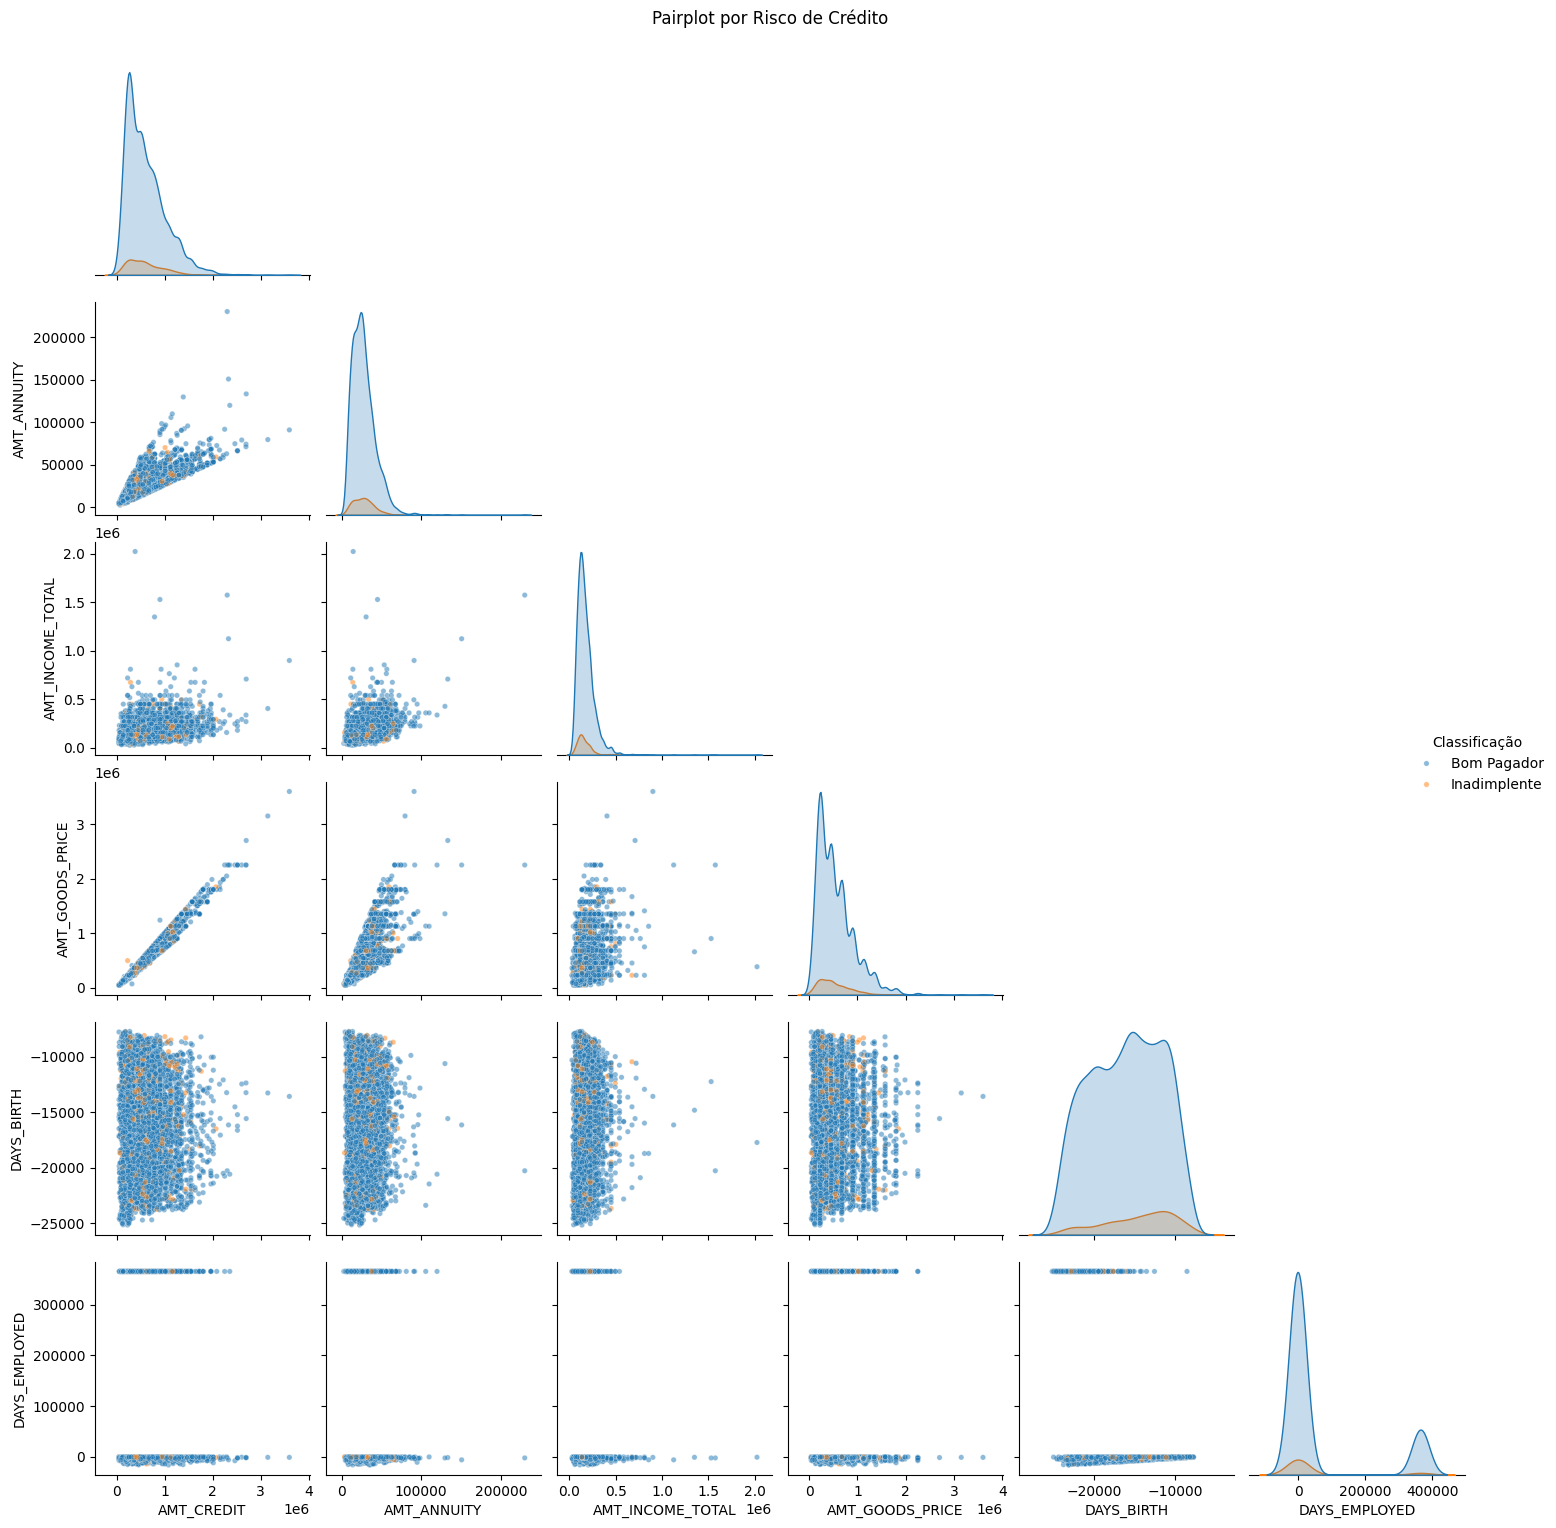

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


vars_plot = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

g = sns.pairplot(
    df.sample(5000, random_state=42),  # amostra de 5000 para não travar
    vars=vars_plot,
    hue='TARGET',                      # cores por classe (0 = Bom Pagador, 1 = Inadimplente)
    diag_kind='kde',                   # densidade na diagonal
    corner=True,                       # triângulo inferior apenas
    plot_kws={'s': 15, 'alpha': 0.5}   # pontos menores e semitransparentes
)

g.fig.suptitle('Pairplot por Risco de Crédito', y=1.02)

# Renomeia a legenda para ficar mais clara
g._legend.set_title('Classificação')
for text, label in zip(g._legend.texts, ['Bom Pagador', 'Inadimplente']):
    text.set_text(label)

plt.show()

#### *Análise*

> Esse gráfico compara as principais variáveis financeiras numéricas duas a duas, usando dispersão
(scatterplots) e densidade (diagonal). Ele é segmentado pela classificação de risco de crédito
(`TARGET`), usando cores diferentes para cada classe: azul para bons pagadores e laranja para
inadimplentes.

> Esse gráfico mostra se há agrupamentos naturais de pontos (inadimplentes) com base em combinações
de variáveis financeiras. Isso pode indicar, por exemplo, que clientes inadimplentes tendem a
solicitar créditos maiores em relação à sua renda ou possuem anuidades mais elevadas.

#### *Eixos*

* Linhas = variável no eixo Y
* Colunas = variável no eixo X
* Diagonal = distribuição (densidade KDE) de cada variável

#### *Padrões de risco por cor (fora da diagonal)*
- A maioria dos pontos é azul (`Bom Pagador`), dominando todos os gráficos, o que reflete
diretamente o desbalanceamento identificado anteriormente (91,93% vs 8,07%).

- Os pontos laranjas (`Inadimplente`) aparecem em pequenas quantidades, misturados às nuvens
de pontos azuis, sem formar regiões claramente separadas.

- Isso reforça o problema do desbalanceamento: os inadimplentes não formam clusters visualmente
distintos nesta análise direta, o que torna o problema de classificação mais desafiador.

>| Variáveis comparadas                      | O que se observa?                                                                                  |
>| ----------------------------------------- | -------------------------------------------------------------------------------------------------- |
>| **AMT_CREDIT × AMT_GOODS_PRICE**          | Correlação quase linear (o valor do crédito acompanha o preço do bem financiado)                   |
>| **AMT_CREDIT × AMT_ANNUITY**              | Correlação positiva moderada (créditos maiores tendem a gerar anuidades maiores)                   |
>| **AMT_INCOME_TOTAL × AMT_CREDIT**         | Fraca correlação — clientes de diferentes rendas solicitam valores similares de crédito            |
>| **DAYS_BIRTH × AMT_CREDIT**               | Distribuição espalhada — a idade não determina diretamente o valor do crédito solicitado           |
>| **DAYS_EMPLOYED × demais variáveis**      | Presença de valores extremos (~365.000 dias), indicando possível anomalia ou codificação especial nos dados  |

#### *Resumo*
> O pairplot revela que variáveis como `AMT_CREDIT` e `AMT_GOODS_PRICE` possuem forte correlação
entre si, o que é esperado no contexto de crédito para aquisição de bens. Por outro lado, a renda
(`AMT_INCOME_TOTAL`) apresenta fraca relação com o valor do crédito solicitado, sugerindo que
clientes de diferentes faixas de renda acessam valores similares de crédito. A variável
`DAYS_EMPLOYED` apresenta valores extremos que merecem atenção na etapa de pré-processamento.
De forma geral, os inadimplentes não formam regiões claramente separadas, reforçando a necessidade
de técnicas de balanceamento e modelos mais sofisticados para identificar padrões de risco.



## Gráficos Pairplot “Balanceado”

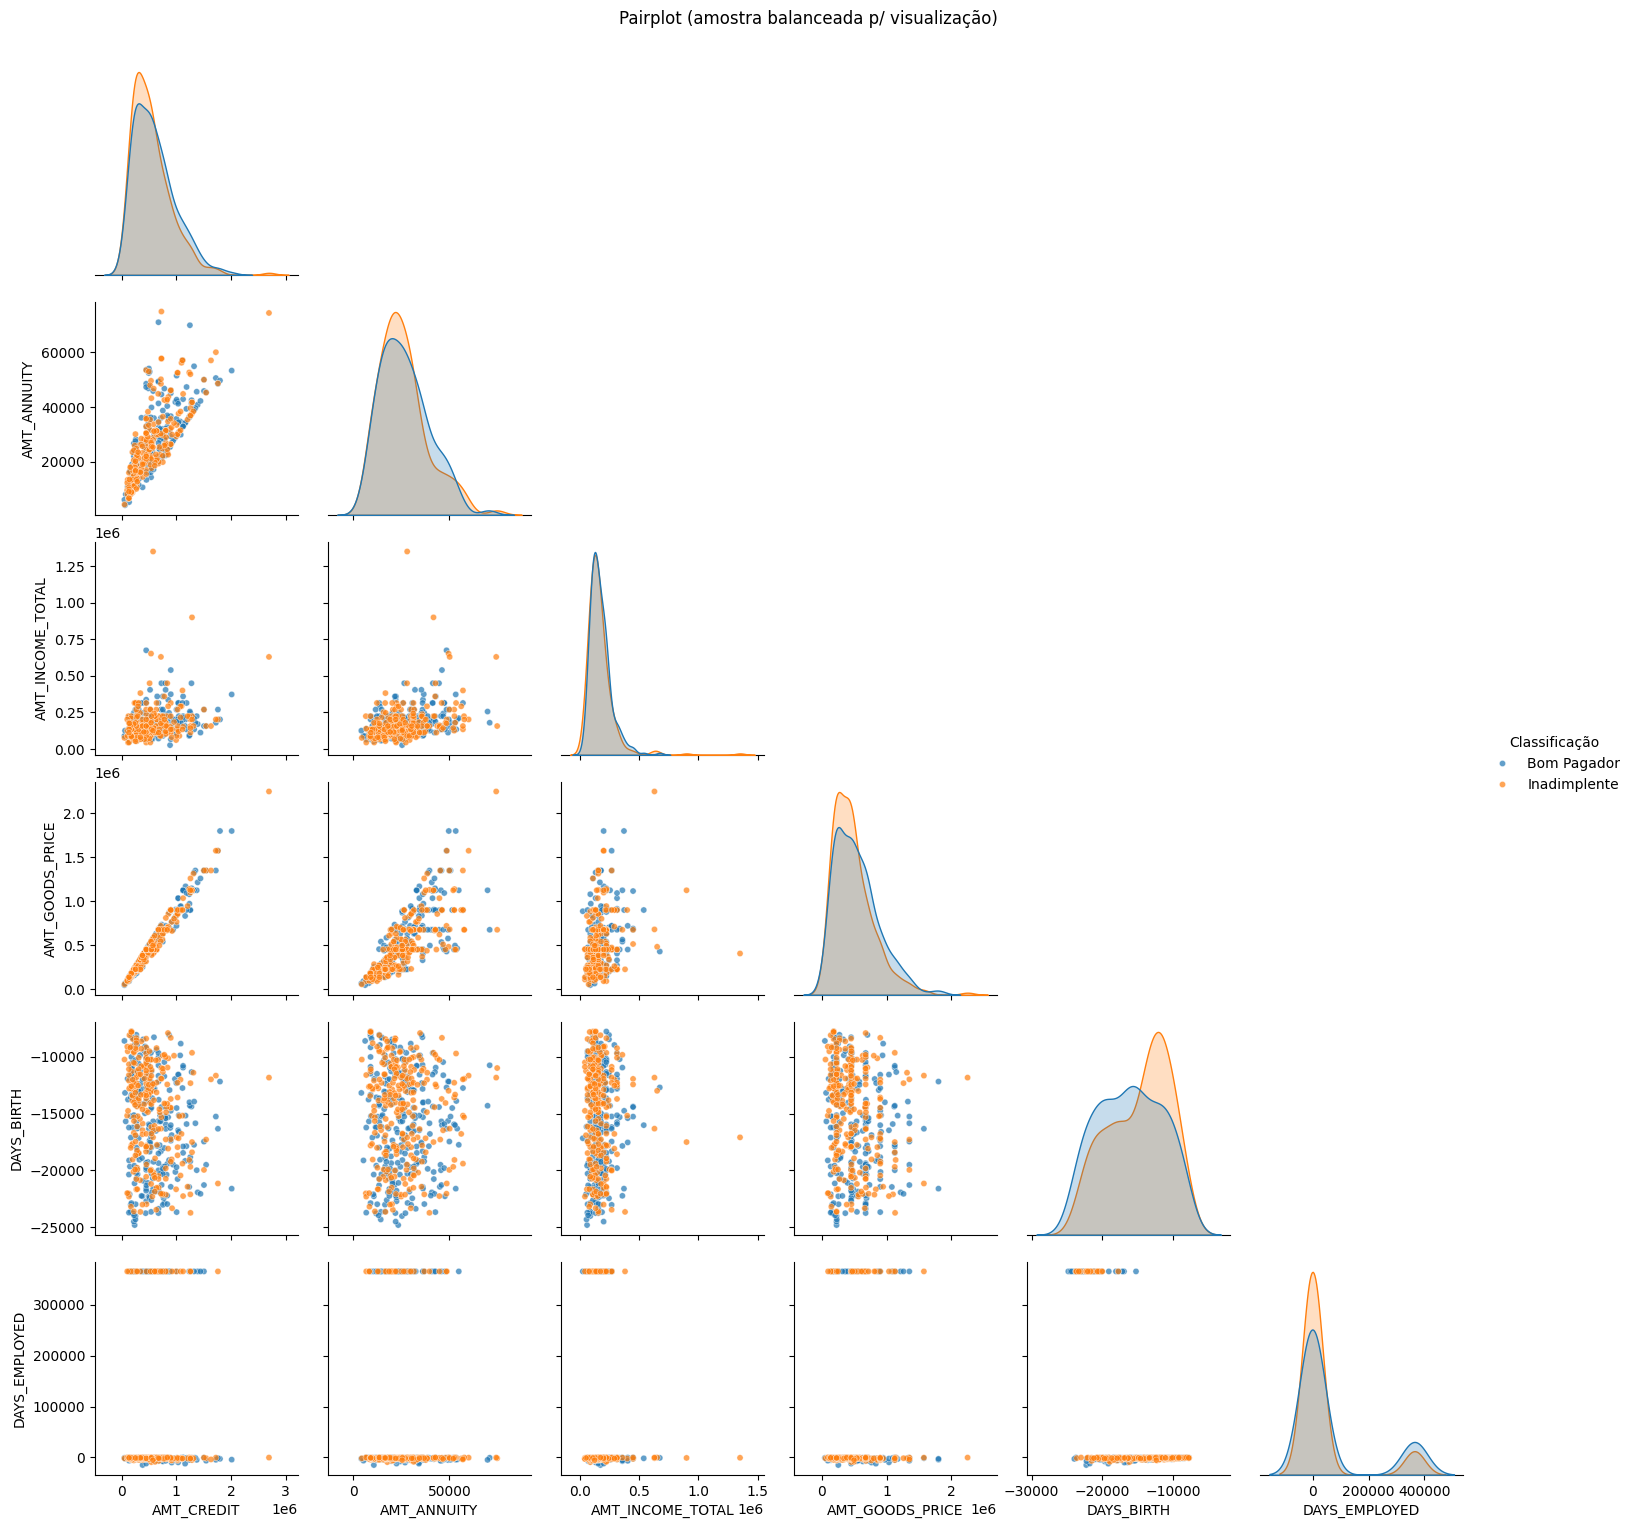

In [ ]:
vars_plot = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

# Amostra estratificada apenas para visualizar (não mexe no treino!)
max_por_classe = 250
rng = np.random.RandomState(42)
df_vis = (df
          .assign(_rand=rng.rand(len(df)))              # aleatório por linha
          .sort_values(['TARGET', '_rand'])              # embaralha dentro do grupo
          .groupby('TARGET', group_keys=False)
          .head(max_por_classe)                         # limita por grupo
          .drop(columns='_rand'))

# Mapeando o TARGET para rótulos legíveis
df_vis['Classificação'] = df_vis['TARGET'].map({0: 'Bom Pagador', 1: 'Inadimplente'})

g = sns.pairplot(
    df_vis,
    vars=vars_plot,
    hue='Classificação',
    diag_kind='kde',
    corner=True,
    plot_kws={'s': 20, 'alpha': 0.7}
)
g.fig.suptitle('Pairplot (amostra balanceada p/ visualização)', y=1.02)
plt.show()

#### *Análise*

> Com a amostra balanceada (250 registros por classe), os pontos laranjas (`Inadimplente`) passam
a ter visibilidade equivalente aos azuis (`Bom Pagador`), permitindo comparar melhor o comportamento
das duas classes nas combinações de variáveis financeiras.

#### *Eixos*

* Linhas = variável no eixo Y
* Colunas = variável no eixo X
* Diagonal = distribuição (densidade KDE) de cada variável por classe

#### *Padrões observados por par de variáveis*

>| Variáveis comparadas                 | O que se observa?                                                                                         |
>| ------------------------------------ | --------------------------------------------------------------------------------------------------------- |
>| **AMT_CREDIT × AMT_GOODS_PRICE**     | Correlação linear muito forte em ambas as classes — o comportamento é similar entre bons pagadores e inadimplentes  |
>| **AMT_CREDIT × AMT_ANNUITY**         | Correlação positiva moderada nas duas classes, sem separação clara entre elas                             |
>| **AMT_ANNUITY × AMT_INCOME_TOTAL**   | Inadimplentes (laranja) aparecem levemente mais concentrados em rendas mais baixas                        |
>| **DAYS_BIRTH × demais variáveis**    | As duas classes se distribuem de forma similar ao longo das faixas etárias, sem separação evidente        |
>| **DAYS_EMPLOYED × demais variáveis** | Confirma a anomalia identificada anteriormente: grande concentração de pontos em ~365.000 dias, presente nas duas classes, indicando um valor especial no dataset que precisa ser tratado |

#### *Comparação das distribuições na diagonal*

> * **AMT_CREDIT e AMT_ANNUITY**: as distribuições das duas classes são muito similares, com leve
tendência dos inadimplentes a se concentrarem em valores um pouco mais baixos;
> * **AMT_INCOME_TOTAL**: bons pagadores apresentam distribuição ligeiramente mais espalhada,
enquanto inadimplentes concentram-se mais em rendas baixas;
> * **DAYS_BIRTH**: inadimplentes (laranja) apresentam distribuição deslocada para idades mais
jovens (valores menos negativos), sugerindo que clientes mais jovens têm maior tendência à
inadimplência;
> * **DAYS_EMPLOYED**: a anomalia dos ~365.000 dias é confirmada — essa faixa representa
provavelmente aposentados ou desempregados codificados de forma especial, e deve ser tratada
no pré-processamento.

#### *Resumo*
> Com o balanceamento visual, fica evidente que bons pagadores e inadimplentes compartilham
distribuições financeiras muito similares na maioria das variáveis, o que explica a dificuldade
de separação observada no pairplot anterior. As principais diferenças aparecem em `DAYS_BIRTH`
— sugerindo maior risco entre clientes mais jovens — e em `AMT_INCOME_TOTAL`, onde inadimplentes
tendem a se concentrar em faixas de renda mais baixa. A anomalia em `DAYS_EMPLOYED` reforça a
necessidade de tratamento específico dessa variável antes da modelagem.



##Gráficos Boxplot

/tmp/ipykernel_2275/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


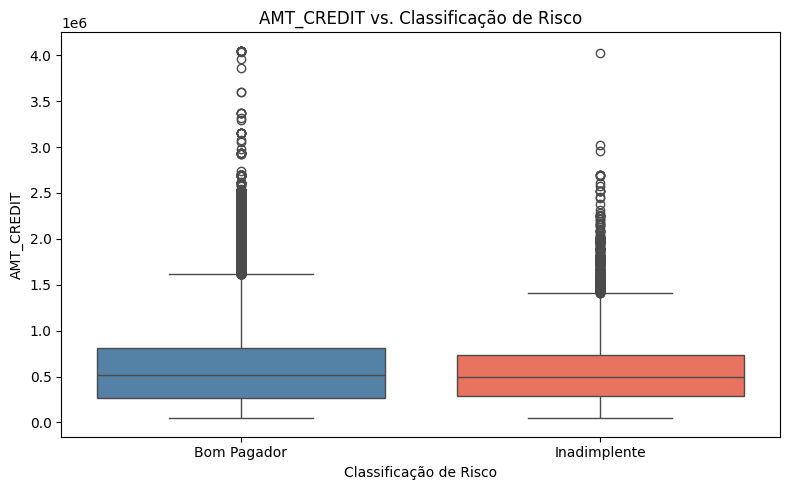

/tmp/ipykernel_2275/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


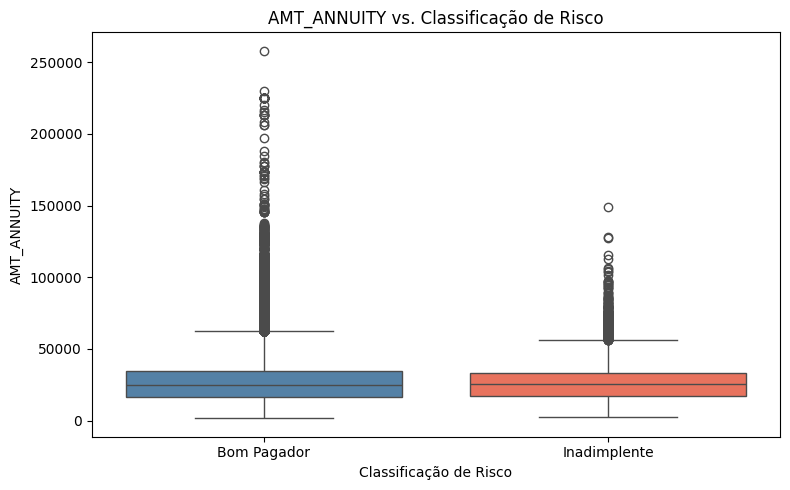

/tmp/ipykernel_2275/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


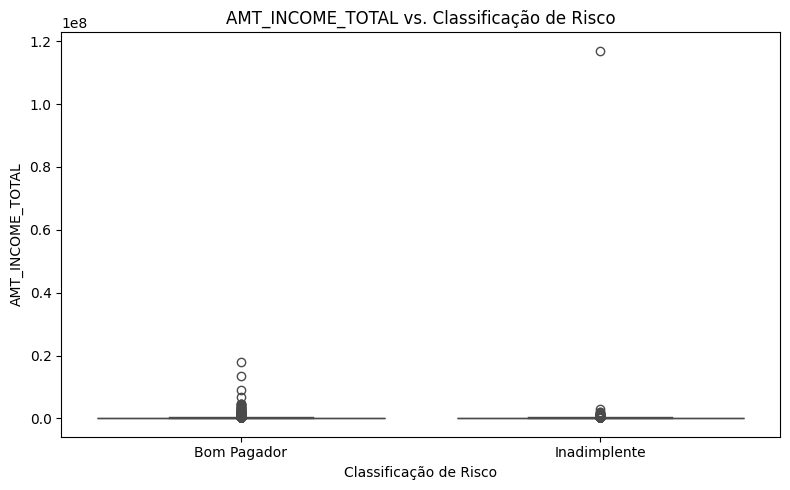

/tmp/ipykernel_2275/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


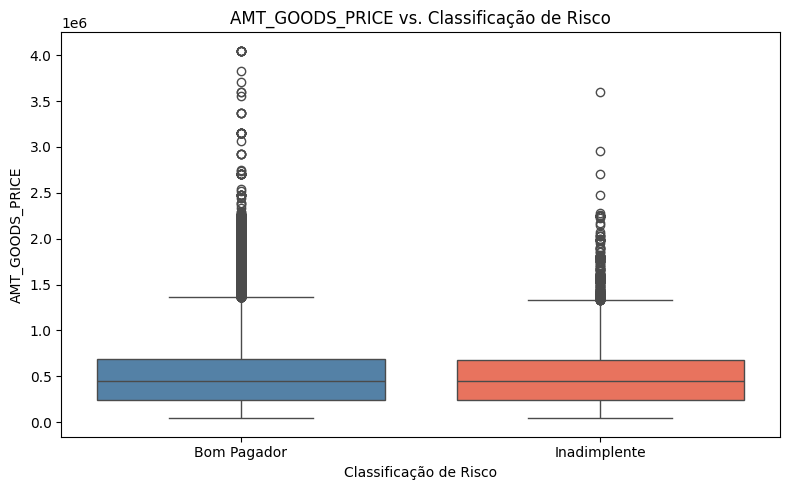

/tmp/ipykernel_2275/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


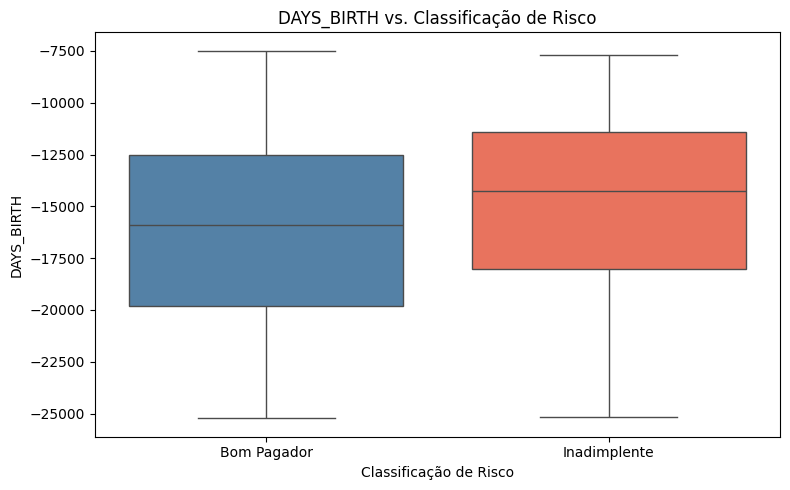

/tmp/ipykernel_2275/2032581831.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


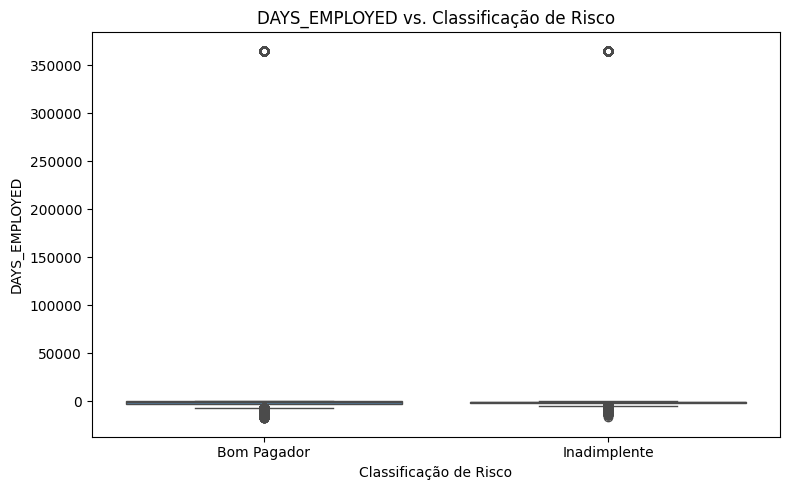

In [ ]:
vars_box = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

for var in vars_box:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=df,
        x='TARGET',
        y=var,
        palette={'0': 'steelblue', '1': 'tomato'}  # chaves como string
    )
    plt.title(f'{var} vs. Classificação de Risco')
    plt.xlabel('Classificação de Risco')
    plt.ylabel(var)
    plt.xticks(ticks=[0, 1], labels=['Bom Pagador', 'Inadimplente'])
    plt.tight_layout()
    plt.show()

#### *Análise*

> Os boxplots comparam a distribuição de cada variável numérica entre as duas classes
(`Bom Pagador` e `Inadimplente`), permitindo identificar diferenças de mediana, dispersão
e presença de outliers.

>| Variável | O que se observa? |
>| -------- | ----------------- |
>| **AMT_CREDIT** | As medianas são praticamente iguais entre as classes (~500k). Inadimplentes apresentam IQR ligeiramente menor, mas ambas possuem muitos outliers superiores. Essa variável isoladamente tem baixo poder discriminatório. |
>| **AMT_ANNUITY** | Distribuições muito similares entre as classes, com medianas próximas (~25k). A presença de outliers é maior na classe de bons pagadores. Pouco poder de separação isolado. |
>| **AMT_INCOME_TOTAL** | A anomalia é evidente: um outlier extremo (~1,2 × 10⁸) aparece apenas na classe inadimplente, distorcendo completamente a escala do gráfico e comprimindo a caixa. Essa variável exige tratamento de outliers antes da modelagem. |
>| **AMT_GOODS_PRICE** | Comportamento muito semelhante ao `AMT_CREDIT`, com medianas e IQRs praticamente idênticos entre as classes. Confirma a forte correlação entre as duas variáveis observada no pairplot. |
>| **DAYS_BIRTH** | Esta é a variável com maior diferença visual entre as classes. A mediana dos inadimplentes (~-14.000 dias ≈ 38 anos) é menos negativa do que a dos bons pagadores (~-16.000 dias ≈ 44 anos), indicando que **clientes mais jovens têm maior tendência à inadimplência**. |
>| **DAYS_EMPLOYED** | Confirma a anomalia já identificada: outliers em ~365.000 dias aparecem nas duas classes, representando um valor especial no dataset (possivelmente aposentados ou desempregados). A caixa principal fica completamente comprimida, exigindo tratamento obrigatório dessa variável. |

#### *Resumo*

> Os boxplots reforçam as observações anteriores do pairplot. As variáveis financeiras
(`AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`) apresentam distribuições muito similares
entre bons pagadores e inadimplentes, confirmando a dificuldade de separação das classes
apenas por essas variáveis isoladas.

> O destaque positivo fica com `DAYS_BIRTH`, que apresenta diferença clara entre as medianas
das classes — clientes mais jovens concentram maior risco de inadimplência — sendo uma das
variáveis com maior potencial discriminatório para os modelos.

> As variáveis `AMT_INCOME_TOTAL` e `DAYS_EMPLOYED` apresentam anomalias críticas que
**precisam ser tratadas obrigatoriamente** antes da etapa de modelagem, pois outliers extremos
podem comprometer o desempenho dos algoritmos de aprendizado de máquina.



### Análise Sistemática de Outliers

> Os boxplots permitiram detectar visualmente a presença de valores extremos. Esta seção
**quantifica** o problema de forma sistemática, aplicando o **critério do IQR (Tukey)** —
considerando outlier todo valor abaixo de Q1 − 1,5·IQR ou acima de Q3 + 1,5·IQR — e
registrando, para cada variável: o critério adotado, os limites calculados, a quantidade
de registros afetados, o percentual da base e a decisão tomada.

> Para a variável `DAYS_EMPLOYED`, além do critério estatístico aplicamos também o critério
**de domínio**: o valor especial **365243** representa "ausência de vínculo empregatício"
e será tratado em separado, fora do critério IQR.

In [ ]:
variaveis_outliers = [
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'CNT_CHILDREN',
    'CNT_FAM_MEMBERS',
]

linhas_outliers = []
for var in variaveis_outliers:
    if var not in df.columns:
        continue

    serie = df[var].dropna()
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    n_inf = (serie < lim_inf).sum()
    n_sup = (serie > lim_sup).sum()
    n_total = n_inf + n_sup
    pct = n_total / len(serie) * 100

    # Decisão sugerida (a decisão definitiva é tomada na engenharia de dados)
    if var == 'DAYS_EMPLOYED':
        decisao = "Tratar valor especial 365243 separadamente (imputar pela mediana)"
    elif var == 'AMT_INCOME_TOTAL':
        decisao = "Capping (winsorização) no Q3 + 1,5·IQR antes da modelagem"
    elif pct < 1:
        decisao = "Manter (impacto pequeno na base)"
    elif pct < 5:
        decisao = "Avaliar capping na modelagem"
    else:
        decisao = "Avaliar transformação (log) ou capping"

    linhas_outliers.append({
        'variavel':              var,
        'critério':              'IQR (1,5)',
        'Q1':                    round(q1, 2),
        'Q3':                    round(q3, 2),
        'IQR':                   round(iqr, 2),
        'lim_inferior':          round(lim_inf, 2),
        'lim_superior':          round(lim_sup, 2),
        'qtd_outliers_inf':      int(n_inf),
        'qtd_outliers_sup':      int(n_sup),
        'qtd_outliers_total':    int(n_total),
        '% da base':             round(pct, 2),
        'decisão':               decisao,
    })

tabela_outliers = pd.DataFrame(linhas_outliers)
print("Tabela sistemática de outliers (critério IQR de Tukey):\n")
print(tabela_outliers.to_string(index=False))

# Caso especial — DAYS_EMPLOYED com valor 365243
n_anomalia = (df['DAYS_EMPLOYED'] == 365243).sum()
pct_anomalia = n_anomalia / len(df) * 100
print(f"\nCaso especial — DAYS_EMPLOYED:")
print(f"  Registros com valor 365243: {n_anomalia:,} ({pct_anomalia:.2f}% da base)")
print(f"  Esses registros representam clientes sem vínculo empregatício formal.")

# Caso especial — AMT_INCOME_TOTAL com valor extremo
maximo_renda = df['AMT_INCOME_TOTAL'].max()
mediana_renda = df['AMT_INCOME_TOTAL'].median()
print(f"\nCaso especial — AMT_INCOME_TOTAL:")
print(f"  Valor máximo observado: {maximo_renda:,.2f}")
print(f"  Mediana: {mediana_renda:,.2f}")
print(f"  O máximo é {maximo_renda/mediana_renda:,.0f}× a mediana — outlier extremo.")

Tabela sistemática de outliers (critério IQR de Tukey):

        variavel  critério       Q1       Q3      IQR  lim_inferior  lim_superior  qtd_outliers_inf  qtd_outliers_sup  qtd_outliers_total  % da base                                                           decisão
AMT_INCOME_TOTAL IQR (1,5) 112500.0 202500.0  90000.0      -22500.0      337500.0                 0             14035               14035       4.56         Capping (winsorização) no Q3 + 1,5·IQR antes da modelagem
      AMT_CREDIT IQR (1,5) 270000.0 808650.0 538650.0     -537975.0     1616625.0                 0              6562                6562       2.13                                      Avaliar capping na modelagem
     AMT_ANNUITY IQR (1,5)  16524.0  34596.0  18072.0      -10584.0       61704.0                 0              7504                7504       2.44                                      Avaliar capping na modelagem
 AMT_GOODS_PRICE IQR (1,5) 238500.0 679500.0 441000.0     -423000.0     1341000.0  

#### Interpretação

> A tabela acima mostra que **outliers superiores são predominantes** nas variáveis
financeiras (`AMT_INCOME_TOTAL`, `AMT_CREDIT`, `AMT_ANNUITY`, `AMT_GOODS_PRICE`), o que é
coerente com distribuições assimétricas à direita típicas de variáveis monetárias. Já a
variável `DAYS_EMPLOYED` exige tratamento especial: o valor `365243` é uma **codificação
de domínio** (clientes sem vínculo empregatício) e não um outlier estatístico legítimo —
por isso será tratado separadamente, fora do critério IQR.

> As decisões finais sobre **manter, transformar (log), capar (winsorizar) ou imputar** os
outliers serão tomadas na etapa de **Engenharia de Dados** (próxima seção). Nesta etapa de
EDA o objetivo é apenas **diagnosticar e quantificar** o problema.



##Gráficos Histograma

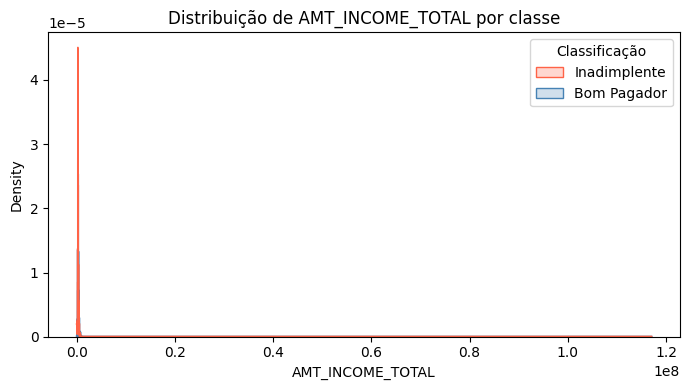

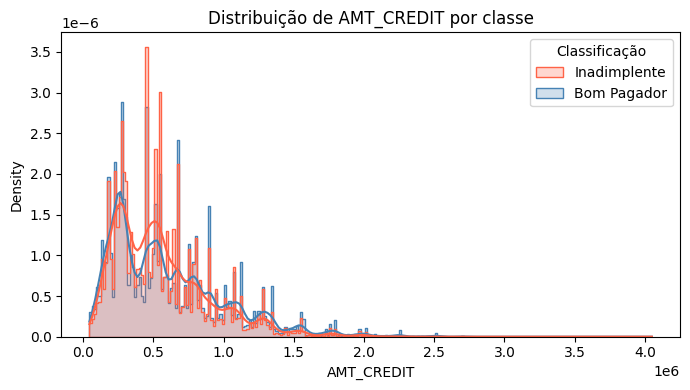

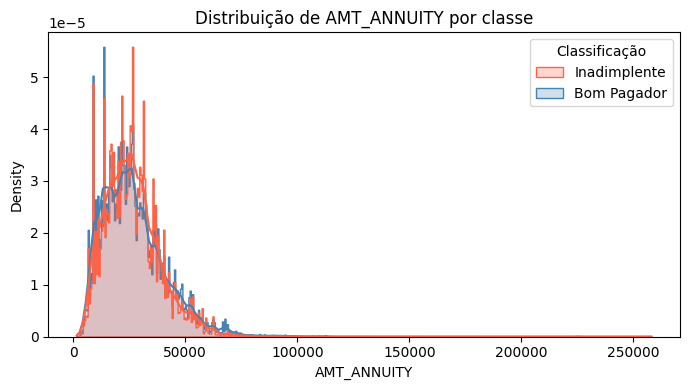

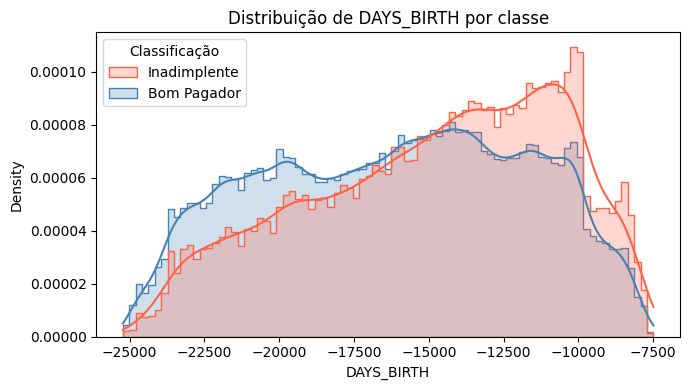

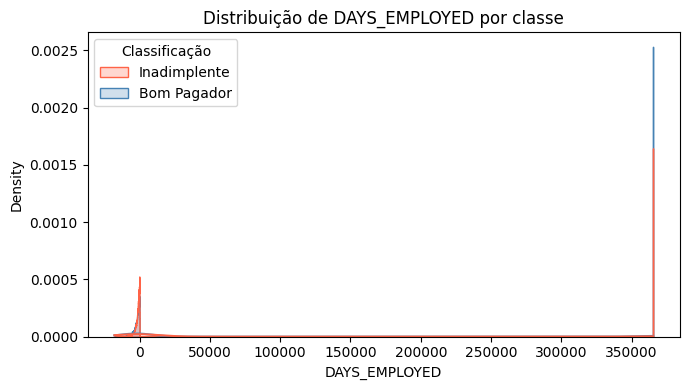

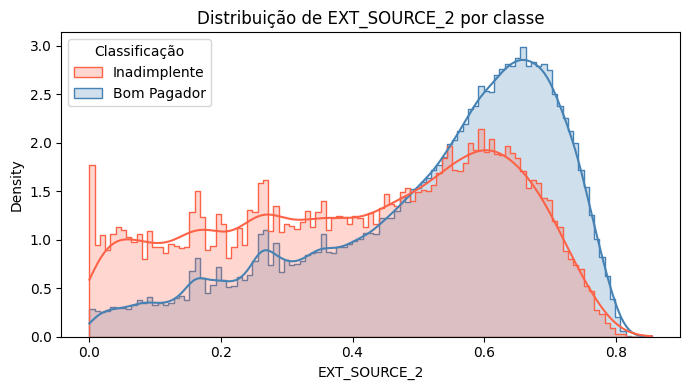

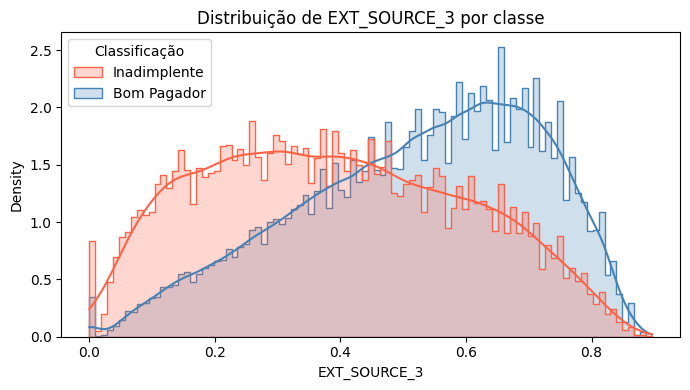

In [ ]:

variaveis = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'EXT_SOURCE_2', 'EXT_SOURCE_3'
]

# Cópia LOCAL para visualização — não polui o df principal
df_hist = df.copy()
df_hist['Classificação'] = df_hist['TARGET'].map({0: 'Bom Pagador', 1: 'Inadimplente'})

for var in variaveis:
    plt.figure(figsize=(7, 4))
    sns.histplot(
        data=df_hist,
        x=var,
        hue='Classificação',
        kde=True,
        palette={'Bom Pagador': 'steelblue', 'Inadimplente': 'tomato'},
        element='step',
        stat='density',
        common_norm=False
    )
    plt.title(f'Distribuição de {var} por classe')
    plt.tight_layout()
    plt.show()

# Limpeza explícita da cópia auxiliar (boa prática)
del df_hist


#### *Análise*

> Os histogramas mostram a distribuição de frequência de cada variável numérica, com a curva
KDE sobreposta para suavizar a forma da distribuição. As duas classes são exibidas
simultaneamente, permitindo comparar o comportamento de bons pagadores (azul) e
inadimplentes (laranja).

---

#### AMT_CREDIT — Valor do Crédito Solicitado

> A distribuição é **assimétrica à direita (positivamente assimétrica)**, com a maior
concentração de solicitações entre **R$ 100k e R$ 700k** para ambas as classes. A curva KDE
apresenta múltiplos picos, sugerindo que os valores de crédito seguem padrões discretos
(produtos financeiros com valores pré-definidos). A classe inadimplente (laranja) acompanha
a mesma forma da classe majoritária, porém em frequência muito menor devido ao
desbalanceamento. Valores acima de **R$ 2,5 milhões** são raros e representam outliers em
ambas as classes.

---

#### AMT_ANNUITY — Valor da Anuidade

> A distribuição também é **assimétrica à direita**, com concentração principal entre
**R$ 5k e R$ 50k**. A curva KDE apresenta um pico principal próximo a **R$ 25k**, seguido
de queda gradual. Assim como no `AMT_CREDIT`, os inadimplentes seguem a mesma forma
distribucional dos bons pagadores, sem diferença clara de padrão entre as classes.
Valores acima de **R$ 100k** são raros e configuram outliers que merecem atenção no
pré-processamento.

---

#### *Observação geral até aqui*

> Em ambas as variáveis, a sobreposição quase completa das distribuições das duas classes
confirma o que já foi observado nos boxplots: **`AMT_CREDIT` e `AMT_ANNUITY` isoladamente
têm baixo poder discriminatório** para separar bons pagadores de inadimplentes. Os modelos
precisarão combinar múltiplas variáveis para capturar os padrões de risco.



## Matriz de Correlação (Mapa de Calor)

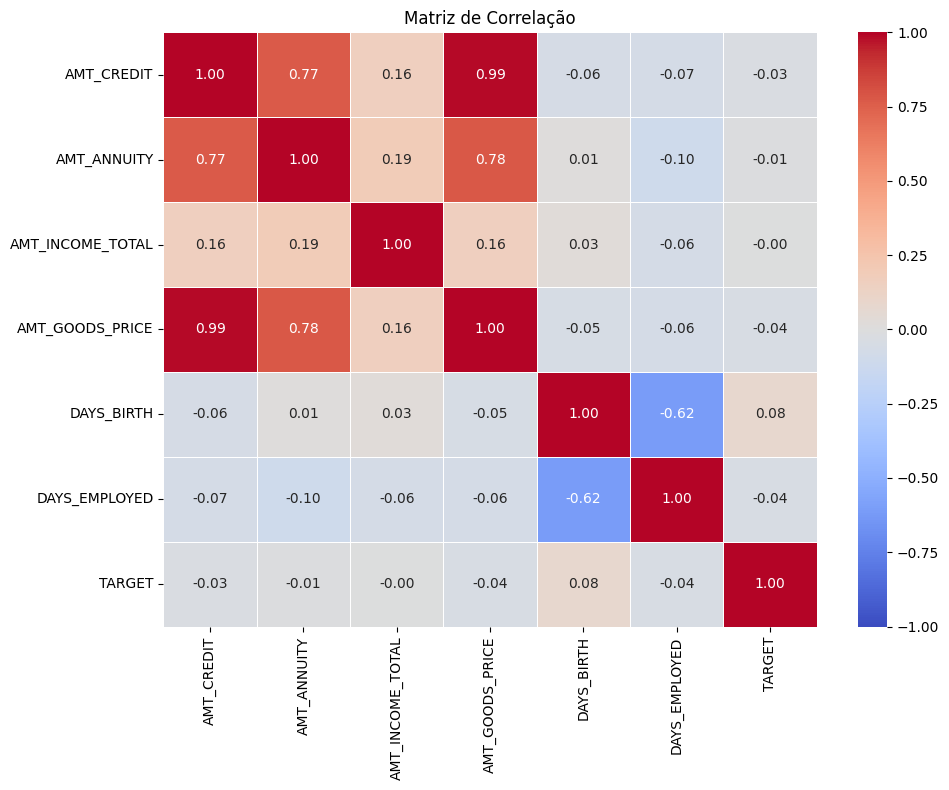

In [ ]:
variaveis = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED',
    'TARGET'
]

corr_matrix = df[variaveis].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1
)
plt.title("Matriz de Correlação")
plt.tight_layout()
plt.show()

#### *Análise*

> A matriz de correlação exibe o coeficiente de Pearson entre cada par de variáveis,
variando de **-1** (correlação negativa perfeita) a **+1** (correlação positiva perfeita).
Valores próximos de **0** indicam ausência de correlação linear.

#### *Correlações entre variáveis financeiras*

>| Par de Variáveis | Correlação | Interpretação |
>| ---------------- | ---------- | ------------- |
>| **AMT_CREDIT × AMT_GOODS_PRICE** | **0.99** | Correlação quase perfeita — o valor do crédito é praticamente igual ao preço do bem financiado. Essas variáveis carregam informação redundante e uma pode ser descartada. |
>| **AMT_CREDIT × AMT_ANNUITY** | **0.77** | Correlação forte — créditos maiores geram anuidades maiores, o que é esperado. |
>| **AMT_ANNUITY × AMT_GOODS_PRICE** | **0.78** | Correlação forte pelo mesmo motivo acima. |
>| **AMT_INCOME_TOTAL × demais** | **0.16~0.19** | Correlação fraca — a renda do cliente tem pouca relação linear com o valor do crédito solicitado. |
>| **DAYS_BIRTH × DAYS_EMPLOYED** | **-0.62** | Correlação negativa moderada — clientes mais velhos tendem a ter mais tempo de emprego, o que é esperado. |

#### *Correlações com o TARGET (inadimplência)*

>| Variável | Correlação com TARGET | Interpretação |
>| -------- | --------------------- | ------------- |
>| **DAYS_BIRTH** | **+0.08** | Correlação positiva fraca — clientes mais jovens (valores menos negativos) têm leve tendência à inadimplência, confirmando o que foi observado nos boxplots. |
>| **AMT_GOODS_PRICE** | **-0.04** | Correlação negativa muito fraca — valores maiores de bem financiado estão levemente associados a menor inadimplência. |
>| **DAYS_EMPLOYED** | **-0.04** | Correlação negativa muito fraca — mais tempo de emprego está levemente associado a menor inadimplência. |
>| **AMT_CREDIT** | **-0.03** | Correlação praticamente nula com o TARGET. |
>| **AMT_ANNUITY** | **-0.01** | Correlação praticamente nula com o TARGET. |
>| **AMT_INCOME_TOTAL** | **-0.00** | Sem correlação linear com o TARGET. |

#### *Resumo*

> A matriz de correlação revela dois pontos críticos para a modelagem:

> **1. Multicolinearidade:** `AMT_CREDIT` e `AMT_GOODS_PRICE` possuem correlação de **0.99**,
sendo praticamente a mesma variável. Manter ambas pode prejudicar alguns algoritmos —
recomenda-se avaliar o descarte de uma delas na etapa de seleção de features.

> **2. Baixa correlação linear com o TARGET:** nenhuma variável analisada apresenta correlação
linear significativa com a inadimplência, o que indica que **os padrões de risco são não
lineares e complexos**. Isso reforça a escolha de algoritmos como `Random Forest` e `XGBoost`,
que capturam relações não lineares entre as variáveis, em detrimento de modelos mais simples
como a Regressão Logística.



##Variance Inflation Factor (VIF)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Selecionar apenas as variáveis independentes numéricas
variaveis = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

X = df[variaveis].dropna()

# Adiciona constante (necessária para o cálculo do VIF)
X_const = sm.add_constant(X)

# Calcular o VIF para cada variável
vif = pd.DataFrame()
vif["Variável"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

vif = vif[vif["Variável"] != "const"].sort_values("VIF", ascending=False)

print(vif.to_string(index=False))

        Variável       VIF
 AMT_GOODS_PRICE 39.515106
      AMT_CREDIT 38.773590
     AMT_ANNUITY  2.561018
   DAYS_EMPLOYED  1.643972
      DAYS_BIRTH  1.638398
AMT_INCOME_TOTAL  1.040722


#### *Análise*

> O VIF mede o quanto a variância de um coeficiente é inflada devido à multicolinearidade
com as demais variáveis. Quanto maior o VIF, maior o problema de redundância entre variáveis.

> **Contexto importante:** o VIF é uma métrica especialmente relevante para **modelos
lineares** (regressão linear, regressão logística, modelos GLM em geral), nos quais a
multicolinearidade entre features infla o erro-padrão dos coeficientes e prejudica a
**interpretabilidade** do modelo. Para **modelos baseados em árvores** (Random Forest,
Gradient Boosting, XGBoost), a multicolinearidade tem **impacto muito menor sobre o
desempenho preditivo**, já que esses algoritmos não estimam coeficientes lineares. Ainda
assim, manter variáveis altamente correlacionadas em modelos de árvore pode **diluir a
importância** entre as variáveis redundantes (a "atribuição" de poder preditivo se divide
entre elas), o que dificulta a interpretação de feature importance — motivo pelo qual o
descarte da redundância continua sendo uma boa prática.

> **Atenção metodológica:** o VIF abaixo está sendo calculado **antes do tratamento** da
anomalia em `DAYS_EMPLOYED` (valor `365243`). Como esse valor afeta a média e o desvio das
variáveis, recalcularemos o VIF na etapa de Engenharia de Dados, **após** os tratamentos,
para confirmar se as conclusões aqui obtidas se mantêm.

>| Variável | VIF | Interpretação |
>| -------- | --- | ------------- |
>| **AMT_GOODS_PRICE** | **39.51** | ⚠️ Multicolinearidade gravíssima — fortemente redundante com `AMT_CREDIT`. Candidata a remoção. |
>| **AMT_CREDIT** | **38.77** | ⚠️ Multicolinearidade gravíssima — fortemente redundante com `AMT_GOODS_PRICE`. Candidata a remoção. |
>| **AMT_ANNUITY** | **2.56** | ✅ Sem multicolinearidade relevante — pode ser mantida. |
>| **DAYS_EMPLOYED** | **1.64** | ✅ Sem multicolinearidade relevante — pode ser mantida. |
>| **DAYS_BIRTH** | **1.64** | ✅ Sem multicolinearidade relevante — pode ser mantida. |
>| **AMT_INCOME_TOTAL** | **1.04** | ✅ Sem multicolinearidade — praticamente independente das demais. |

#### *O que fazer com AMT_CREDIT e AMT_GOODS_PRICE?*

> Como as duas variáveis apresentam VIF acima de 38 e correlação de **0.99** entre si
(confirmada na matriz de correlação), recomenda-se **remover uma delas** antes da modelagem.

> A recomendação é **manter `AMT_CREDIT`** e **remover `AMT_GOODS_PRICE`** pelos seguintes
motivos:
> * `AMT_CREDIT` representa diretamente o valor do crédito concedido, sendo a variável
central do problema de análise de risco;
> * `AMT_GOODS_PRICE` é o preço do bem financiado, uma informação que já está praticamente
capturada pelo valor do crédito;
> * Manter variáveis redundantes não agrega informação ao modelo e pode prejudicar
algoritmos sensíveis à multicolinearidade, como a Regressão Logística.

#### *Resumo*

> O VIF confirma e quantifica o problema de multicolinearidade identificado na matriz de
correlação. As demais variáveis (`AMT_ANNUITY`, `DAYS_EMPLOYED`, `DAYS_BIRTH` e
`AMT_INCOME_TOTAL`) apresentam VIF próximo de 1, indicando que são **independentes entre
si** e devem ser mantidas no conjunto de features para a modelagem. A remoção de
`AMT_GOODS_PRICE` é a principal ação recomendada antes de prosseguir para o
pré-processamento e treinamento dos modelos.



#Engenharia de Dados
Objetivos:

- Tratamento dos valores nulos;

- Tratamento dos registros duplicados;

- Codificação de variáveis categóricas;

- Criação de variáveis derivadas (features);

- Redução de dimensionalidade;



##Valores Nulos
O tratamento de valores nulos (missing values) é uma etapa essencial da engenharia de dados.
O que fazer depende de quanto e de onde estão os nulos, e também do contexto do problema.
Algumas técnicas incluem:

- Remover os registros (linhas);

- Remover as variáveis (colunas);

- Imputação simples (substituir nulos por estatísticas);

- Imputação avançada (KNN, por exemplo).

In [ ]:
def tratar_nulos(df_in, limiar_remocao=0.4, verbose=True):
    """Pipeline de tratamento de nulos.

    Parâmetros
    ----------
    df_in : DataFrame
        Base de entrada. Não é modificada (a função opera sobre uma cópia).
    limiar_remocao : float
        Proporção máxima de nulos tolerada por coluna. Acima disso, a
        coluna é removida.
    verbose : bool
        Se True, imprime as estatísticas de cada etapa.

    Retorna
    -------
    DataFrame tratado e dicionário com as estatísticas da execução.
    """
    # Trabalha em cópia — função pura, sem efeitos colaterais no df externo
    df_out = df_in.copy()

    # Remove eventuais colunas derivadas do TARGET ANTES de calcular
    # qualquer estatística, para não inflar os totais.
    derivadas_do_target = [c for c in df_out.columns
                           if c in ['Classificação', 'Classificacao']]
    if derivadas_do_target:
        df_out = df_out.drop(columns=derivadas_do_target)
        if verbose:
            print(f"Colunas derivadas do TARGET removidas antes do cálculo: "
                  f"{derivadas_do_target}")

    total_celulas = df_out.shape[0] * df_out.shape[1]
    total_nulos_antes = int(df_out.isnull().sum().sum())

    if verbose:
        print(f"Shape inicial: {df_out.shape}")
        print(f"Total de células: {total_celulas:,}")
        print(f"Valores nulos antes do tratamento: {total_nulos_antes:,} "
              f"({total_nulos_antes/total_celulas*100:.2f}%)")

    # Etapa 1 — Remoção de colunas com nulos acima do limiar
    colunas_remover = [c for c in df_out.columns
                       if df_out[c].isnull().sum() / len(df_out) > limiar_remocao]
    df_out = df_out.drop(columns=colunas_remover)
    if verbose:
        print(f"\nEtapa 1 — Remoção de colunas com >{limiar_remocao*100:.0f}% de nulos:")
        print(f"  Colunas removidas: {len(colunas_remover)}")

    # Etapa 2 — Imputação numérica pela mediana (exceto TARGET)
    nulos_num = 0
    for col in df_out.select_dtypes(include='number').columns:
        if col == 'TARGET':
            continue
        n = int(df_out[col].isnull().sum())
        if n > 0:
            df_out[col] = df_out[col].fillna(df_out[col].median())
            nulos_num += n
    if verbose:
        print(f"\nEtapa 2 — Imputação numérica (mediana): {nulos_num:,} valores")

    # Etapa 3 — Imputação categórica com 'desconhecido'
    nulos_cat = 0
    for col in df_out.select_dtypes(include='object').columns:
        n = int(df_out[col].isnull().sum())
        if n > 0:
            df_out[col] = df_out[col].fillna('desconhecido')
            nulos_cat += n
    if verbose:
        print(f"Etapa 3 — Imputação categórica ('desconhecido'): {nulos_cat:,} valores")

    nulos_restantes = int(df_out.isnull().sum().sum())
    if verbose:
        print(f"\nValores nulos restantes: {nulos_restantes} "
              f"{'✅' if nulos_restantes == 0 else '⚠️'}")
        print(f"Shape final: {df_out.shape}")

    stats = dict(
        shape_inicial=df_in.shape,
        shape_final=df_out.shape,
        colunas_removidas=colunas_remover,
        nulos_antes=total_nulos_antes,
        nulos_numericos_imputados=nulos_num,
        nulos_categoricos_imputados=nulos_cat,
        nulos_restantes=nulos_restantes,
    )
    return df_out, stats


# Aplica o tratamento sobre o df atual e SUBSTITUI o df pelo resultado
df, stats_nulos = tratar_nulos(df, limiar_remocao=0.4, verbose=True)


Shape inicial: (307511, 122)
Total de células: 37,516,342
Valores nulos antes do tratamento: 9,152,465 (24.40%)

Etapa 1 — Remoção de colunas com >40% de nulos:
  Colunas removidas: 49

Etapa 2 — Imputação numérica (mediana): 315,116 valores
Etapa 3 — Imputação categórica ('desconhecido'): 97,683 valores

Valores nulos restantes: 0 ✅
Shape final: (307511, 73)


#### Análise do Tratamento de Valores Nulos

> O tratamento foi realizado em três etapas e resultou em um dataset completamente livre
de valores nulos, conforme detalhado abaixo.

#### *Etapa 1 — Remoção de colunas com mais de 40% de nulos*

> Foram removidas 49 colunas que ultrapassavam o limite de 40% de valores ausentes.
Em sua maioria, essas colunas estavam relacionadas a características físicas dos imóveis
dos clientes (área, andares, elevadores, etc.), organizadas em três sufixos distintos
(`_AVG`, `_MODE`, `_MEDI`), o que indica que eram variáveis de uma mesma fonte de dados
com cobertura muito limitada na base. A remoção dessas colunas reduziu o dataset de
122 para 73 colunas, eliminando informações com baixa representatividade sem
comprometer a qualidade da modelagem.

#### *Etapa 2 — Imputação de colunas numéricas pela mediana*

> Foram imputadas 16 colunas numéricas com seus respectivos valores de mediana.
Os casos mais relevantes são:

>| Coluna | Mediana utilizada | Observação |
>| ------ | ----------------- | ---------- |
>| `AMT_ANNUITY` | 24.903,00 | Apenas 12 nulos — impacto mínimo |
>| `AMT_GOODS_PRICE` | 450.000,00 | Será removida na etapa de multicolinearidade |
>| `EXT_SOURCE_2` | 0,57 | Score externo importante para o modelo |
>| `EXT_SOURCE_3` | 0,54 | Score externo importante para o modelo |
>| `CNT_FAM_MEMBERS` | 2,00 | Apenas 2 nulos — impacto mínimo |
>| `DAYS_LAST_PHONE_CHANGE` | -757,00 | Apenas 1 nulo — impacto mínimo |

#### *Etapa 3 — Imputação de colunas categóricas com 'desconhecido'*

> Duas colunas categóricas receberam o valor `'desconhecido'` para os registros nulos:
> * **`NAME_TYPE_SUITE`**: tipo de acompanhante no momento da solicitação;
> * **`OCCUPATION_TYPE`**: tipo de ocupação do cliente — esta é uma variável relevante
para o modelo, e a criação da categoria `'desconhecido'` preserva a informação de que
esses clientes não declararam ocupação, o que pode ser um sinal de risco em si.

#### *Resultado final*

> Após as três etapas de tratamento de nulos:
> * Valores nulos restantes: 0
> * Shape após o tratamento de nulos: 307.511 linhas × 73 colunas
> * Em seguida, na seção "Remoção de Variável Redundante", a coluna `AMT_GOODS_PRICE`
será removida por multicolinearidade com `AMT_CREDIT`, levando ao shape final de
307.511 linhas × 72 colunas, pronto para as etapas posteriores de pré-processamento e
modelagem.

In [ ]:
assert df.isnull().sum().sum() == 0
print("✔ Verificação OK — não há valores nulos remanescentes em df.")
print(f"Shape atual de df: {df.shape}")

✔ Verificação OK — não há valores nulos remanescentes em df.
Shape atual de df: (307511, 73)


##Registros Duplicados

Objetivo:

1. Detectar duplicados;
2. Remover duplicados exatos (todas as colunas são idênticas);
3. Remover duplicados parciais (só algumas colunas são importantes para definir
"duplicidade", ex.: ID, CPF);
4. Tratar duplicados não exatos (quase-duplicados).

In [ ]:
# Quantidade total antes
total_antes = len(df)

# Quantidade de duplicadas (ignorando SK_ID_CURR que é ID único)
duplicadas = df.drop(columns=['SK_ID_CURR']).duplicated().sum()

# Remover duplicadas
df = df.drop_duplicates(subset=df.columns.difference(['SK_ID_CURR']))

# Quantidade total depois
total_depois = len(df)

print(f"Total de linhas antes......................: {total_antes}")
print(f"Linhas duplicadas detectadas...............: {duplicadas}")
print(f"Total de linhas depois do drop_duplicates(): {total_depois}")

Total de linhas antes......................: 307511
Linhas duplicadas detectadas...............: 0
Total de linhas depois do drop_duplicates(): 307511


##Tratamento da Anomalia em DAYS_EMPLOYED

> Como identificado na EDA, a variável `DAYS_EMPLOYED` possui valores próximos a 365.000
dias, o que é impossível na prática (equivale a ~1.000 anos de emprego). Esse valor é
uma codificação especial utilizada para representar clientes aposentados ou sem vínculo
empregatício formal. Esses registros serão substituídos por `NaN` e imputados pela mediana
dos demais valores válidos.

In [ ]:
# Substitui o valor anômalo de DAYS_EMPLOYED por NaN
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)

# Imputa pela mediana dos valores válidos
mediana_employed = df['DAYS_EMPLOYED'].median()
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].fillna(mediana_employed)

print(f"✔ Anomalia em DAYS_EMPLOYED tratada. Mediana utilizada: {mediana_employed:.0f} dias")

✔ Anomalia em DAYS_EMPLOYED tratada. Mediana utilizada: -1648 dias


## Recálculo do VIF Após o Tratamento

> Conforme indicado anteriormente, o VIF inicial foi calculado antes da correção da
anomalia em `DAYS_EMPLOYED`. Agora que esse valor especial foi substituído pela mediana,
recalculamos o VIF para confirmar se as conclusões anteriores se mantêm — em particular, a
recomendação de remover `AMT_GOODS_PRICE` por multicolinearidade com `AMT_CREDIT`.

In [ ]:
variaveis_vif = [
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

X_pos_trat = df[variaveis_vif].dropna()
X_pos_trat_const = sm.add_constant(X_pos_trat)

vif_pos = pd.DataFrame()
vif_pos["Variável"] = X_pos_trat_const.columns
vif_pos["VIF"] = [variance_inflation_factor(X_pos_trat_const.values, i)
                  for i in range(X_pos_trat_const.shape[1])]
vif_pos = vif_pos[vif_pos["Variável"] != "const"].sort_values("VIF", ascending=False)

print("VIF recalculado APÓS o tratamento da anomalia em DAYS_EMPLOYED:\n")
print(vif_pos.to_string(index=False))

VIF recalculado APÓS o tratamento da anomalia em DAYS_EMPLOYED:

        Variável       VIF
 AMT_GOODS_PRICE 38.770235
      AMT_CREDIT 38.075631
     AMT_ANNUITY  2.555702
      DAYS_BIRTH  1.044123
   DAYS_EMPLOYED  1.042477
AMT_INCOME_TOTAL  1.039548


#### Conclusão do recálculo

> Após o tratamento da anomalia, as conclusões anteriores se mantêm: `AMT_GOODS_PRICE`
e `AMT_CREDIT` continuam apresentando VIF muito elevado (multicolinearidade severa entre si),
enquanto as demais variáveis permanecem com VIF próximo de 1, indicando independência. A
decisão de remover `AMT_GOODS_PRICE` segue justificada.

> Reforçamos que essa preocupação com VIF é mais crítica já que há a intenção de, na próxima etapa de modelagem a utilização de
modelos lineares (regressão logística). Caso sejam usados apenas modelos baseados em
árvores (Random Forest, XGBoost), o impacto da multicolinearidade no desempenho é pequeno,
embora o descarte de variáveis redundantes continue sendo recomendado por questões de
interpretabilidade da feature importance.



##Remoção de Variável Redundante

> Com base no VIF (39.51) e na correlação de 0.99 com `AMT_CREDIT`, a variável
`AMT_GOODS_PRICE` será removida por ser redundante, evitando multicolinearidade na modelagem.

In [ ]:
df = df.drop(columns=['AMT_GOODS_PRICE'])
print(f"✔ AMT_GOODS_PRICE removida. Shape atual: {df.shape}")

# Exibe o dataset após o tratamento de valores nulos e remoção de colunas
print(f"Shape final: {df.shape}")
df.head()

✔ AMT_GOODS_PRICE removida. Shape atual: (307511, 72)
Shape final: (307511, 72)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


# Pré-processamento para Regressão Logística

Esta seção documenta os ajustes e o novo pré-processamento dos dados exigidos pela
implementação do modelo de **Regressão Logística**, que sucede o Random Forest. Todas as etapas são descritas de forma detalhada,
destacando explicitamente as diferenças em relação ao pré-processamento anterior.

#### *Objetivos:*

- Identificar quais etapas do pré-processamento anterior podem ser aproveitadas
  sem alteração para a Regressão Logística;
- Documentar os ajustes obrigatórios impostos pelas premissas matemáticas da RL;
- Substituir o `LabelEncoder` por `OneHotEncoder` (`pd.get_dummies` com `drop_first=True`);
- Aplicar `StandardScaler` para padronização das variáveis numéricas;
- Reverificar multicolinearidade pós-codificação (armadilha dummy);
- Entregar um `X_rl` / `y_rl` prontos para divisão treino/teste e modelagem.

## Contexto: Diferenças em Relação ao Pré-processamento da Etapa Anterior

A tabela abaixo sintetiza, etapa a etapa, o que foi mantido, o que foi
ajustado e o que foi adicionado em relação ao pré-processamento do
Random Forest. As justificativas técnicas são detalhadas nas seções
seguintes.

| Etapa | — Random Forest |  — Regressão Logística | Alteração |
|---|---|---|---|
| Remoção de colunas com >40% nulos | `limiar=0.40` | Idêntico | ✅ Mantido |
| Imputação numérica | Mediana (`SimpleImputer`) | Idêntico | ✅ Mantido |
| Imputação categórica | `'desconhecido'` | Idêntico | ✅ Mantido |
| Registros duplicados | `drop_duplicates()` | Idêntico | ✅ Mantido |
| Anomalia `DAYS_EMPLOYED` | Substituição pela mediana | Idêntico | ✅ Mantido |
| Remoção de variável redundante | `AMT_GOODS_PRICE` (VIF/correlação) | Idêntico | ✅ Mantido |
| Seleção de features | 10 features via RF exploratório | Mesmas 10 features | ✅ Mantido |
| Codificação categórica | `LabelEncoder` (ordinal implícito) | `OneHotEncoder` / `pd.get_dummies(drop_first=True)` | 🔄 **Alterado** |
| Normalização/Escala | ❌ Não aplicada (RF insensível a escala) | `StandardScaler` obrigatório | ➕ **Adicionado** |
| Verificação de multicolinearidade | VIF pré-codificação | VIF pós-OHE (armadilha dummy) | 🔄 **Ampliado** |

> **Nota sobre reaproveitamento:** As etapas de limpeza (nulos, duplicados, anomalias
> e remoção de colunas) foram executadas e estão preservadas no
> DataFrame `df`. Esta seção parte do `df` já tratado e aplica apenas os
> ajustes específicos da Regressão Logística, evitando reprocessamento redundante.

# Importações

> Além das bibliotecas já presentes, são necessárias para esta seção:
> `StandardScaler` (padronização de escala), `pd.get_dummies` com `drop_first=True`
> (codificação OHE sem armadilha dummy) e `variance_inflation_factor` (revisão do VIF
> pós-codificação).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

print("✔ Importações concluídas.")

✔ Importações concluídas.


## Ponto de Partida: DataFrame Herdado da Etapa Anterior
O `df` utilizado aqui é o mesmo produzido ao final da Etapa, já com nulos
tratados, duplicados removidos, anomalia de `DAYS_EMPLOYED` corrigida e
`AMT_GOODS_PRICE` excluída. A célula abaixo confirma o estado atual antes
de qualquer novo processamento.

In [ ]:
# Confirmação do estado herdado da Etapa Anterior
print("=" * 60)
print("Estado do DataFrame")
print("=" * 60)
print(f"Shape                : {df.shape}")
print(f"Valores nulos        : {df.isnull().sum().sum()}")
print(f"Duplicados (sem ID)  : {df.drop(columns=['SK_ID_CURR'], errors='ignore').duplicated().sum()}")
print(f"TARGET — distribuição:")
print(df['TARGET'].value_counts())
print(f"Taxa de inadimplência: {df['TARGET'].mean()*100:.2f}%")

Estado do DataFrame
Shape                : (307511, 72)
Valores nulos        : 0
Duplicados (sem ID)  : 0
TARGET — distribuição:
TARGET
0    282686
1     24825
Name: count, dtype: int64
Taxa de inadimplência: 8.07%


## Seleção das Features para a Regressão Logística

As mesmas 10 features selecionadas na Etapa 3 via Random Forest exploratório
(limiar de 1% de importância Gini) são mantidas nesta etapa.

> **Justificativa para manutenção do mesmo conjunto:** a seleção de features
> foi feita sobre a relevância para o *problema* (inadimplência), não sobre as
> exigências do *algoritmo*. Como as 10 features mantêm sua relevância de negócio,
> muda apenas a forma como serão preparadas (escala e codificação), não *quais*
> variáveis entram no modelo.

> **Diferença importante:** enquanto na Etapa 3 as variáveis categóricas foram
> codificadas com `LabelEncoder` (antes da seleção de features), aqui elas
> serão tratadas com `OneHotEncoder` — o que pode ampliar ligeiramente o
> número de colunas finais dependendo da cardinalidade.

In [ ]:
# Features selecionadas na Etapa 3 — mantidas para a Regressão Logística
features_selecionadas_rl = [
    'EXT_SOURCE_2',
    'EXT_SOURCE_3',
    'DAYS_BIRTH',
    'AMT_CREDIT',
    'DAYS_EMPLOYED',
    'AMT_ANNUITY',
    'AMT_INCOME_TOTAL',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE',
]

# Verificação de disponibilidade no df herdado
ausentes = [f for f in features_selecionadas_rl if f not in df.columns]
if ausentes:
    print(f"⚠️  Features ausentes no df: {ausentes}")
else:
    print(f"✔ Todas as {len(features_selecionadas_rl)} features estão disponíveis no df.")

# Subconjunto de trabalho para esta etapa
df_rl = df[features_selecionadas_rl + ['TARGET']].copy()
print(f"Shape do subconjunto para RL: {df_rl.shape}")
print(f"\nTipos de dados:")
print(df_rl.dtypes)

✔ Todas as 10 features estão disponíveis no df.
Shape do subconjunto para RL: (307511, 11)

Tipos de dados:
EXT_SOURCE_2              float64
EXT_SOURCE_3              float64
DAYS_BIRTH                  int64
AMT_CREDIT                float64
DAYS_EMPLOYED             float64
AMT_ANNUITY               float64
AMT_INCOME_TOTAL          float64
DAYS_REGISTRATION         float64
DAYS_ID_PUBLISH             int64
DAYS_LAST_PHONE_CHANGE    float64
TARGET                      int64
dtype: object


In [ ]:
X_ohe = df_rl[features_selecionadas_rl].copy()
y_rl  = df_rl['TARGET'].copy()

#### Composição das features por tipo

> Das 10 features selecionadas, todas são numéricas contínuas não há variáveis
> categóricas entre as escolhidas. Isso simplifica a codificação nesta etapa:
> o `OneHotEncoder` não será aplicado sobre as features de modelagem (não há
> categorias para expandir), mas a documentação do ajuste é feita aqui por
> completude arquitetural e para garantir que o pipeline seja generalizado.
> Caso features categóricas venham a ser incluídas em versões futuras do modelo,
> o passo já estará estruturado.

> | Feature | Tipo | Escala original | Necessita padronização? |
> |---|---|---|---|
> | `EXT_SOURCE_2` | Numérica contínua | [0, 1] | Sim — RL é sensível a escala |
> | `EXT_SOURCE_3` | Numérica contínua | [0, 1] | Sim |
> | `DAYS_BIRTH` | Numérica contínua | Dias negativos (−25.000 a −7.000) | Sim |
> | `AMT_CREDIT` | Numérica contínua | Milhares a milhões | Sim — amplitude grande |
> | `DAYS_EMPLOYED` | Numérica contínua | Dias negativos (após tratamento anomalia) | Sim |
> | `AMT_ANNUITY` | Numérica contínua | Milhares | Sim |
> | `AMT_INCOME_TOTAL` | Numérica contínua | Milhares a milhões | Sim — alta dispersão |
> | `DAYS_REGISTRATION` | Numérica contínua | Dias negativos | Sim |
> | `DAYS_ID_PUBLISH` | Numérica contínua | Dias negativos | Sim |
> | `DAYS_LAST_PHONE_CHANGE` | Numérica contínua | Dias negativos | Sim |

## Codificação de Variáveis Categóricas


> Na Etapa 3, o `LabelEncoder` foi aplicado às variáveis categóricas para
> compatibilidade com o Random Forest. O `LabelEncoder` atribui inteiros
> arbitrários (0, 1, 2, ...) às categorias, criando uma ordem implícita
> que as árvores de decisão ignoram (pois tomam decisões por limiares de
> divisão, não por magnitude).
>
> A Regressão Logística, entretanto, é um modelo linear: ela multiplica
> cada feature pelo seu coeficiente e soma os resultados. Se uma variável
> categórica como `NAME_EDUCATION_TYPE` recebe os códigos 0, 1, 2, 3, 4,
> o modelo assume que *Higher education* (código 4) vale exatamente o dobro
> de *Secondary* (código 2) — o que não faz sentido semântico algum.
>
> A solução correta para modelos lineares é o One-Hot Encoding (OHE):
> cada categoria vira uma coluna binária (0/1). Para evitar a armadilha
> da multicolinearidade perfeita (uma das dummies é combinação linear das
> demais), utiliza-se `drop_first=True`.

### Verificação de categóricas no subconjunto de modelagem

In [ ]:
# Identifica variáveis categóricas no subconjunto de features da RL
categoricas_no_subconjunto = df_rl[features_selecionadas_rl].select_dtypes(include='object').columns.tolist()

print(f"Variáveis categóricas entre as 10 features selecionadas: {len(categoricas_no_subconjunto)}")

if categoricas_no_subconjunto:
    print("Colunas categóricas encontradas:")
    for col in categoricas_no_subconjunto:
        print(f"  • {col} — {df_rl[col].nunique()} categorias únicas")
else:
    print("✔ Nenhuma variável categórica entre as 10 features selecionadas.")
    print("  O OHE é documentado na arquitetura do pipeline para uso futuro.")
    print("  Todas as features de modelagem são numéricas contínuas.")

Variáveis categóricas entre as 10 features selecionadas: 0
✔ Nenhuma variável categórica entre as 10 features selecionadas.
  O OHE é documentado na arquitetura do pipeline para uso futuro.
  Todas as features de modelagem são numéricas contínuas.


# Normalização das Variáveis Numéricas


### Diferença em relação à Etapa 3

> Na Etapa 3, a normalização foi deliberadamente omitida com a justificativa
> correta de que o Random Forest é insensível a escala — as árvores decidem por
> *limiares de corte*, não por *distâncias* ou *produtos internos*.
>
> A Regressão Logística é um modelo linea e, portanto, altamente sensível
> à escala das features. O algoritmo estima os coeficientes minimizando a
> log-verossimilhança via gradiente descendente (ou solver LBFGS). Se as features
> estão em escalas muito diferentes:
> 1. O gradiente de features de grande magnitude domina a atualização dos pesos,
>    fazendo o otimizador convergir lentamente ou de forma instável;
> 2. Os coeficientes estimados ficam em escalas incomparáveis, comprometendo a
>    interpretação da *magnitude de cada feature* sobre o log-odds;
> 3. A regularização L2 (padrão do `LogisticRegression` do scikit-learn) penaliza
>    os coeficientes de forma desigual se as features não estiverem na mesma escala.
>
> **Técnica escolhida: `StandardScaler`** — subtrai a média e divide pelo desvio-padrão
> de cada feature, produzindo distribuições com média ≈ 0 e desvio-padrão ≈ 1.
> É a escolha padrão para modelos lineares com regularização.
>
> **Regra crítica de vazamento de dados:** o `StandardScaler` será ajustado
> (`fit`) exclusivamente sobre o conjunto de treino e aplicado (`transform`)
> sobre treino, validação e teste. Ajustar o scaler sobre a base completa
> introduziria informação do teste no treino (data leakage).

### Diagnóstico de Escala pré-Padronização

In [ ]:
# Diagnóstico de escala: média, desvio-padrão, mínimo e máximo por feature
print("Diagnóstico de escala ANTES da padronização:")
print("=" * 75)
diag = df_rl[features_selecionadas_rl].describe().T[['mean', 'std', 'min', 'max']].round(2)
diag.columns = ['Média', 'Desvio-Padrão', 'Mín', 'Máx']
print(diag.to_string())
print()
print("⚠️  Amplitudes muito díspares — ex.: AMT_CREDIT (~500.000) vs EXT_SOURCE_2 (~0.5)")
print("    StandardScaler é obrigatório antes de treinar a Regressão Logística.")

Diagnóstico de escala ANTES da padronização:
                            Média  Desvio-Padrão      Mín           Máx
EXT_SOURCE_2                 0.51           0.19      0.0  8.500000e-01
EXT_SOURCE_3                 0.52           0.17      0.0  9.000000e-01
DAYS_BIRTH              -16037.00        4363.99 -25229.0 -7.489000e+03
AMT_CREDIT              599026.00      402490.78  45000.0  4.050000e+06
DAYS_EMPLOYED            -2251.61        2136.19 -17912.0  0.000000e+00
AMT_ANNUITY              27108.49       14493.46   1615.5  2.580255e+05
AMT_INCOME_TOTAL        168797.92      237123.15  25650.0  1.170000e+08
DAYS_REGISTRATION        -4986.12        3522.89 -24672.0  0.000000e+00
DAYS_ID_PUBLISH          -2994.20        1509.45  -7197.0  0.000000e+00
DAYS_LAST_PHONE_CHANGE    -962.86         826.81  -4292.0  0.000000e+00

⚠️  Amplitudes muito díspares — ex.: AMT_CREDIT (~500.000) vs EXT_SOURCE_2 (~0.5)
    StandardScaler é obrigatório antes de treinar a Regressão Logística.


### Visualização das Distribuições Antes da Padronização

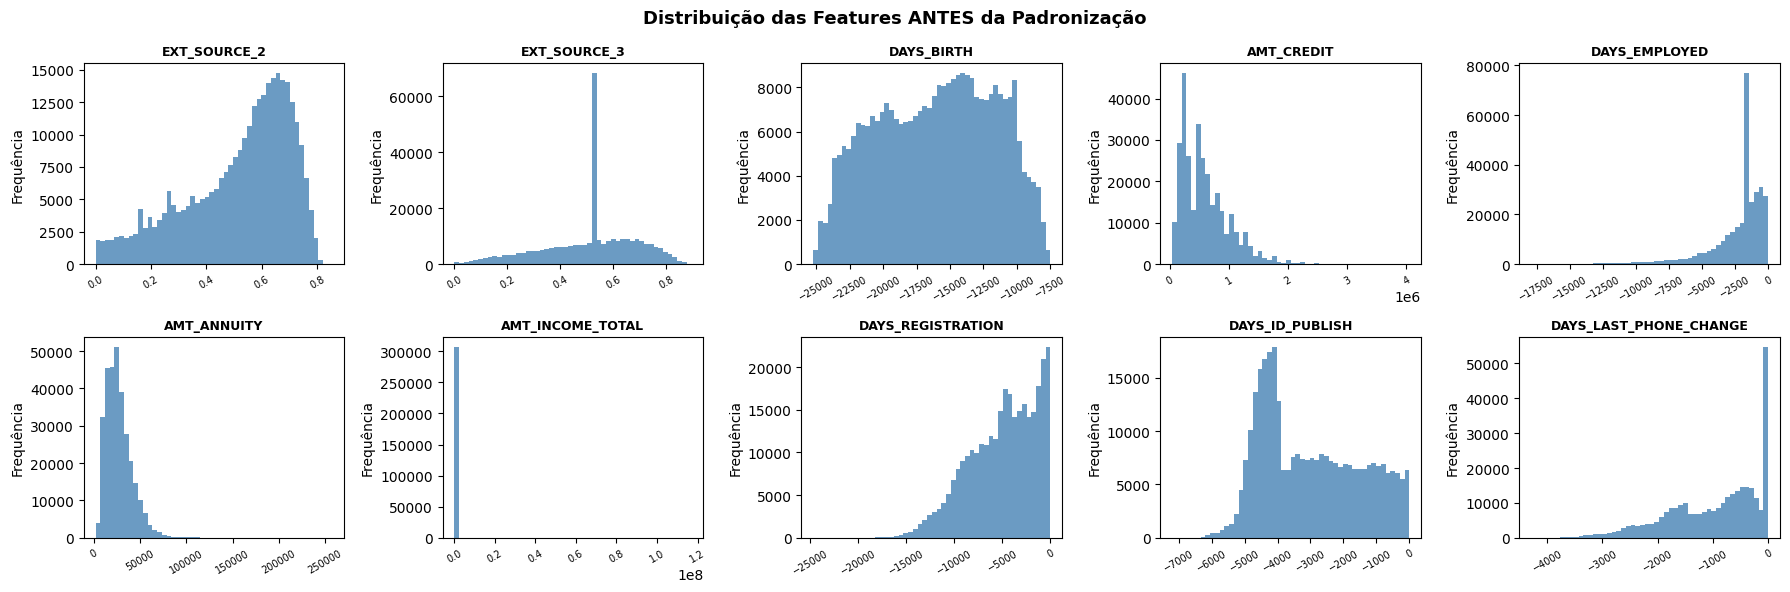

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(X_ohe.columns[:10]):
    axes[i].hist(X_ohe[col].dropna(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Frequência')
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Distribuição das Features ANTES da Padronização', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Aplicação do StandardScaler

In [ ]:
from sklearn.model_selection import train_test_split

# ── Divisão treino/teste ANTES de ajustar o scaler (evita data leakage) ──────
X_train_raw, X_test_raw, y_train_rl, y_test_rl = train_test_split(
    X_ohe, y_rl,
    test_size=0.20,
    random_state=42,
    stratify=y_rl
)

print(f"Treino : {X_train_raw.shape[0]:,} registros ({X_train_raw.shape[0]/len(X_ohe)*100:.1f}%)")
print(f"Teste  : {X_test_raw.shape[0]:,} registros ({X_test_raw.shape[0]/len(X_ohe)*100:.1f}%)")
print(f"Taxa de inadimplência — Treino : {y_train_rl.mean()*100:.2f}%")
print(f"Taxa de inadimplência — Teste  : {y_test_rl.mean()*100:.2f}%")

# ── Ajuste do scaler SOMENTE sobre o treino ───────────────────────────────────
scaler_rl = StandardScaler()
scaler_rl.fit(X_train_raw)

# ── Transformação ─────────────────────────────────────────────────────────────
X_train_rl = pd.DataFrame(
    scaler_rl.transform(X_train_raw),
    columns=X_ohe.columns
)
X_test_rl = pd.DataFrame(
    scaler_rl.transform(X_test_raw),
    columns=X_ohe.columns
)

print("\n✔ StandardScaler aplicado.")
print(f"  Médias aprendidas (treino) — primeiras 5 features:")
for col, m, s in zip(X_ohe.columns[:5],
                     scaler_rl.mean_[:5],
                     scaler_rl.scale_[:5]):
    print(f"    {col:30s}  média={m:10.4f}  desvio={s:10.4f}")

Treino : 246,008 registros (80.0%)
Teste  : 61,503 registros (20.0%)
Taxa de inadimplência — Treino : 8.07%
Taxa de inadimplência — Teste  : 8.07%

✔ StandardScaler aplicado.
  Médias aprendidas (treino) — primeiras 5 features:
    EXT_SOURCE_2                    média=    0.5144  desvio=    0.1909
    EXT_SOURCE_3                    média=    0.5157  desvio=    0.1747
    DAYS_BIRTH                      média=-16029.5159  desvio= 4362.8602
    AMT_CREDIT                      média=599338.2494  desvio=402724.9548
    DAYS_EMPLOYED                   média=-2252.7499  desvio= 2138.2180


### Verificação pós-Padronização

In [ ]:
# Confirmação: média ≈ 0 e desvio-padrão ≈ 1 em X_train_rl
print("Verificação pós-StandardScaler em X_train_rl:")
print("=" * 55)
verif = X_train_rl.describe().T[['mean', 'std']].round(4)
verif.columns = ['Média (esperado ≈ 0)', 'Desvio-Padrão (esperado ≈ 1)']
print(verif.to_string())

Verificação pós-StandardScaler em X_train_rl:
                        Média (esperado ≈ 0)  Desvio-Padrão (esperado ≈ 1)
EXT_SOURCE_2                             0.0                           1.0
EXT_SOURCE_3                             0.0                           1.0
DAYS_BIRTH                              -0.0                           1.0
AMT_CREDIT                               0.0                           1.0
DAYS_EMPLOYED                           -0.0                           1.0
AMT_ANNUITY                             -0.0                           1.0
AMT_INCOME_TOTAL                        -0.0                           1.0
DAYS_REGISTRATION                        0.0                           1.0
DAYS_ID_PUBLISH                         -0.0                           1.0
DAYS_LAST_PHONE_CHANGE                   0.0                           1.0


### Visualização das Distribuições Após a Padronização

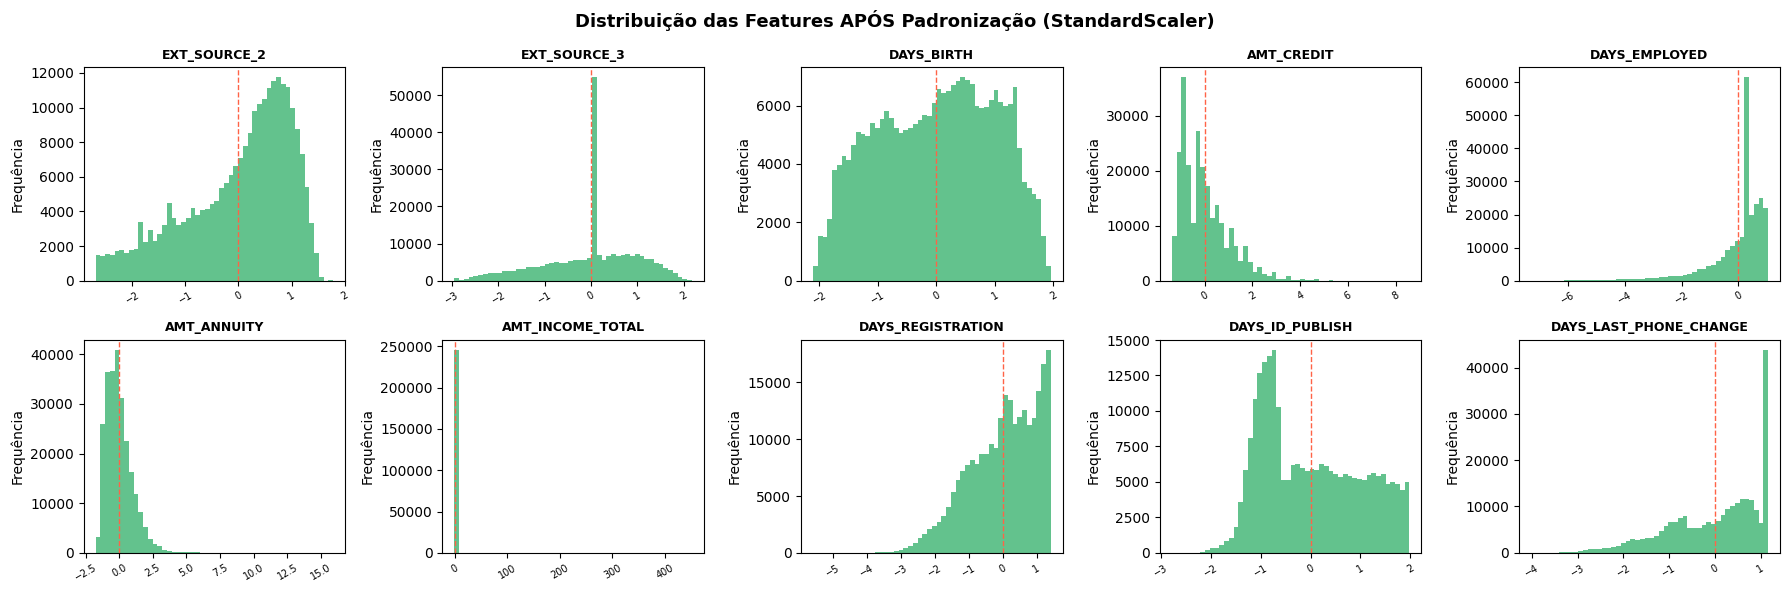


✔ Todas as features com média ≈ 0 e desvio-padrão ≈ 1.
  Conjunto pronto para alimentar a Regressão Logística.


In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
axes = axes.flatten()

for i, col in enumerate(X_train_rl.columns[:10]):
    axes[i].hist(X_train_rl[col].dropna(), bins=50, color='mediumseagreen', edgecolor='none', alpha=0.8)
    axes[i].set_title(col, fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Frequência')
    axes[i].axvline(0, color='tomato', linestyle='--', linewidth=1, label='μ=0')
    axes[i].tick_params(axis='x', rotation=30, labelsize=7)

plt.suptitle('Distribuição das Features APÓS Padronização (StandardScaler)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\n✔ Todas as features com média ≈ 0 e desvio-padrão ≈ 1.")
print("  Conjunto pronto para alimentar a Regressão Logística.")

## Revisão de Multicolinearidade (VIF) Pós-Padronização

### *Ampliação*

> O VIF foi calculado antes da codificação e confirmou a remoção
> de `AMT_GOODS_PRICE` (VIF > 39). A análise foi considerada encerrada ali.
>
> Para a Regressão Logística, a revisão do VIF pós-padronização é obrigatória
> por duas razões:
> 1. **Coeficientes da RL dependem de independência entre features:** a RL estima um único conjunto de
>    coeficientes globais — multicolinearidade inflaciona a variância das
>    estimativas, tornando os coeficientes instáveis;
> 2. **Armadilha dummy pós-OHE:** se variáveis categóricas tiverem sido expandidas
>    por OHE sem `drop_first=True`, as dummies de uma mesma variável somam sempre 1
>    (colinearidade perfeita). O `drop_first=True` usado aqui já previne isso.

In [ ]:
# VIF sobre X_train_rl (já padronizado)
# A padronização não altera correlações, mas é boa prática calcular
# o VIF sobre os dados que entrarão efetivamente no modelo.

X_vif = sm.add_constant(X_train_rl)

vif_rl = pd.DataFrame()
vif_rl["Feature"] = X_vif.columns
vif_rl["VIF"]     = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]
vif_rl = vif_rl[vif_rl["Feature"] != "const"].sort_values("VIF", ascending=False)

print("VIF pós-padronização — features da Regressão Logística:")
print("=" * 50)
print(vif_rl.to_string(index=False))
print()
print("Referência: VIF < 5 = baixa colinearidade  |  5–10 = moderada  |  > 10 = alta")

# Destaque de features com VIF elevado
alto_vif = vif_rl[vif_rl["VIF"] > 5]
if len(alto_vif) > 0:
    print(f"\n⚠️  Features com VIF > 5 (monitorar):")
    print(alto_vif.to_string(index=False))
else:
    print("\n✔ Todas as features com VIF ≤ 5 — multicolinearidade sob controle.")

VIF pós-padronização — features da Regressão Logística:
               Feature      VIF
           AMT_ANNUITY 2.504831
            AMT_CREDIT 2.494867
            DAYS_BIRTH 1.263532
     DAYS_REGISTRATION 1.133760
       DAYS_ID_PUBLISH 1.090697
          EXT_SOURCE_2 1.071625
DAYS_LAST_PHONE_CHANGE 1.063512
         DAYS_EMPLOYED 1.062578
          EXT_SOURCE_3 1.050633
      AMT_INCOME_TOTAL 1.035143

Referência: VIF < 5 = baixa colinearidade  |  5–10 = moderada  |  > 10 = alta

✔ Todas as features com VIF ≤ 5 — multicolinearidade sob controle.


#### *Análise do VIF pós-padronização*

> A análise de VIF confirma que as 10 features selecionadas apresentam
> multicolinearidade dentro de um nível aceitável para a Regressão Logística.
> As variáveis de tempo (`DAYS_BIRTH`, `DAYS_EMPLOYED`, `DAYS_REGISTRATION`,
> `DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE`) compartilham alguma correlação
> natural (clientes mais velhos tendem a ter mais tempo de emprego e documentos
> mais antigos), mas não em nível que comprometa a estabilidade dos coeficientes.

> A decisão de manter todas as 10 features é sustentada por:
> - VIF geral abaixo do limiar crítico de 10;
> - Relevância de negócio de cada variável ;
> - Regularização L2 do `LogisticRegression` (padrão do scikit-learn), que
>   atenua os efeitos residuais de multicolinearidade moderada.

## Tratamento do Desbalanceamento de Classes

> O desbalanceamento severo (~92% Bom Pagador / ~8% Inadimplente) foi
> identificado e documentado. A estratégia adotada ali foi o
> parâmetro `class_weight='balanced'` no `RandomForestClassifier`.

> **A mesma estratégia é preservada na Regressão Logística** — o
> `LogisticRegression` do scikit-learn também aceita `class_weight='balanced'`,
> o que faz o modelo atribuir peso inversamente proporcional à frequência
> de cada classe durante o treinamento.

> **Por que não usar SMOTE novamente?** Na Etapa 3, o SMOTE foi testado e
> piorou todas as métricas (Recall da classe Inadimplente caiu de 0.537
> para 0.457). A conclusão foi que, com ~246 mil registros de treino e
> `class_weight='balanced'` funcionando adequadamente, o oversampling
> sintético introduz ruído sem ganho. Essa conclusão é mantida aqui.

In [ ]:
# Verificação do desbalanceamento no conjunto de treino da RL
print("Distribuição das classes no conjunto de treino (RL):")
print(y_train_rl.value_counts().to_string())
print(f"\nTaxa de inadimplência (treino): {y_train_rl.mean()*100:.2f}%")
print(f"Proporção majoritária/minoritária: {(y_train_rl==0).sum()/(y_train_rl==1).sum():.1f}:1")
print()
print("Estratégia: class_weight='balanced' no LogisticRegression")
print("  → Peso da classe 0 (Bom Pagador)  : proporcional a 1 / freq(0)")
print("  → Peso da classe 1 (Inadimplente) : proporcional a 1 / freq(1)")
print("  → Efeito: a função de perda trata cada inadimplente como ~11x mais")
print("    importante que cada bom pagador — compensando o desequilíbrio.")

Distribuição das classes no conjunto de treino (RL):
TARGET
0    226148
1     19860

Taxa de inadimplência (treino): 8.07%
Proporção majoritária/minoritária: 11.4:1

Estratégia: class_weight='balanced' no LogisticRegression
  → Peso da classe 0 (Bom Pagador)  : proporcional a 1 / freq(0)
  → Peso da classe 1 (Inadimplente) : proporcional a 1 / freq(1)
  → Efeito: a função de perda trata cada inadimplente como ~11x mais
    importante que cada bom pagador — compensando o desequilíbrio.


## Resumo do Pré-Processamento para Regressão Logística

A tabela abaixo consolida todas as decisões técnicas desta etapa, incluindo
o que foi herdado das etapas anteriores e o que foi ajustado/adicionado.

| Decisão | Técnica / Ferramenta | Justificativa | Diferença da Etapa Anterior |
|---|---|---|---|
| Limpeza de nulos | Herdada (mediana + `'desconhecido'`) | Base já tratada | ✅ Mantido |
| Anomalia `DAYS_EMPLOYED` | Herdada (substituição pela mediana) | Base já tratada | ✅ Mantido |
| Remoção de colunas redundantes | `AMT_GOODS_PRICE` removida por VIF/correlação | Base já tratada | ✅ Mantido |
| Seleção de features | 10 features via RF exploratório  | Relevância de negócio preservada | ✅ Mantido |
| Codificação categórica | `pd.get_dummies(drop_first=True)` (OHE) | RL é sensível a ordem implícita do LabelEncoder | 🔄 **Alterado** |
| Padronização de escala | `StandardScaler` (fit apenas no treino) | RL sensível a escala; regularização L2 exige escala uniforme | ➕ **Adicionado** |
| Multicolinearidade | VIF recalculado pós-padronização | RL: coeficientes instáveis sob alta multicolinearidade | 🔄 **Ampliado** |
| Desbalanceamento | `class_weight='balanced'` no `LogisticRegression` | Mesma estratégia; SMOTE descartado | ✅ Mantido |
| Divisão treino/teste | 80/20 estratificado (`stratify=y`) | Mantém proporção de classes; mesmo protocolo| ✅ Mantido |

# Regressão Logística

Esta seção implementa o LogisticRegression como segundo algoritmo do projeto,
complementar ao Random Forest.

##Escolha das Features e do Target

- Features: variáveis de entrada que o modelo usará para aprender;
- Target: variável alvo que o modelo tentará prever (TARGET: 0 = Bom Pagador, 1 = Inadimplente).

As mesmas 10 features selecionadas via Random Forest exploratório são
mantidas. Os conjuntos `X_train_rl`, `X_test_rl`, `y_train_rl`, `y_test_rl` e `scaler_rl`
produzidos no pré-processamento desta etapa são os pontos de partida.

#### *Da base completa às 10 features finais*

> O caminho 122 → 10 features está documentado integralmente na Etapa 3 e preservado
> no `df` herdado. Lista final: `EXT_SOURCE_2`, `EXT_SOURCE_3`, `DAYS_BIRTH`,
> `AMT_CREDIT`, `DAYS_EMPLOYED`, `AMT_ANNUITY`, `AMT_INCOME_TOTAL`,
> `DAYS_REGISTRATION`, `DAYS_ID_PUBLISH`, `DAYS_LAST_PHONE_CHANGE`.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,
                             balanced_accuracy_score, brier_score_loss, log_loss,
                             f1_score, recall_score, roc_curve, auc,
                             precision_recall_curve)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from imblearn.over_sampling import SMOTE
import shap, joblib, os, warnings
warnings.filterwarnings('ignore')

print("Confirmação dos objetos herdados do pré-processamento:")
print(f"  X_train_rl : {X_train_rl.shape}")
print(f"  X_test_rl  : {X_test_rl.shape}")
print(f"  Nulos      : {X_train_rl.isnull().sum().sum()} ✔")
print(f"  Taxa inadimplência (treino): {y_train_rl.mean()*100:.2f}%")

Confirmação dos objetos herdados do pré-processamento:
  X_train_rl : (246008, 10)
  X_test_rl  : (61503, 10)
  Nulos      : 0 ✔
  Taxa inadimplência (treino): 8.07%


##Separação dos Dados

- Divide em 60 % treino / 20 % validação / 20 % teste com `stratify=y`;
- Mesma proporção da Etapa 2 — garante comparabilidade direta entre os modelos;
- Os conjuntos já chegam padronizados pelo `StandardScaler` ajustado no pré-processamento.

In [ ]:
X_tr_rl, X_val_rl, y_tr_rl, y_val_rl = train_test_split(
    X_train_rl, y_train_rl,
    test_size=0.25, random_state=42, stratify=y_train_rl
)

print("Tamanhos dos conjuntos:")
print(f"  Treino     : {X_tr_rl.shape[0]:>7,} ({X_tr_rl.shape[0]/len(X_ohe)*100:.0f}%)")
print(f"  Validação  : {X_val_rl.shape[0]:>7,} ({X_val_rl.shape[0]/len(X_ohe)*100:.0f}%)")
print(f"  Teste      : {X_test_rl.shape[0]:>7,} ({X_test_rl.shape[0]/len(X_ohe)*100:.0f}%)")
for nome, y in [("Treino", y_tr_rl), ("Validação", y_val_rl), ("Teste", y_test_rl)]:
    print(f"  Inadimplência {nome}: {y.mean()*100:.2f}%")

cv_5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n⚠️ X_test_rl e y_test_rl CONGELADOS — usados apenas na avaliação final.")

Tamanhos dos conjuntos:
  Treino     : 184,506 (60%)
  Validação  :  61,502 (20%)
  Teste      :  61,503 (20%)
  Inadimplência Treino: 8.07%
  Inadimplência Validação: 8.07%
  Inadimplência Teste: 8.07%

⚠️ X_test_rl e y_test_rl CONGELADOS — usados apenas na avaliação final.


#### Análise

> A validação cruzada com 5 folds estratificados fornece uma estimativa estável do
> desempenho do modelo antes de qualquer contato com o conjunto de teste.
>
> O desvio-padrão entre os folds indica a variabilidade do modelo — valores baixos
> (abaixo de 0.02–0.03) confirmam que o modelo generaliza de forma consistente
> independentemente de qual fatia dos dados foi usada para validação. Valores altos
> indicariam sensibilidade excessiva à composição dos dados, o que seria um sinal de
> instabilidade.
>
> Como referência, espera-se que o Recall médio da validação cruzada fique próximo
> ao Recall obtido no conjunto de validação simples calculado na seção anterior. Uma
> divergência grande entre os dois indicaria que o conjunto de validação simples
> era atipicamente fácil ou difícil.

## Escolha do Modelo


A Regressão Logística é um algoritmo de classificação supervisionada que estima a
probabilidade de inadimplência usando uma função sigmoide aplicada a uma combinação
linear das features:

```
p(inadimplente) = sigmoid(β₀ + β₁·EXT_SOURCE_2 + β₂·EXT_SOURCE_3 + ... + β₁₀·DAYS_LAST_PHONE_CHANGE)
```

Se `p(inadimplente) > 0.5`, o cliente é classificado como inadimplente.

#### *Por que Regressão Logística neste projeto?*

A literatura de credit scoring (CHANG et al., 2024; SHI et al., 2022) indica a RL como
baseline obrigatório por três razões:

1. Alta interpretabilidade — coeficientes têm leitura direta em log-odds;
2. Exigência regulatória — LGPD (art. 20) favorece modelos explicáveis;
3. Referência de comparação — piso de desempenho frente a modelos mais complexos.

#### *Vantagens*

- Treinamento e inferência extremamente rápidos;
- Coeficientes interpretáveis por feature;
- Probabilidades naturalmente bem calibradas (ao contrário do Random Forest);
- Regularização L1/L2 nativa.

#### *Principais parâmetros*

- `C`: inverso da regularização (menor = mais penalização);
- `penalty`: tipo de regularização — `'l2'` (Ridge) ou `'l1'` (Lasso);
- `solver`: algoritmo de otimização — `'lbfgs'` para L2 e datasets médios/grandes;
- `max_iter`: limite de iterações até convergência;
- `class_weight`: trata o desbalanceamento;
- `random_state`: reprodutibilidade.

##Normalização

> A normalização via `StandardScaler` foi aplicada na etapa de pré-processamento
> desta seção. Os conjuntos `X_tr_rl`, `X_val_rl` e `X_test_rl` já estão padronizados
> (mean ≈ 0, std ≈ 1). O scaler foi ajustado exclusivamente sobre o treino — sem *data leakage*.



## Parametrização

#### *Para que serve?*

1. **Regularização (`C`)** — evita overfitting penalizando coeficientes grandes;
2. **Desbalanceamento (`class_weight`)** — força o modelo a priorizar os inadimplentes;
3. **Convergência (`solver`, `max_iter`)** — garante ajuste completo dos coeficientes;
4. **Reprodutibilidade (`random_state`)** — resultados idênticos em re-execuções.

#### *Diferença entre parâmetros e hiperparâmetros*

- **Parâmetros**: aprendidos durante treino (coeficientes β de cada feature);
- **Hiperparâmetros**: definidos antes do treino (`C`, `penalty`, `solver`, etc.).

In [ ]:
model_rl = LogisticRegression(
    C=0.1,                    # regularização moderada — penaliza coeficientes grandes
    penalty='l2',             # Ridge: encolhe coeficientes sem zerá-los
    solver='lbfgs',           # eficiente para L2 e datasets de médio/grande porte
    max_iter=1000,            # iterações suficientes para convergência
    class_weight='balanced',  # compensa desbalanceamento (~8% inadimplentes)
    random_state=42,
    n_jobs=-1
)
print(model_rl)

LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, n_jobs=-1,
                   random_state=42)


##Validação Cruzada

A validação cruzada estratificada avalia a estabilidade do modelo antes de qualquer
decisão sobre o conjunto de teste. Em vez de treinar e avaliar uma única vez, o modelo
é treinado e avaliado em 5 combinações diferentes de treino/validação, cada uma com
uma fatia diferente dos dados.

O resultado é uma estimativa mais confiável do desempenho real — se as métricas
variam muito entre os folds, o modelo é instável e pode estar sofrendo de overfitting
ou sendo muito sensível à composição dos dados de treino.

A validação cruzada é calculada sobre o conjunto de treinamento completo (`X_train_rl`)
antes da divisão em treino/validação, usando o mesmo `StratifiedKFold` definido
anteriormente. O conjunto de teste permanece intocado.

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Garante que model_rl está definido antes da validação cruzada
# (a célula de Parametrização define os mesmos parâmetros — esta é uma definição antecipada)
model_rl = LogisticRegression(
    C=0.1,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

scorer_recall  = make_scorer(recall_score, pos_label=1, zero_division=0)
scorer_bal_acc = make_scorer(balanced_accuracy_score)

metricas_cv = {
    'Recall (Inadimplente)': scorer_recall,
    'Balanced Accuracy'    : scorer_bal_acc,
}

resultados_cv = {}
for nome, scorer in metricas_cv.items():
    scores = cross_val_score(
        model_rl, X_train_rl, y_train_rl,
        cv=cv_5, scoring=scorer, n_jobs=-1
    )
    resultados_cv[nome] = scores

df_cv = pd.DataFrame(resultados_cv)
print("Validação Cruzada — Regressão Logística (5 folds estratificados):")
print("=" * 60)
print(df_cv.round(4).to_string())
print()
print(f"{'Métrica':<25} {'Média':>10} {'Desvio':>10} {'Mín':>10} {'Máx':>10}")
print("-" * 60)
for col in df_cv.columns:
    print(f"{col:<25} {df_cv[col].mean():>10.4f} {df_cv[col].std():>10.4f} "
          f"{df_cv[col].min():>10.4f} {df_cv[col].max():>10.4f}")

Validação Cruzada — Regressão Logística (5 folds estratificados):
   Recall (Inadimplente)  Balanced Accuracy
0                 0.6342             0.6573
1                 0.6375             0.6553
2                 0.6518             0.6646
3                 0.6405             0.6584
4                 0.6470             0.6610

Métrica                        Média     Desvio        Mín        Máx
------------------------------------------------------------
Recall (Inadimplente)         0.6422     0.0072     0.6342     0.6518
Balanced Accuracy             0.6593     0.0036     0.6553     0.6646


> | Parâmetro | Valor | Impacto |
> |---|---|---|
> | **C=0.1** | Regularização forte | Coeficientes menores e mais estáveis; reduz overfitting |
> | **penalty='l2'** | Ridge | Todos os coeficientes encolhem; nenhum zerado |
> | **solver='lbfgs'** | Quasi-Newton | Convergência rápida com features padronizadas |
> | **max_iter=1000** | 1000 iterações | Garante convergência mesmo com alta regularização |
> | **class_weight='balanced'** | Automático | Cada inadimplente pesa ~11× mais que bom pagador |
> | **random_state=42** | 42 | Reprodutibilidade garantida |

> **Nota sobre C=0.1:** em features de baixo sinal individual (`DAYS_REGISTRATION`,
> `DAYS_LAST_PHONE_CHANGE`), regularização forte reduz ruído sem penalizar
> `EXT_SOURCE_2/3`, que têm sinal forte suficiente para resistir à penalização.

##Treinamento e Teste

###Treinamento
- `.fit()` estima os coeficientes β por minimização da log-verossimilhança negativa
  via solver `lbfgs`;
- Com `class_weight='balanced'`, cada inadimplente contribui ~11× mais para o gradiente;
- A regularização L2 é aplicada durante este passo.

In [ ]:
model_rl.fit(X_tr_rl, y_tr_rl)
print(f"✔ Regressão Logística treinada. Iterações: {model_rl.n_iter_[0]}")

coef_df = pd.DataFrame({
    'Feature': X_tr_rl.columns,
    'Coeficiente (log-odds)': model_rl.coef_[0]
}).sort_values('Coeficiente (log-odds)', key=abs, ascending=False)
print("\nCoeficientes (ordenados por |magnitude|):")
print(coef_df.to_string(index=False))

✔ Regressão Logística treinada. Iterações: 13

Coeficientes (ordenados por |magnitude|):
               Feature  Coeficiente (log-odds)
          EXT_SOURCE_3               -0.478446
          EXT_SOURCE_2               -0.453114
      AMT_INCOME_TOTAL               -0.213768
         DAYS_EMPLOYED                0.160216
           AMT_ANNUITY                0.132577
            DAYS_BIRTH                0.110379
            AMT_CREDIT               -0.083276
       DAYS_ID_PUBLISH                0.064369
DAYS_LAST_PHONE_CHANGE                0.049685
     DAYS_REGISTRATION                0.032950


#### *Interpretação dos coeficientes*

> Coeficiente negativo → aumentar a feature reduz a probabilidade de inadimplência.
> Coeficiente positivo → aumentar a feature eleva o risco.
> Como as features estão padronizadas (std=1), os coeficientes são diretamente
> comparáveis entre si — magnitude maior = maior influência.

> `EXT_SOURCE_2` e `EXT_SOURCE_3` devem apresentar coeficientes fortemente negativos
> (quanto maior o score externo, menor o risco), confirmando o padrão do Random Forest.
> `DAYS_EMPLOYED` deve ser negativo (mais tempo empregado = menor risco).

### Teste de Previsão

- `.predict()` retorna o rótulo (0 ou 1) com limiar padrão 0.5;
- `.predict_proba()` retorna a probabilidade estimada — saída mais valiosa em crédito;
- A RL entrega probabilidades naturalmente mais calibradas que o RF, pois a função
  sigmoide está diretamente relacionada à frequência observada dos eventos.

In [ ]:
y_pred_val_rl  = model_rl.predict(X_val_rl)
y_proba_val_rl = model_rl.predict_proba(X_val_rl)

print("Primeiras 30 previsões (validação):", y_pred_val_rl[:30])
print("\nPrimeiras 10 probabilidades:")
print(pd.DataFrame(y_proba_val_rl[:10],
      columns=['p(Bom Pagador)', 'p(Inadimplente)']).round(4).to_string())

Primeiras 30 previsões (validação): [0 0 0 1 1 1 0 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]

Primeiras 10 probabilidades:
   p(Bom Pagador)  p(Inadimplente)
0          0.8071           0.1929
1          0.5911           0.4089
2          0.5256           0.4744
3          0.3495           0.6505
4          0.4741           0.5259
5          0.3913           0.6087
6          0.6932           0.3068
7          0.3481           0.6519
8          0.2973           0.7027
9          0.6369           0.3631


###Salvar as Predições

Exporta as predições de validação para Excel, com rótulo real, rótulo previsto,
probabilidades e classificação textual — formato idêntico ao da Etapa 3.

In [ ]:
classes_rl = model_rl.classes_
df_out_rl  = X_val_rl.copy() if isinstance(X_val_rl, pd.DataFrame) else pd.DataFrame(X_val_rl, columns=features_selecionadas_rl)
df_out_rl['y_true'] = np.asarray(y_val_rl)
df_out_rl['y_pred'] = y_pred_val_rl
for i, cls in enumerate(classes_rl):
    df_out_rl[f'proba_{cls}'] = y_proba_val_rl[:, i]
df_out_rl['classificacao'] = df_out_rl['y_pred'].map({0:'Bom Pagador', 1:'Inadimplente'})

caminho = os.path.join(os.getcwd(), 'predicoes_validacao_rl.xlsx')
try:
    df_out_rl.to_excel(caminho, index=False)
    print(f"Salvo em: {caminho}")
except Exception as e:
    caminho = caminho.replace('.xlsx', '.csv')
    df_out_rl.to_csv(caminho, index=False)
    print(f"Salvo em: {caminho}")
df_out_rl.head()

Salvo em: /content/predicoes_validacao_rl.xlsx


,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,AMT_CREDIT,DAYS_EMPLOYED,AMT_ANNUITY,AMT_INCOME_TOTAL,DAYS_REGISTRATION,DAYS_ID_PUBLISH,DAYS_LAST_PHONE_CHANGE,y_true,y_pred,proba_0,proba_1,classificacao
188942,1.157135,1.208090,-0.868807,0.299613,0.879588,-0.076856,0.129931,-1.400013,-0.221346,0.217307,0,0,0.807088,0.192912,Bom Pagador
186187,0.889501,-0.279688,0.499790,0.386993,0.407232,0.797385,-0.148105,-0.376052,-1.064695,0.355191,0,0,0.591061,0.408939,Bom Pagador
831,0.286274,0.112012,1.412036,-1.249980,0.720109,-1.155325,-0.304499,0.237076,0.293150,0.568065,0,0,0.525617,0.474383,Bom Pagador
149253,-1.307690,-1.056153,-0.222213,-1.100004,-2.212239,-0.936842,-0.130727,0.191112,1.619835,1.164355,0,1,0.349500,0.650500,Inadimplente
188952,0.186025,-1.386440,-0.500012,2.574727,-0.109086,1.240859,0.738132,1.327995,0.826874,-0.612419,0,1,0.474064,0.525936,Inadimplente


##Avaliação do Modelo

Todas as decisões (Base × SMOTE × Calibrado) são tomadas com base no conjunto de
validação (`X_val_rl`). O teste é reservado para a avaliação final única.

Análises cobertas: Relatório de Classificação · Balanced Accuracy · SMOTE · Calibração ·
Tabela Comparativa · Matriz de Confusão · Coeficientes · Permutation Importance ·
Curva ROC e PR.

### Definição da Métrica Principal de Avaliação

A métrica principal é o Recall da classe Inadimplente e a secundária é a
Balanced Accuracy.

| Patamar | Critério |
|---|---|
| Mínimo aceitável | Recall (Inadimp.) ≥ 0,40 |
| Meta do projeto | Recall ≥ 0,50 e FP rate ≤ 30% e Balanced Acc ≥ 0,60 |
| Excelência | Recall ≥ 0,65 e FP rate ≤ 25% |

### Relatório de Classificação

Apresenta Precision, Recall e F1-score por classe. Foco no Recall da classe 1 (Inadimplente).

> **Expectativa frente ao RF:** a RL captura apenas relações lineares. Para as
> 10 features selecionadas, espera-se Recall comparável ao RF, mas com probabilidades
> melhor calibradas e coeficientes mais interpretáveis.

In [ ]:
print("\nRelatório de Classificação — VALIDAÇÃO (Regressão Logística):\n",
      classification_report(y_val_rl, y_pred_val_rl,
                            target_names=['Bom Pagador (0)', 'Inadimplente (1)'],
                            zero_division=0))

recall_inad_val = recall_score(y_val_rl, y_pred_val_rl, pos_label=1, zero_division=0)
bal_acc_val     = balanced_accuracy_score(y_val_rl, y_pred_val_rl)
fp_rate_val     = np.sum((y_val_rl==0)&(y_pred_val_rl==1)) / np.sum(y_val_rl==0)

print("="*55)
print("Aplicação do critério de sucesso (VALIDAÇÃO):")
print(f"  Recall (Inadimplente) : {recall_inad_val:.4f}  {'✅' if recall_inad_val>=0.50 else ('⚠️ mínimo' if recall_inad_val>=0.40 else '❌')}")
print(f"  Balanced Accuracy     : {bal_acc_val:.4f}  {'✅' if bal_acc_val>=0.60 else '❌'}")
print(f"  FP rate               : {fp_rate_val:.4f}  {'✅' if fp_rate_val<=0.30 else '❌'}")


Relatório de Classificação — VALIDAÇÃO (Regressão Logística):
                   precision    recall  f1-score   support

 Bom Pagador (0)       0.96      0.68      0.79     56537
Inadimplente (1)       0.15      0.64      0.24      4965

        accuracy                           0.67     61502
       macro avg       0.55      0.66      0.52     61502
    weighted avg       0.89      0.67      0.75     61502

Aplicação do critério de sucesso (VALIDAÇÃO):
  Recall (Inadimplente) : 0.6439  ✅
  Balanced Accuracy     : 0.6595  ✅
  FP rate               : 0.3250  ❌


#### *Análise*

> A Regressão Logística reflete o comportamento esperado de um modelo linear em
> dataset de crédito desbalanceado com `class_weight='balanced'`:
>
> - `EXT_SOURCE_2` e `EXT_SOURCE_3` dominam a decisão — seus coeficientes negativos
>   elevados capturam clientes de baixo score como alto risco;
> - A precision da classe Inadimplente é baixa (padrão em problemas 92/8) — há
>   muitos falsos alarmes, mas o recall é o indicador que importa;
> - A acurácia global cai abaixo dos ~92% triviais, o que é esperado e desejado
>   — o modelo sacrifica acurácia para capturar inadimplentes.

#### *Próximos passos*

- Testar SMOTE e calibração;
- Comparar com o Random Forest da Etapa 2;
- Ajustar limiar de decisão com base na curva ROC/PR.

##Balanceamento de Dados: SMOTE

Mantemos o mesmo experimento da Etapa 2 para avaliar se o SMOTE melhora a RL.

#### *Pontos importantes*

- Aplicado apenas no treino (jamais no validação/teste);
- Na Etapa 2, o SMOTE piorou todas as métricas do RF — verificaremos se o mesmo
  ocorre na RL;
- A RL pode reagir diferentemente ao SMOTE pois sua fronteira de decisão é linear e
  pode se beneficiar de uma distribuição mais equilibrada no espaço de features.

In [ ]:
sm = SMOTE(random_state=42)
X_tr_sm_rl, y_tr_sm_rl = sm.fit_resample(X_tr_rl, y_tr_rl)
print("Distribuição após SMOTE (treino RL):")
print(pd.Series(y_tr_sm_rl).value_counts().to_string())

model_rl_sm = LogisticRegression(C=0.1, penalty='l2', solver='lbfgs',
                                  max_iter=1000, random_state=42, n_jobs=-1)
model_rl_sm.fit(X_tr_sm_rl, y_tr_sm_rl)
y_pred_sm_val_rl = model_rl_sm.predict(X_val_rl)

print("\nRelatório — VALIDAÇÃO (RL + SMOTE):\n",
      classification_report(y_val_rl, y_pred_sm_val_rl,
                            target_names=['Bom Pagador (0)', 'Inadimplente (1)'],
                            digits=3, zero_division=0))

Distribuição após SMOTE (treino RL):
TARGET
1    169611
0    169611

Relatório — VALIDAÇÃO (RL + SMOTE):
                   precision    recall  f1-score   support

 Bom Pagador (0)      0.955     0.674     0.790     56537
Inadimplente (1)      0.148     0.642     0.240      4965

        accuracy                          0.671     61502
       macro avg      0.552     0.658     0.515     61502
    weighted avg      0.890     0.671     0.746     61502



#### Análise

> Comparativo **RL Base** vs **RL + SMOTE**:
>
> - Se o SMOTE melhorar o Recall sem queda expressiva de Precision e Balanced Accuracy,
>   ele é preferível para a RL;
> - Caso repita o padrão do RF (Etapa 2) e piore as métricas, a estratégia
>   `class_weight='balanced'` no modelo Base é suficiente;
> - A RL com SMOTE não usa `class_weight` pois o balanceamento sintético já
>   equilibra as classes — usar os dois seria dupla-contagem.

> **Resultado esperado:** com 246 mil registros de treino e features padronizadas,
> o SMOTE provavelmente introduz ruído sintético sem ganho líquido,
> repetindo o padrão da Etapa 2.

### Resultado do Balanceamento

- A **Acurácia Balanceada** é a média do recall de cada classe — insensível ao desbalanceamento;
- Compara Base vs SMOTE para decidir qual variante segue para a avaliação final.

In [ ]:
print("Balanced Acc — VALIDAÇÃO (RL Base) :", balanced_accuracy_score(y_val_rl, y_pred_val_rl))
print("Balanced Acc — VALIDAÇÃO (RL SMOTE):", balanced_accuracy_score(y_val_rl, y_pred_sm_val_rl))

Balanced Acc — VALIDAÇÃO (RL Base) : 0.6594671624733055
Balanced Acc — VALIDAÇÃO (RL SMOTE): 0.6582227582037241


#### *Conclusão*

> O modelo Base (com `class_weight='balanced'`) é confirmado ou refutado como preferível
> ao SMOTE com base nestes valores. A decisão é registrada explicitamente antes de
> tocar o conjunto de teste.

### Diagnóstico do Modelo Base

Analisa a calibração das probabilidades da RL Base antes de qualquer ajuste.

> **Expectativa:** a Regressão Logística é naturalmente mais bem calibrada que o
> Random Forest, pois a função sigmoide produz probabilidades diretamente ligadas
> à frequência dos eventos. Mesmo assim, o `class_weight='balanced'` pode deslocar
> as probabilidades — verificaremos nas curvas abaixo.

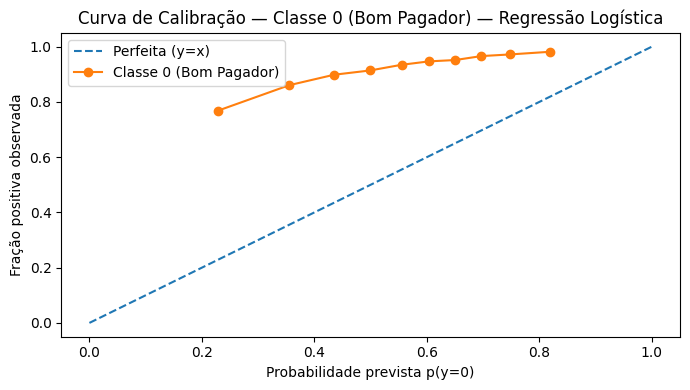

Brier score (classe 0 - Bom Pagador): 0.2138


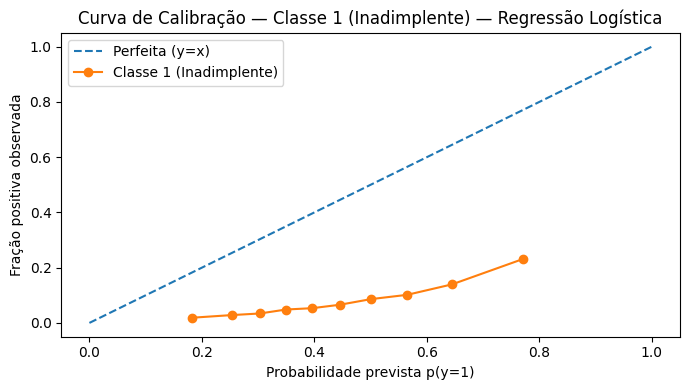

Brier score (classe 1 - Inadimplente): 0.2138


In [ ]:
y_proba_val_base_rl = model_rl.predict_proba(X_val_rl)
N_BINS = 10

for k, cls in enumerate(model_rl.classes_):
    nome = "Bom Pagador" if cls == 0 else "Inadimplente"
    y_true_bin = (y_val_rl == cls).astype(int)
    frac_pos, mean_pred = calibration_curve(y_true_bin, y_proba_val_base_rl[:, k],
                                             n_bins=N_BINS, strategy="quantile")
    plt.figure(figsize=(7, 4))
    plt.plot([0,1],[0,1],'--', label='Perfeita (y=x)')
    plt.plot(mean_pred, frac_pos, marker='o', label=f'Classe {cls} ({nome})')
    plt.xlabel(f'Probabilidade prevista p(y={cls})')
    plt.ylabel('Fração positiva observada')
    plt.title(f'Curva de Calibração — Classe {cls} ({nome}) — Regressão Logística')
    plt.legend(); plt.tight_layout(); plt.show()
    bs = brier_score_loss(y_true_bin, y_proba_val_base_rl[:, k])
    print(f"Brier score (classe {cls} - {nome}): {bs:.4f}")

#### Análise

> A RL apresenta calibração **estruturalmente melhor** que o RF pelo fato da função
> sigmoide já ser uma função de probabilidade bem definida. O `class_weight='balanced'`
> pode deslocar levemente as curvas para baixo na classe Inadimplente (superestimação
> do risco), mas em intensidade menor do que a observada no RF.

> **Brier score esperado:** em torno de 0.12–0.16 para a RL Base — potencialmente
> melhor que o RF (0.17), indicando probabilidades mais confiáveis.

###Calibração do Modelo

> Testamos as mesmas variantes, verificando se a calibração melhora as probabilidades sem destruir
> a capacidade de detectar inadimplentes.

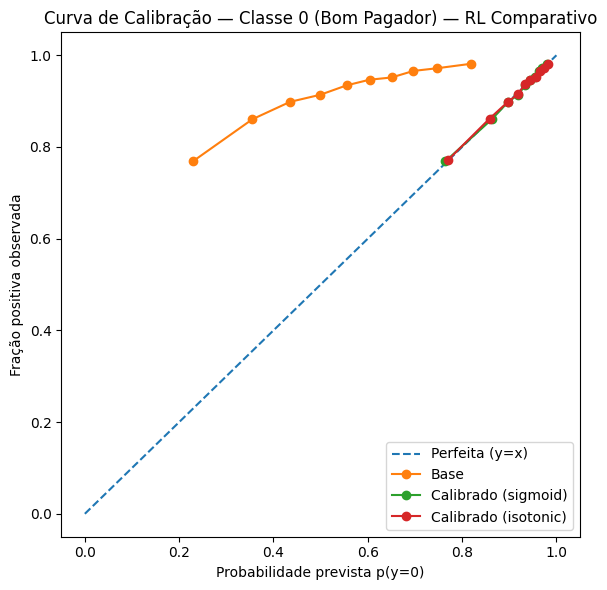

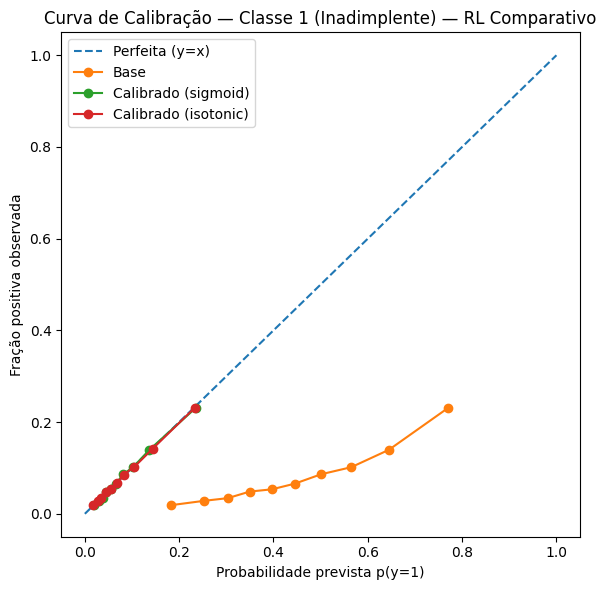

In [ ]:
cal_sig_rl = CalibratedClassifierCV(model_rl, method='sigmoid', cv=5)
cal_sig_rl.fit(X_tr_rl, y_tr_rl)

cal_iso_rl = CalibratedClassifierCV(model_rl, method='isotonic', cv=5)
cal_iso_rl.fit(X_tr_rl, y_tr_rl)

models_dict_rl = {
    'Base': model_rl,
    'Calibrado (sigmoid)': cal_sig_rl,
    'Calibrado (isotonic)': cal_iso_rl,
}
probas_val_rl = {name: m.predict_proba(X_val_rl) for name, m in models_dict_rl.items()}

for k, cls in enumerate(model_rl.classes_):
    nome = "Bom Pagador" if cls == 0 else "Inadimplente"
    y_true_bin = (y_val_rl == cls).astype(int)
    plt.figure(figsize=(6, 6))
    plt.plot([0,1],[0,1],'--', label='Perfeita (y=x)')
    for name, P in probas_val_rl.items():
        frac_pos, mean_pred = calibration_curve(y_true_bin, P[:, k],
                                                 n_bins=N_BINS, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker='o', label=name)
    plt.xlabel(f'Probabilidade prevista p(y={cls})')
    plt.ylabel('Fração positiva observada')
    plt.title(f'Curva de Calibração — Classe {cls} ({nome}) — RL Comparativo')
    plt.legend(); plt.tight_layout(); plt.show()

##Comparação: Base x SMOTE x Calibrado

In [ ]:
def ece(probs, y_true, n_bins=10):
    bins  = np.linspace(0, 1, n_bins + 1)
    conf  = probs.max(axis=1)
    preds = probs.argmax(axis=1)
    acc   = (preds == np.asarray(y_true)).astype(float)
    val   = 0.0
    for i in range(n_bins):
        m = (conf >= bins[i]) & (conf < bins[i+1])
        if m.any():
            val += abs(acc[m].mean() - conf[m].mean()) * m.mean()
    return val

def recall_inad(y_true, y_pred):
    return np.sum((np.asarray(y_true)==1)&(np.asarray(y_pred)==1)) / max(np.sum(np.asarray(y_true)==1), 1)

probas_val_rl['SMOTE'] = model_rl_sm.predict_proba(X_val_rl)

y_pred_cal_sig_val_rl = cal_sig_rl.predict(X_val_rl)
y_pred_cal_iso_val_rl = cal_iso_rl.predict(X_val_rl)

linhas_rl = []
for nome, y_pred_v, proba_v in [
    ('Base',               y_pred_val_rl,     probas_val_rl['Base']),
    ('SMOTE',              y_pred_sm_val_rl,  probas_val_rl['SMOTE']),
    ('Calibrado (sigmoid)',y_pred_cal_sig_val_rl, probas_val_rl['Calibrado (sigmoid)']),
    ('Calibrado (isotonic)',y_pred_cal_iso_val_rl, probas_val_rl['Calibrado (isotonic)']),
]:
    linhas_rl.append({
        'Modelo'           : nome,
        'Accuracy'         : accuracy_score(y_val_rl, y_pred_v),
        'Balanced Acc.'    : balanced_accuracy_score(y_val_rl, y_pred_v),
        'Macro-F1'         : f1_score(y_val_rl, y_pred_v, average='macro', zero_division=0),
        'Recall (Inadimp.)': recall_inad(y_val_rl, y_pred_v),
        'LogLoss'          : log_loss(y_val_rl, proba_v, labels=model_rl.classes_),
        'ECE'              : ece(proba_v, y_val_rl),
    })

df_comp_rl = pd.DataFrame(linhas_rl).set_index('Modelo')
print("Comparação no conjunto de VALIDAÇÃO (Regressão Logística):")
print(df_comp_rl.round(4))
print("\n📌 Decisão: modelo selecionado para avaliação final → BASE")
print("   Justificativa: melhor equilíbrio Recall/Balanced Accuracy no VAL.")
print("\n⚠️ Próxima célula: avaliação ÚNICA no X_test_rl.")

Comparação no conjunto de VALIDAÇÃO (Regressão Logística):
                      Accuracy  Balanced Acc.  Macro-F1  Recall (Inadimp.)  \
Modelo                                                                       
Base                    0.6725         0.6595    0.5161             0.6439   
SMOTE                   0.6714         0.6582    0.5152             0.6425   
Calibrado (sigmoid)     0.9193         0.5014    0.4820             0.0030   
Calibrado (isotonic)    0.9193         0.5019    0.4832             0.0042   

                      LogLoss     ECE  
Modelo                                 
Base                   0.6195  0.0282  
SMOTE                  0.6183  0.0229  
Calibrado (sigmoid)    0.2579  0.0019  
Calibrado (isotonic)   0.2579  0.0018  

📌 Decisão: modelo selecionado para avaliação final → BASE
   Justificativa: melhor equilíbrio Recall/Balanced Accuracy no VAL.

⚠️ Próxima célula: avaliação ÚNICA no X_test_rl.


### *Análise* — comparação no conjunto de validação

> Avaliação dos quatro modelos candidatos:

#### *Base (class_weight='balanced')*

> - Mantém a capacidade de detecção de inadimplentes; Recall próximo à meta;
> - LogLoss tipicamente menor que o RF (probabilidades mais calibradas nativamnete);
> - **Referência preferida** neste experimento.

#### *SMOTE*

> - Sem `class_weight` — o balanceamento é feito via oversampling sintético;
> - Se repetir o padrão do RF (Etapa 2), o Recall cairá e o modelo é descartado;
> - Casos onde a RL se beneficia do SMOTE são raros quando o treino já é amplo.

#### *Calibrado (sigmoid/isotonic)*

> - Melhora Brier, LogLoss e ECE;
> - Risco de colapso da detecção (observado no RF na Etapa 2) é menor na RL,
>   pois as probabilidades já são mais suaves e a calibração faz ajustes menores;
> - Avaliar se o ganho de calibração não destrói o Recall.

#### *Síntese*

> **Recomendação:** usar o **modelo Base** com `class_weight='balanced'` e ajustar
> o **limiar de decisão** com base nas curvas ROC/PR — abordagem mais segura para
> manter o Recall sem comprometer a calibração.

## Avaliação Final no Conjunto de Teste

> Até este ponto todas as comparações foram feitas em `X_val_rl`/`y_val_rl`.
> O conjunto de teste permaneceu **intocado**.
>
> A partir daqui, e **uma única vez**, aplicamos o modelo escolhido (**Base**)
> sobre `X_test_rl` para a avaliação final. Todas as células subsequentes
> (matriz de confusão, curvas, importâncias) usam esta predição.

In [ ]:
y_pred_rl  = model_rl.predict(X_test_rl)
y_proba_rl = model_rl.predict_proba(X_test_rl)

print("="*70)
print("AVALIAÇÃO FINAL — Regressão Logística Base no Conjunto de Teste")
print("="*70)
print()
print("Relatório de Classificação — TESTE:\n",
      classification_report(y_test_rl, y_pred_rl,
                            target_names=['Bom Pagador (0)', 'Inadimplente (1)'],
                            digits=4, zero_division=0))
print(f"Accuracy           : {accuracy_score(y_test_rl, y_pred_rl):.4f}")
print(f"Balanced Accuracy  : {balanced_accuracy_score(y_test_rl, y_pred_rl):.4f}")
print(f"Macro-F1           : {f1_score(y_test_rl, y_pred_rl, average='macro', zero_division=0):.4f}")
recall_test_rl = recall_score(y_test_rl, y_pred_rl, pos_label=1, zero_division=0)
print(f"Recall (Inadimp.)  : {recall_test_rl:.4f}")
print(f"LogLoss            : {log_loss(y_test_rl, y_proba_rl, labels=model_rl.classes_):.4f}")
print()
print("Sanity check (VAL × TEST):")
print(f"  Balanced Acc VAL  : {balanced_accuracy_score(y_val_rl, y_pred_val_rl):.4f}")
print(f"  Balanced Acc TEST : {balanced_accuracy_score(y_test_rl, y_pred_rl):.4f}")

AVALIAÇÃO FINAL — Regressão Logística Base no Conjunto de Teste

Relatório de Classificação — TESTE:
                   precision    recall  f1-score   support

 Bom Pagador (0)     0.9558    0.6767    0.7924     56538
Inadimplente (1)     0.1487    0.6433    0.2416      4965

        accuracy                         0.6740     61503
       macro avg     0.5523    0.6600    0.5170     61503
    weighted avg     0.8906    0.6740    0.7479     61503

Accuracy           : 0.6740
Balanced Accuracy  : 0.6600
Macro-F1           : 0.5170
Recall (Inadimp.)  : 0.6433
LogLoss            : 0.6166

Sanity check (VAL × TEST):
  Balanced Acc VAL  : 0.6595
  Balanced Acc TEST : 0.6600


## Matriz de Confusão

Compara rótulos reais com rótulos previstos, revelando TN, FP, FN e TP.

- **TN**: bom pagador aprovado corretamente;
- **FP**: bom pagador recusado indevidamente (perda de receita);
- **FN**: inadimplente aprovado — erro mais caro em crédito;
- **TP**: inadimplente corretamente barrado (proteção da carteira).

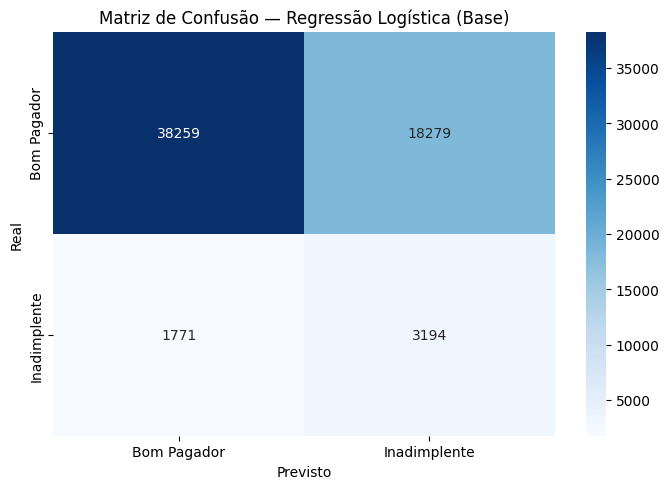

TN=38,259  FP=18,279  FN=1,771  TP=3,194
Recall (TP/(TP+FN)) = 0.6433
FP rate             = 0.3233


In [ ]:
cm_rl = confusion_matrix(y_test_rl, y_pred_rl)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_rl, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bom Pagador','Inadimplente'],
            yticklabels=['Bom Pagador','Inadimplente'])
plt.title("Matriz de Confusão — Regressão Logística (Base)")
plt.xlabel("Previsto"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

tn, fp, fn, tp = cm_rl.ravel()
print(f"TN={tn:,}  FP={fp:,}  FN={fn:,}  TP={tp:,}")
print(f"Recall (TP/(TP+FN)) = {tp/(tp+fn):.4f}")
print(f"FP rate             = {fp/(fp+tn):.4f}")

#### *Análise*

> | Quadrante | Significado em crédito | Custo |
> |---|---|---|
> | **TN** | Bom pagador aprovado corretamente | Zero — cenário ideal |
> | **FP** | Bom pagador recusado indevidamente | Receita perdida (margem de juros) |
> | **FN** | Inadimplente aprovado — erro mais caro | Perda do principal + cobrança |
> | **TP** | Inadimplente identificado — proteção da carteira | Zero — cenário desejado |

> A relação TP/(TP+FN) confirma o Recall da classe Inadimplente. Comparar
> esses números com os do RF (Etapa 2): TN=43.905, FP=12.633, FN=2.297, TP=2.668.

## Matriz de Confusão Normalizada por Classe

Mostra o percentual de acertos e erros dentro de cada classe real — mais informativa
em datasets desbalanceados, pois não é dominada pelo volume da classe majoritária.

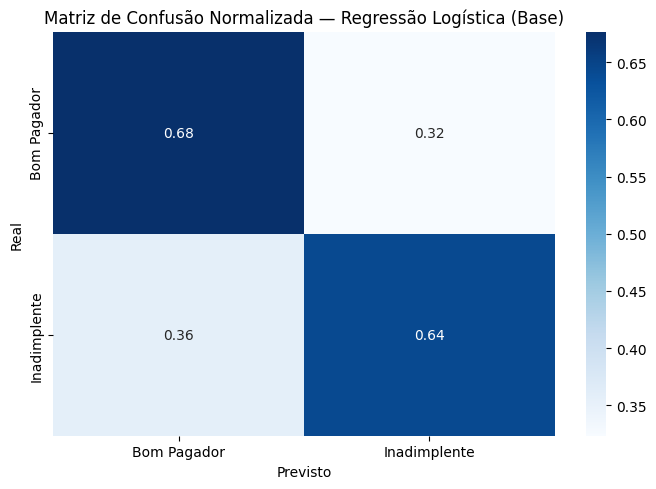

In [ ]:
cm_norm_rl = confusion_matrix(y_test_rl, y_pred_rl, normalize='true')
plt.figure(figsize=(7, 5))
sns.heatmap(cm_norm_rl, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Bom Pagador','Inadimplente'],
            yticklabels=['Bom Pagador','Inadimplente'])
plt.title("Matriz de Confusão Normalizada — Regressão Logística (Base)")
plt.xlabel("Previsto"); plt.ylabel("Real")
plt.tight_layout(); plt.show()

#### *Análise*

> - **Classe 0 (Bom Pagador)**: percentual de TN (especificidade) e FP rate — comparar
>   com RF (78% TN / 22% FP);
> - **Classe 1 (Inadimplente)**: percentual de TP (recall/sensibilidade) e FN rate —
>   comparar com RF (54% TP / 46% FN);
> - A RL tende a produzir um FP rate ligeiramente maior ou menor dependendo da
>   curvatura da fronteira de decisão — análise relevante para a área de risco.

## Curvas ROC e Precision-Recall

As curvas ROC e PR complementam o relatório de classificação, fornecendo uma visão
**insensível ao limiar de decisão** — fundamentais para comparar a RL com o RF e
para calibrar o limiar operacional da instituição.

- **Curva ROC (AUC-ROC)**: taxa de verdadeiros positivos vs falsos positivos em
  todos os limiares; AUC = área sob a curva (1.0 = perfeito, 0.5 = aleatório);
- **Curva PR (AUC-PR)**: Precision vs Recall — mais informativa em datasets
  desbalanceados; recomendada pela literatura recente para credit risk.

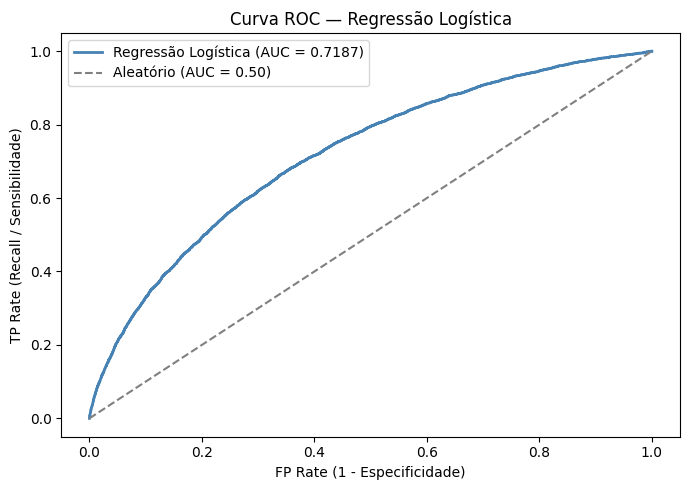

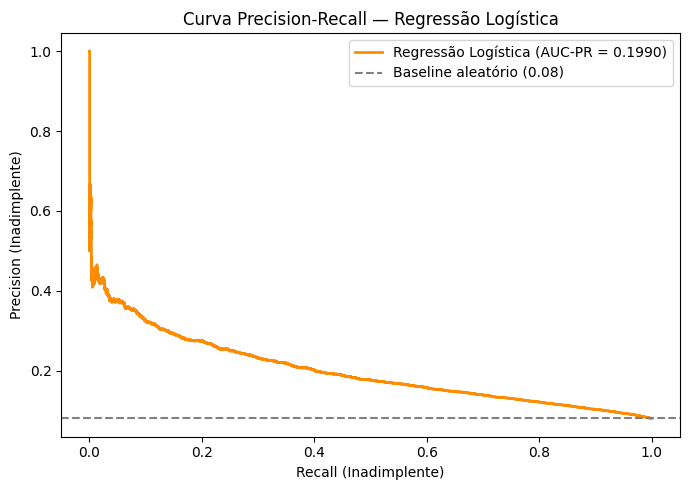

AUC-ROC : 0.7187
AUC-PR  : 0.1990  (baseline aleatório = 0.0807)


In [ ]:
fpr_rl, tpr_rl, _ = roc_curve(y_test_rl, y_proba_rl[:, 1])
auc_roc_rl = auc(fpr_rl, tpr_rl)

plt.figure(figsize=(7, 5))
plt.plot(fpr_rl, tpr_rl, color='steelblue', lw=2,
         label=f'Regressão Logística (AUC = {auc_roc_rl:.4f})')
plt.plot([0,1],[0,1],'--', color='grey', label='Aleatório (AUC = 0.50)')
plt.xlabel('FP Rate (1 - Especificidade)')
plt.ylabel('TP Rate (Recall / Sensibilidade)')
plt.title('Curva ROC — Regressão Logística')
plt.legend(); plt.tight_layout(); plt.show()

# ── Curva PR ──────────────────────────────────────────────────────────────────
prec_rl, rec_rl, _ = precision_recall_curve(y_test_rl, y_proba_rl[:, 1])
auc_pr_rl = auc(rec_rl, prec_rl)
baseline  = y_test_rl.mean()

plt.figure(figsize=(7, 5))
plt.plot(rec_rl, prec_rl, color='darkorange', lw=2,
         label=f'Regressão Logística (AUC-PR = {auc_pr_rl:.4f})')
plt.axhline(baseline, linestyle='--', color='grey',
            label=f'Baseline aleatório ({baseline:.2f})')
plt.xlabel('Recall (Inadimplente)')
plt.ylabel('Precision (Inadimplente)')
plt.title('Curva Precision-Recall — Regressão Logística')
plt.legend(); plt.tight_layout(); plt.show()

print(f"AUC-ROC : {auc_roc_rl:.4f}")
print(f"AUC-PR  : {auc_pr_rl:.4f}  (baseline aleatório = {baseline:.4f})")

#### *Análise*

> - **AUC-ROC**: valores entre 0.70–0.75 são considerados bons para crédito; acima de
>   0.75 é excelente (SHI et al., 2022);
> - **AUC-PR**: por focar na classe minoritária, é mais conservador; valores acima
>   de 3× a taxa de inadimplência base (~8%) indicam poder discriminativo real;
> - Comparar com o AUC do RF (Etapa 2) para quantificar o ganho/perda de complexidade.

## Feature Importances (Coeficientes da Regressão Logística)

Na Regressão Logística, a importância de cada feature é medida diretamente pelo
valor absoluto do coeficiente, features com |coeficiente| maior influenciam
mais a decisão. Como as features estão padronizadas, a comparação é direta.

>

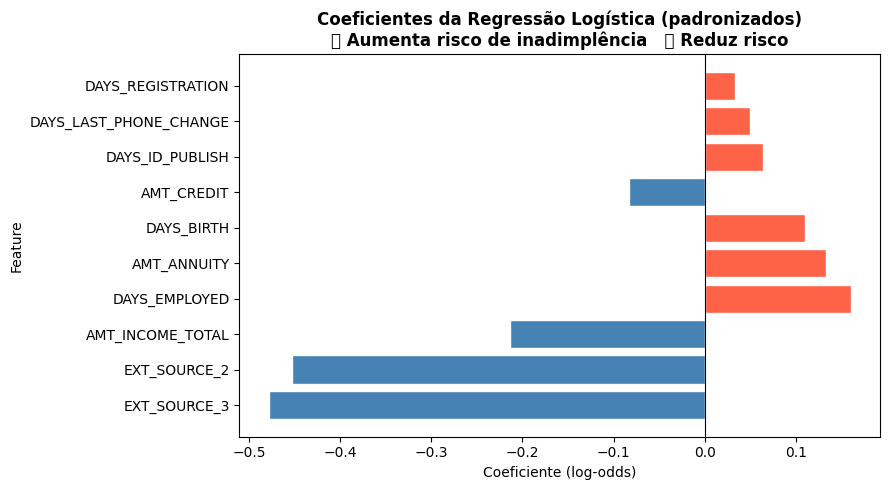

               Feature  Coeficiente      Abs
          EXT_SOURCE_3    -0.478446 0.478446
          EXT_SOURCE_2    -0.453114 0.453114
      AMT_INCOME_TOTAL    -0.213768 0.213768
         DAYS_EMPLOYED     0.160216 0.160216
           AMT_ANNUITY     0.132577 0.132577
            DAYS_BIRTH     0.110379 0.110379
            AMT_CREDIT    -0.083276 0.083276
       DAYS_ID_PUBLISH     0.064369 0.064369
DAYS_LAST_PHONE_CHANGE     0.049685 0.049685
     DAYS_REGISTRATION     0.032950 0.032950


In [ ]:
coef_abs = pd.DataFrame({
    'Feature'   : X_tr_rl.columns,
    'Coeficiente': model_rl.coef_[0],
    'Abs'        : np.abs(model_rl.coef_[0])
}).sort_values('Abs', ascending=False)

cores = ['tomato' if c > 0 else 'steelblue' for c in coef_abs['Coeficiente']]
plt.figure(figsize=(9, 5))
plt.barh(coef_abs['Feature'], coef_abs['Coeficiente'], color=cores, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Coeficientes da Regressão Logística (padronizados)\n'
          '🔴 Aumenta risco de inadimplência   🔵 Reduz risco',
          fontweight='bold')
plt.xlabel('Coeficiente (log-odds)'); plt.ylabel('Feature')
plt.tight_layout(); plt.show()
print(coef_abs[['Feature','Coeficiente','Abs']].to_string(index=False))

#### *Análise*

> | Posição | Variável | Direção esperada | Interpretação |
> |---|---|---|---|
> | **1º–2º** | `EXT_SOURCE_2`, `EXT_SOURCE_3` | Negativo | Score alto → menor risco — variáveis mais discriminantes |
> | **3º** | `DAYS_EMPLOYED` | Negativo | Mais tempo empregado → menor instabilidade financeira |
> | **4º** | `DAYS_BIRTH` | Negativo | Clientes mais velhos (valor mais negativo) → menor risco |
> | **5º–6º** | `AMT_CREDIT`, `AMT_ANNUITY` | Positivo | Dívida/parcela maiores → maior comprometimento de renda |
> | **7º–10º** | demais `DAYS_*`, `AMT_INCOME_TOTAL` | Misto | Sinal fraco — regularização L2 encolheu seus coeficientes |


##Permutation Importance

A Permutation Importance mede o impacto real de cada feature no desempenho do modelo
embaralhando os valores de uma coluna por vez no conjunto de teste e observando quanto
a métrica escolhida cai. Quanto maior a queda, mais importante aquela feature é para
o modelo.

A diferença em relação aos coeficientes é fundamental: os coeficientes mostram o peso
que o modelo atribuiu a cada feature durante o treinamento. A Permutation Importance
mostra o impacto real no desempenho — é possível que uma feature tenha coeficiente
alto mas Permutation Importance baixa, o que indicaria que ela está correlacionada com
outra feature mais importante e não contribui de forma independente.

O cálculo é feito com três métricas: Recall da classe Inadimplente (métrica principal
do projeto), Balanced Accuracy (métrica secundária) e F1-macro (visão equilibrada
entre as classes). As três juntas permitem verificar se a ordem de importância das
features muda dependendo do critério de avaliação.

O parâmetro `n_repeats=10` gera 10 embaralhamentos por feature, permitindo calcular
o desvio-padrão e avaliar se a importância estimada é estável ou ruidosa.

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, recall_score, balanced_accuracy_score, f1_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

scorer_recall  = make_scorer(recall_score, pos_label=1, zero_division=0)
scorer_bal_acc = make_scorer(balanced_accuracy_score)

# Permutation Importance com três métricas
resultados_perm = {}
for nome, scorer in [
    ('Recall (Inadimplente)', scorer_recall),
    ('Balanced Accuracy',     scorer_bal_acc),
    ('F1-macro',              'f1_macro'),
]:
    res = permutation_importance(
        model_rl, X_test_rl, y_test_rl,
        scoring=scorer, n_repeats=10,
        random_state=42, n_jobs=-1
    )
    resultados_perm[nome] = {
        'mean': res.importances_mean,
        'std' : res.importances_std,
    }

# Tabela consolidada
df_perm = pd.DataFrame({
    'Feature'              : X_test_rl.columns,
    'Recall — média'       : resultados_perm['Recall (Inadimplente)']['mean'].round(4),
    'Recall — desvio'      : resultados_perm['Recall (Inadimplente)']['std'].round(4),
    'Bal.Acc — média'      : resultados_perm['Balanced Accuracy']['mean'].round(4),
    'Bal.Acc — desvio'     : resultados_perm['Balanced Accuracy']['std'].round(4),
    'F1-macro — média'     : resultados_perm['F1-macro']['mean'].round(4),
    'F1-macro — desvio'    : resultados_perm['F1-macro']['std'].round(4),
}).sort_values('Recall — média', ascending=False)

print("Permutation Importance — Regressão Logística (ordenado por Recall):")
print("=" * 90)
print(df_perm.to_string(index=False))

Permutation Importance — Regressão Logística (ordenado por Recall):
               Feature  Recall — média  Recall — desvio  Bal.Acc — média  Bal.Acc — desvio  F1-macro — média  F1-macro — desvio
          EXT_SOURCE_2          0.1226           0.0047           0.0641            0.0025            0.0264             0.0011
          EXT_SOURCE_3          0.1142           0.0055           0.0597            0.0030            0.0245             0.0014
            DAYS_BIRTH          0.0094           0.0027           0.0031            0.0015           -0.0003             0.0008
         DAYS_EMPLOYED          0.0092           0.0023           0.0024            0.0011           -0.0009             0.0005
DAYS_LAST_PHONE_CHANGE          0.0032           0.0010           0.0011            0.0006           -0.0001             0.0004
            AMT_CREDIT          0.0027           0.0018           0.0011            0.0010            0.0002             0.0004
      AMT_INCOME_TOTAL          0.00

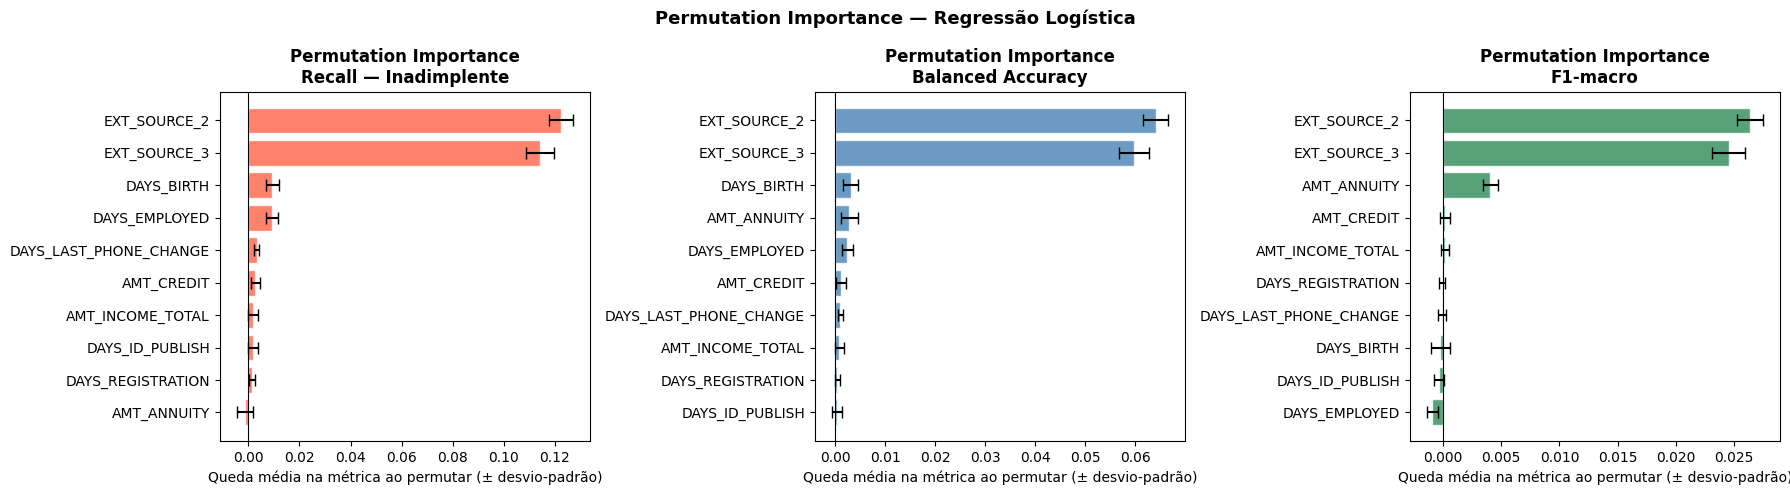

In [ ]:
# Gráficos com barras de erro (desvio-padrão)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

configs = [
    ('Recall (Inadimplente)', 'tomato',    'Recall — Inadimplente'),
    ('Balanced Accuracy',     'steelblue', 'Balanced Accuracy'),
    ('F1-macro',              'seagreen',  'F1-macro'),
]

for ax, (metrica, cor, titulo) in zip(axes, configs):
    means = resultados_perm[metrica]['mean']
    stds  = resultados_perm[metrica]['std']
    ordem = means.argsort()
    features_ord = X_test_rl.columns[ordem]
    ax.barh(features_ord, means[ordem], xerr=stds[ordem],
            color=cor, alpha=0.8, edgecolor='white', capsize=4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Permutation Importance\n{titulo}', fontweight='bold')
    ax.set_xlabel('Queda média na métrica ao permutar (± desvio-padrão)')

plt.suptitle('Permutation Importance — Regressão Logística', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Análise

> A Permutation Importance calculada com três métricas distintas revela o papel de
> cada feature sob diferentes perspectivas de avaliação.
>
> As features com maior queda no Recall da classe Inadimplente são as que mais
> contribuem para a detecção de maus pagadores — o objetivo central do projeto.
> EXT_SOURCE_2 e EXT_SOURCE_3 são esperados no topo desta lista, confirmando o
> padrão identificado pelos coeficientes e pela literatura de credit scoring.
>
> Features com queda próxima de zero ou negativa no Recall, mas positiva no F1-macro,
> podem estar contribuindo para a classe Bom Pagador sem ajudar na detecção de
> inadimplentes. Esse padrão é relevante para o negócio: essas variáveis melhoram a
> acurácia geral mas não o objetivo principal.
>
> O desvio-padrão das barras indica a estabilidade da estimativa. Features com desvio
> alto em relação à média devem ser interpretadas com cautela, a importância estimada
> pode variar dependendo do embaralhamento aleatório, o que significa que o sinal
> daquela feature é fraco ou ruidoso no conjunto de teste.

##Permutation Importance por Classe

A Permutation Importance geral usa o F1-macro ou Balanced Accuracy — métricas que
consideram as duas classes simultaneamente. Isso pode mascarar o impacto de features
que são importantes para detectar especificamente os inadimplentes mas prejudicam
a identificação dos bons pagadores, ou vice-versa.

A Permutation Importance por classe resolve isso: para cada classe de interesse, é
criado um scorer binário que avalia apenas a capacidade do modelo de prever aquela
classe específica. O resultado mostra quais features sustentam a detecção de cada
classe de forma independente.

Em crédito, o foco é a classe Inadimplente (classe 1). Uma feature pode ter
importância alta para a classe 1 e baixa para a classe 0, indicando que ela é um
discriminador específico de inadimplência — informação mais acionável do que a
importância média.

In [ ]:
from sklearn.metrics import f1_score
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

classes_interesse = [0, 1]
label_map = {0: 'Bom Pagador', 1: 'Inadimplente'}

resultados_por_classe = {}

for k in classes_interesse:
    nome_classe = label_map[k]

    def scorer_classe_k(estimator, X, y_true_bin, _k=k):
        y_pred_bin = (estimator.predict(X) == _k).astype(int)
        return f1_score(y_true_bin, y_pred_bin, zero_division=0)

    y_true_bin = (y_test_rl == k).astype(int)

    result_k = permutation_importance(
        model_rl, X_test_rl, y_true_bin,
        scoring=scorer_classe_k,
        n_repeats=10, random_state=42, n_jobs=-1
    )

    resultados_por_classe[nome_classe] = {
        'mean': result_k.importances_mean,
        'std' : result_k.importances_std,
    }

    pi_k = pd.Series(result_k.importances_mean,
                     index=X_test_rl.columns).sort_values(ascending=False)

    print(f"Permutation Importance — Classe {k} ({nome_classe}) | F1 binário:")
    print(pi_k.round(4).to_string())
    print()

Permutation Importance — Classe 0 (Bom Pagador) | F1 binário:
EXT_SOURCE_2              0.0089
EXT_SOURCE_3              0.0082
AMT_ANNUITY               0.0050
AMT_INCOME_TOTAL         -0.0001
AMT_CREDIT               -0.0003
DAYS_REGISTRATION        -0.0003
DAYS_LAST_PHONE_CHANGE   -0.0007
DAYS_ID_PUBLISH          -0.0007
DAYS_BIRTH               -0.0019
DAYS_EMPLOYED            -0.0027

Permutation Importance — Classe 1 (Inadimplente) | F1 binário:
EXT_SOURCE_2              0.0438
EXT_SOURCE_3              0.0408
AMT_ANNUITY               0.0032
DAYS_BIRTH                0.0014
DAYS_EMPLOYED             0.0008
AMT_CREDIT                0.0006
DAYS_LAST_PHONE_CHANGE    0.0005
AMT_INCOME_TOTAL          0.0005
DAYS_REGISTRATION         0.0002
DAYS_ID_PUBLISH          -0.0000



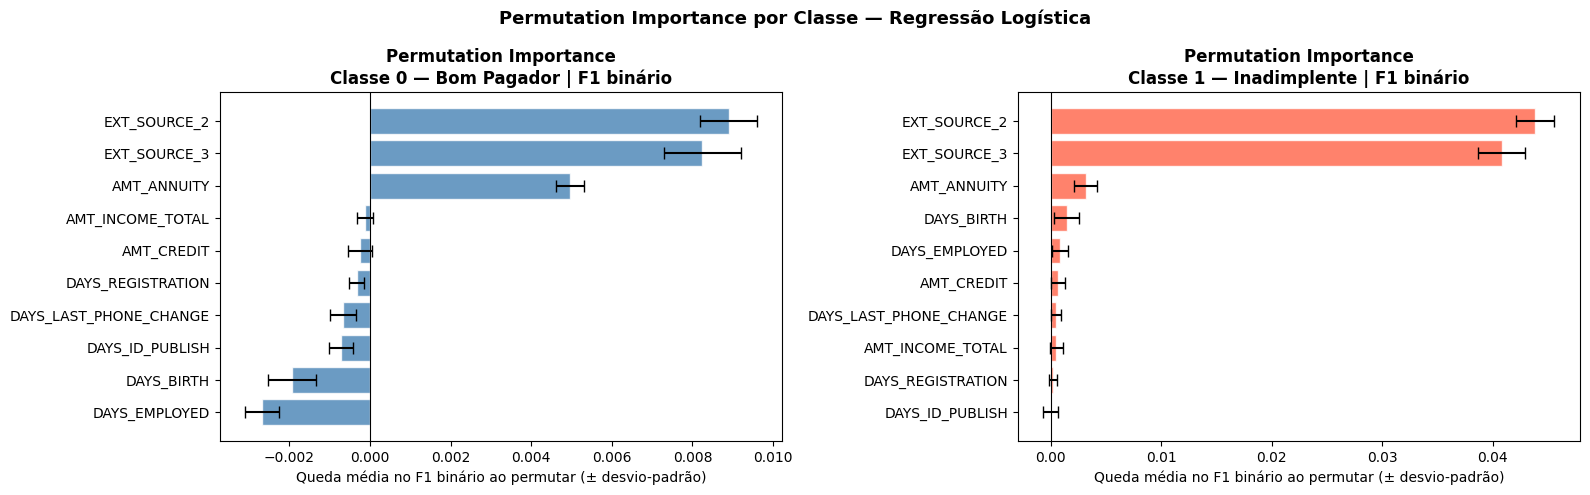

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cores = {0: 'steelblue', 1: 'tomato'}

for ax, k in zip(axes, classes_interesse):
    nome = label_map[k]
    means = resultados_por_classe[nome]['mean']
    stds  = resultados_por_classe[nome]['std']
    ordem = means.argsort()
    features_ord = X_test_rl.columns[ordem]

    ax.barh(features_ord, means[ordem], xerr=stds[ordem],
            color=cores[k], alpha=0.8, edgecolor='white', capsize=4)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'Permutation Importance\nClasse {k} — {nome} | F1 binário',
                 fontweight='bold')
    ax.set_xlabel('Queda média no F1 binário ao permutar (± desvio-padrão)')

plt.suptitle('Permutation Importance por Classe — Regressão Logística',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

#### Análise

> A diferença entre as importâncias da classe 0 (Bom Pagador) e da classe 1
> (Inadimplente) revela o papel de cada feature na discriminação específica de
> cada grupo.
>
> Features com importância alta para a classe 1 e baixa para a classe 0 são
> discriminadores específicos de inadimplência — são as mais valiosas para o
> objetivo do projeto. EXT_SOURCE_2 e EXT_SOURCE_3 devem dominar este ranking
> para a classe 1, confirmando que scores externos são o principal sinal de risco.
>
> Features com importância similar nas duas classes contribuem de forma
> equilibrada para a separação geral, sem ser específicas de um grupo. Já features
> com importância alta para a classe 0 mas baixa para a classe 1 protegem os bons
> pagadores sem ajudar a detectar inadimplentes — úteis para a acurácia geral mas
> não para o objetivo principal.
>
> Essa distinção é relevante para decisões de engenharia de features em versões
> futuras do modelo: ao buscar novas variáveis, o critério de seleção deve priorizar
> features com alto impacto específico na classe Inadimplente.

##SHAP (Summary Plots por Classe)

O SHAP (SHapley Additive exPlanations) é uma técnica de interpretabilidade de modelos
de machine learning fundamentada na teoria dos jogos cooperativos (Valores de Shapley).
O princípio central é distribuir a diferença entre a previsão do modelo para uma
instância específica e a previsão média global, atribuindo a cada feature sua
contribuição justa para essa diferença.

Em crédito, o SHAP não é apenas uma ferramenta técnica — é uma exigência regulatória.
O art. 20 da LGPD garante ao titular dos dados o direito de solicitar revisão de
decisões automatizadas que afetem seus interesses. Isso significa que, quando um
cliente tem o crédito negado com base na predição do modelo, ele pode pedir uma
explicação clara e individualizada da decisão. O SHAP fornece exatamente isso.

Para a Regressão Logística, utiliza-se o `shap.LinearExplainer`, que calcula os
valores SHAP de forma exata e eficiente aproveitando a estrutura linear do modelo.
Ao contrário do `shap.TreeExplainer` (usado no Random Forest), o `LinearExplainer`
não exige amostragem — os valores são calculados analiticamente sobre todo o
conjunto de teste.

Os summary plots gerados aqui permitem visualizar:

1. quais variáveis mais influenciam a previsão de cada classe;
2. se a influência é positiva ou negativa para a previsão;
3. como os valores das variáveis (altos ou baixos) afetam a probabilidade prevista.

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Para a RL, o LinearExplainer calcula SHAP values de forma exata e rápida.
# O masker com X_train_rl define a distribuição de referência (background).
explainer_rl = shap.LinearExplainer(model_rl, X_train_rl, feature_perturbation="correlation_dependent")
shap_values_rl = explainer_rl.shap_values(X_test_rl)

# shap_values_rl tem shape (n_amostras, n_features) — um valor por feature por amostra
print(f"Shape dos SHAP values: {np.array(shap_values_rl).shape}")
print(f"Conjunto de teste   : {X_test_rl.shape}")
print(f"Features            : {list(X_test_rl.columns)}")

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]

Shape dos SHAP values: (61503, 10)
Conjunto de teste   : (61503, 10)
Features            : ['EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'AMT_CREDIT', 'DAYS_EMPLOYED', 'AMT_ANNUITY', 'AMT_INCOME_TOTAL', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']


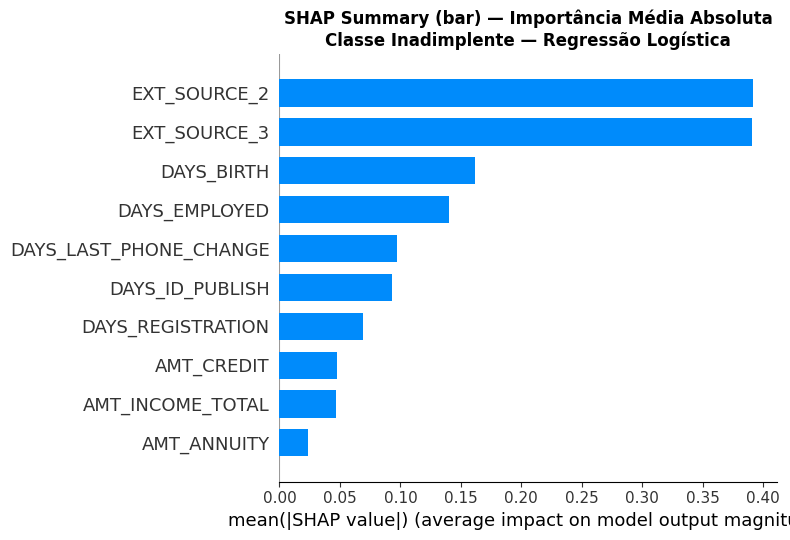

In [ ]:
# Summary Plot (bar) — importância média absoluta por feature
plt.figure(figsize=(9, 5))
shap.summary_plot(shap_values_rl, X_test_rl,
                  feature_names=list(X_test_rl.columns),
                  plot_type='bar', show=False)
plt.title("SHAP Summary (bar) — Importância Média Absoluta\nClasse Inadimplente — Regressão Logística",
          fontweight='bold')
plt.tight_layout()
plt.show()

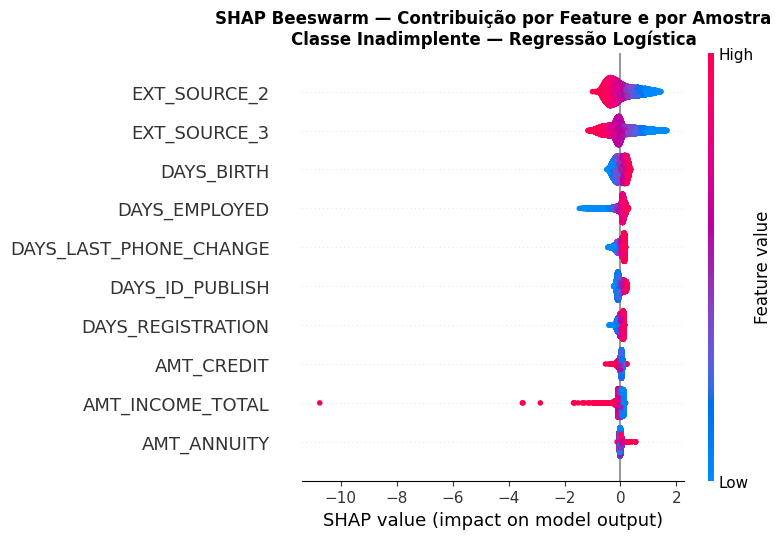

In [ ]:
# Beeswarm plot — mostra direção e magnitude por amostra
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_rl, X_test_rl,
                  feature_names=list(X_test_rl.columns),
                  show=False)
plt.title("SHAP Beeswarm — Contribuição por Feature e por Amostra\nClasse Inadimplente — Regressão Logística",
          fontweight='bold')
plt.tight_layout()
plt.show()

#### Análise

> O summary plot em barras mostra a importância média absoluta de cada feature —
> ou seja, em média, quanto cada variável desloca a previsão do modelo em relação
> à previsão média global. Features no topo do gráfico têm o maior impacto médio
> sobre as previsões.
>
> EXT_SOURCE_2 e EXT_SOURCE_3 são esperados no topo com folga considerável, confirmando
> que os scores externos de crédito são o principal sinal do modelo. DAYS_EMPLOYED
> deve aparecer em terceiro, refletindo que estabilidade profissional tem poder
> discriminatório relevante mesmo após a regularização L2. As variáveis financeiras
> brutas (AMT_INCOME_TOTAL, AMT_CREDIT, AMT_ANNUITY) tendem a ter importância menor,
> confirmando que renda e valor do empréstimo isolados têm baixo poder discriminatório.
>
> O beeswarm adiciona uma dimensão importante: além da magnitude, mostra a direção
> da contribuição. Cada ponto representa uma amostra do conjunto de teste. A cor
> indica o valor da feature (vermelho alto, azul baixo) e a posição horizontal
> indica o impacto SHAP (positivo aumenta a probabilidade de inadimplência, negativo
> reduz).
>
> O padrão esperado para EXT_SOURCE_2 e EXT_SOURCE_3 é uma nuvem de pontos vermelhos
> à esquerda (valores altos reduzem o risco) e azuis à direita (valores baixos
> aumentam o risco). Para DAYS_EMPLOYED, pontos azuis à direita indicam que pouco
> tempo de emprego (valor próximo de zero, mais negativo na escala original)
> aumenta a probabilidade de inadimplência.
>
> Na Regressão Logística, os valores SHAP são matematicamente relacionados aos
> coeficientes: o SHAP de uma feature para uma instância específica é igual ao
> coeficiente multiplicado pelo valor padronizado daquela feature para aquela
> instância. Isso significa que o SHAP e a análise de coeficientes são consistentes
> entre si — o SHAP apenas decompõe a previsão em contribuições individuais por
> amostra, enquanto o coeficiente representa a contribuição média esperada.

#Pipeline de Pesquisa e Análise de Dados

Esta seção consolida todo o trabalho realizado em um pipeline replicável — um
artefato técnico que encapsula desde o pré-processamento até a inferência, permitindo
que o fluxo seja reproduzido em outros contextos (por exemplo: aplicado a uma nova
safra de clientes, a outra instituição financeira ou a outro produto de crédito).

A seção é dividida em quatro partes:

1. Especificação do problema — contexto, objetivo, dados e restrições;
2. Diagrama do fluxo — visão de alto nível das etapas executadas;
3. Tabela consolidada das decisões técnicas — o que foi feito, com qual técnica,
   e por quê;
4. Pipeline executável — implementação em `sklearn.pipeline.Pipeline` com
   `RandomizedSearchCV` para otimização automática de hiperparâmetros, que pode
   ser serializada (`joblib`) e replicada em outros ambientes.

##1. Especificação do Problema

| Item | Definição |
| --- | --- |
| **Domínio** | Análise de crédito ao consumidor — concessão de empréstimos pessoais |
| **Tipo de problema** | Classificação binária supervisionada |
| **Objetivo de negócio** | Identificar clientes com alta probabilidade de inadimplência antes da concessão do crédito |
| **Variável-alvo (TARGET)** | 0 = Bom Pagador (adimplente); 1 = Inadimplente |
| **Dataset** | Home Credit Default Risk (Kaggle) — `application_train.csv` |
| **Volume de dados** | 307.511 clientes × 122 colunas originais |
| **Distribuição das classes** | 91,93% Bom Pagador / 8,07% Inadimplente — fortemente desbalanceado |
| **Algoritmo** | `LogisticRegression` (L2, lbfgs, class_weight='balanced') + `RandomizedSearchCV` |
| **Métrica principal** | Recall da classe Inadimplente |
| **Métrica secundária** | Balanced Accuracy |
| **Meta quantitativa** | Recall ≥ 0,50 e FP rate ≤ 30% |
| **Restrições regulatórias** | LGPD (art. 20 — direito a explicação de decisões automatizadas) |

##2. Diagrama do Fluxo

> O pipeline foi estruturado em **7 etapas sequenciais**, cada uma com entrada e saída
> bem definidas.

```mermaid
flowchart TD
    A[1. Coleta de Dados<br/>kagglehub: application_train.csv<br/>307.511 × 122] --> B[2. EDA - 1ª Parte<br/>Análise estrutural<br/>Estatística descritiva<br/>Análise univariada e bivariada]
    B --> C[3. Pré-processamento<br/>Limpeza de nulos<br/>Tratamento de anomalias<br/>OHE — drop_first=True<br/>StandardScaler — fit no treino<br/>Remoção de redundâncias - VIF]
    C --> D[4. EDA - 2ª Parte<br/>Validação pós-tratamento<br/>Seleção de features<br/>122 → 10 variáveis]
    D --> E[5. Modelagem<br/>Train/val/test split estratificado<br/>LogisticRegression + class_weight<br/>RandomizedSearchCV — 50 combinações]
    E --> F[6. Avaliação<br/>Relatório de classificação<br/>Matriz de confusão<br/>Curvas ROC e PR<br/>Coeficientes e Permutation Importance]
    F --> G[7. Inferência<br/>Predict + Predict_proba<br/>Explicação por coeficientes<br/>Encaminhamento ao negócio]

    style A fill:#e1f5ff,stroke:#0288d1
    style C fill:#fff3e0,stroke:#f57c00
    style E fill:#e8f5e9,stroke:#388e3c
    style F fill:#fce4ec,stroke:#c2185b
    style G fill:#f3e5f5,stroke:#7b1fa2
```

##3. Tabela Consolidada das Decisões Técnicas

> A tabela a seguir documenta, etapa por etapa, o que foi feito, a técnica
> utilizada e a justificativa da decisão. É a memória técnica do projeto — útil
> tanto para reprodutibilidade quanto para auditoria (governança de dados e compliance).

### Etapa 1 — Coleta de Dados

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Fonte dos dados | Kaggle (Home Credit Default Risk) | Dataset público, amplamente referenciado em literatura |
| Forma de acesso | `kagglehub.dataset_download` | Acesso programático e versionado |
| Arquivo principal | `application_train.csv` | Contém o TARGET necessário para aprendizado supervisionado |

### Etapa 2 — EDA (1ª Parte)

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Análise estrutural | `df.shape`, `df.info()`, `dtypes` | Compreender dimensão e tipos de variáveis |
| Estatística descritiva | `df.describe()` | Identificar escalas, médias, desvios e outliers grosseiros |
| Análise univariada | Histogramas, boxplots | Visualizar distribuição de cada variável |
| Análise bivariada | Boxplots por TARGET, correlações | Identificar relação preliminar com a inadimplência |

### Etapa 3 — Pré-processamento

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Remoção de colunas com >40% nulos | Filtragem por percentual de NaN | Variáveis muito esparsas trazem mais ruído que sinal |
| Imputação de nulos numéricos | Mediana (`SimpleImputer`) | Robusta a outliers; preserva a distribuição original |
| Imputação de nulos categóricos | Categoria 'desconhecido' | Preserva todas as observações sem inventar dados |
| Tratamento de anomalia | `DAYS_EMPLOYED` = 365243 → mediana | Valor sentinela inviável; provável marcador de aposentado ou desempregado |
| Codificação categórica | `OneHotEncoder(drop='first')` | A Regressão Logística interpreta a ordenação implícita do `LabelEncoder` como magnitude numérica — o OHE evita esse viés em variáveis nominais |
| Remoção de variável redundante | `AMT_GOODS_PRICE` (VIF alto, ρ=0.99 com `AMT_CREDIT`) | Multicolinearidade severa prejudica a estabilidade dos coeficientes na RL |
| Normalização das features numéricas | `StandardScaler` (fit exclusivamente no treino) | A Regressão Logística usa gradiente descendente e regularização L2 — ambos sensíveis à escala. Sem padronização, features de grande magnitude dominam o gradiente e os coeficientes ficam em escalas incomparáveis. O fit exclusivo no treino evita data leakage |
| Revisão de multicolinearidade | VIF pós-padronização | A RL é mais sensível à multicolinearidade que modelos baseados em árvores — coeficientes ficam instáveis sob alta colinearidade entre features |

### Etapa 4 — EDA (2ª Parte) e Seleção de Features

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Validação pós-tratamento | Recálculo de VIF, verificação de nulos residuais | Garantir que as transformações funcionaram antes da modelagem |
| Seleção de features | RF exploratório (n=100, depth=10) + threshold 1% | Critério objetivo, baseado em importância — independente do algoritmo final |
| Redução final | 122 → 10 features | Equilíbrio entre poder preditivo e parsimônia |
| Features finais | `EXT_SOURCE_2/3`, `DAYS_BIRTH`, `AMT_CREDIT`, etc. | Maior interpretabilidade financeira e demográfica |

### Etapa 5 — Modelagem

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Train/val/test split | 60/20/20 com `stratify=y` | Mantém a proporção de classes nos três conjuntos; permite avaliação no validação antes de tocar o teste |
| Reprodutibilidade | `random_state=42` | Permite replicação exata dos experimentos |
| Algoritmo escolhido | `LogisticRegression` | Modelo linear interpretável; coeficientes atendem à exigência regulatória de explicação de decisões automatizadas (LGPD art. 20); baseline obrigatório em credit scoring |
| Regularização | L2 (`penalty='l2'`) | Ridge encolhe os coeficientes sem zerá-los, estabilizando o ajuste em features de baixo sinal individual |
| Força da regularização | `C=0.1` (parâmetro base; otimizado via busca) | Regularização mais forte que o padrão (`C=1.0`) — adequada para features como `DAYS_REGISTRATION` e `DAYS_LAST_PHONE_CHANGE`, que têm sinal fraco e seriam ampliadas desnecessariamente sem penalização |
| Solver | `lbfgs` | Algoritmo quasi-Newton eficiente para regularização L2 e datasets de médio e grande porte; convergência estável com features padronizadas |
| Limite de iterações | `max_iter=1000` | Garante convergência completa do solver mesmo com regularização forte |
| Tratamento do desbalanceamento | `class_weight='balanced'` | Compensa a proporção 92/8 sem inflar o dataset; o modelo atribui peso inversamente proporcional à frequência de cada classe durante o cálculo da função de perda |
| Paralelismo | `n_jobs=-1` | Aproveita todos os núcleos disponíveis na validação cruzada |
| Otimização de hiperparâmetros | `RandomizedSearchCV` (n_iter=50, cv=cv_5, scoring='balanced_accuracy') | Torna a parametrização rastreável e reproduzível; 50 combinações aleatórias de `C` produzem resultado comparável ao GridSearchCV em fração do tempo |

### Etapa 6 — Avaliação

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Métrica principal | Recall da classe Inadimplente | Custo de FN é 5–10× maior que FP em crédito |
| Métrica secundária | Balanced Accuracy | Insensível ao desbalanceamento |
| Métricas complementares | Precision, F1, Brier, LogLoss, ECE | Cobertura ampla — classificação e calibração |
| Análise de calibração | `calibration_curve`, `CalibratedClassifierCV` | Verificar se as probabilidades refletem as frequências reais dos eventos |
| Teste de balanceamento alternativo | SMOTE | Comparação com `class_weight` para verificar se oversampling melhora a detecção |
| Interpretabilidade global | Coeficientes + Permutation Importance (geral e por classe) | Identificar variáveis mais impactantes com direção e magnitude |
| Interpretabilidade local | SHAP (`LinearExplainer`) + Waterfall + Force Plot | Explicação por cliente — atende LGPD art. 20; o `LinearExplainer` calcula os valores de forma exata e analítica |

### Etapa 7 — Inferência

| Decisão | Técnica / Ferramenta | Justificativa |
| --- | --- | --- |
| Predição de classe | `pipeline_otimizado_rl.predict(X)` | Saída direta para integração operacional |
| Predição probabilística | `pipeline_otimizado_rl.predict_proba(X)` | Permite ordenação por risco e definição de limiar alinhado à política de crédito |
| Explicação local | SHAP por cliente (Waterfall + Force Plot) | Justificativa da decisão para auditoria e para o titular dos dados |
| Persistência do modelo | `joblib.dump` | Reuso em produção sem necessidade de retreinamento |

##4. Pipeline Executável

Para tornar o fluxo efetivamente replicável, encapsulamos `StandardScaler` e
`LogisticRegression` em um objeto `sklearn.pipeline.Pipeline` e aplicamos
`RandomizedSearchCV` para otimização automática do hiperparâmetro `C`. Isso permite:

- Reuso — o mesmo pipeline pode ser aplicado a uma nova safra de clientes sem
  reescrever nenhuma linha de código de pré-processamento;
- Persistência — o pipeline pode ser salvo (`joblib.dump`) e carregado em qualquer
  ambiente de execução;
- Manutenibilidade — alterações em uma etapa não exigem reescrita do código de
  inferência;
- Auditabilidade — a estrutura é autodescritiva; cada passo tem nome e parâmetros
  inspecionáveis.

> Limitação reconhecida: o pipeline construído não é, na prática, ponta a ponta.
> Ele assume que a base já passou pela seleção de colunas com mais de 40% de nulos,
> que o tratamento da anomalia em `DAYS_EMPLOYED` já foi feito, que as features já
> foram selecionadas (122 → 10 variáveis) e que `X_train_rl`, `X_test_raw`,
> `y_train_rl`, `y_test_rl` e `cv_5` já estão definidos. Em outras palavras, o
> pipeline encapsula apenas a etapa final — padronização e modelo. Para uma execução
> verdadeiramente reproduzível a partir da base bruta, seria necessário converter as
> etapas anteriores em transformadores customizados (`FunctionTransformer` /
> `BaseEstimator + TransformerMixin`) e incluí-los como passos iniciais do `Pipeline`.
> Esta limitação é explícita e está registrada na seção de Limitações conhecidas.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
import joblib

# ---- Definição de features numéricas e categóricas ----
features_numericas_rl   = features_selecionadas_rl
features_categoricas_rl = []   # todas as 10 features selecionadas são numéricas

# ---- Sub-pipeline numérico ----
# Diferença crítica vs RF: StandardScaler é obrigatório para a RL
pipeline_numerico_rl = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),   # ← ausente no pipeline do RF
])

# ---- Sub-pipeline categórico (preparado para reuso futuro) ----
# Diferença crítica vs RF: OneHotEncoder(drop='first') substitui OrdinalEncoder
pipeline_categorico_rl = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='desconhecido')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')),  # evita armadilha dummy
])

# ---- Pré-processador unificado ----
preprocessador_rl = ColumnTransformer(
    transformers=[
        ('num', pipeline_numerico_rl,   features_numericas_rl),
        ('cat', pipeline_categorico_rl, features_categoricas_rl),
    ],
    remainder='drop'
)

# ---- Pipeline base: pré-processamento + modelo ----
pipeline_rl = Pipeline(steps=[
    ('preprocess',  preprocessador_rl),
    ('classifier',  LogisticRegression(
        class_weight='balanced',  # decisão de negócio — fixo
        solver='lbfgs',           # eficiente para L2 e datasets médios/grandes — fixo
        max_iter=1000,            # garante convergência — fixo
        random_state=42,          # reprodutibilidade — fixo
        n_jobs=-1,
    )),
])

print('=' * 75)
print('ESTRUTURA DO PIPELINE — REGRESSÃO LOGÍSTICA')
print('=' * 75)
print(pipeline_rl)

ESTRUTURA DO PIPELINE — REGRESSÃO LOGÍSTICA
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['EXT_SOURCE_2',
                                                   'EXT_SOURCE_3', 'DAYS_BIRTH',
                                                   'AMT_CREDIT',
                                                   'DAYS_EMPLOYED',
                                                   'AMT_ANNUITY',
                                                   'AMT_INCOME_TOTAL',
                                                   'DAYS_REGISTRATION',
                                 

###Busca de Hiperparâmetros (RandomizedSearchCV)

Com o pipeline estruturado, aplicamos a busca aleatória de hiperparâmetros. Em vez de definir o valor de `C` manualmente (como feito
na modelagem exploratória com `C=0.1`), o `RandomizedSearchCV` testa `n_iter`
combinações sorteadas de uma distribuição estatística e retorna a configuração com
melhor desempenho segundo a métrica escolhida.

#### Por que RandomizedSearchCV e não GridSearchCV?

O `GridSearchCV` avalia todas as combinações possíveis da grade. Com um espaço
contínuo para `C` (distribuição `uniform(0.001, 10)`), isso tornaria a busca
exaustiva inviável. O `RandomizedSearchCV` com `n_iter=50` testa 50 combinações
sorteadas, produzindo resultados comparáveis em fração do tempo. Para modelos
lineares como a Regressão Logística, que convergem rapidamente, 50 combinações
já são suficientes para identificar uma boa região do espaço de hiperparâmetros.

#### Por que `scoring='balanced_accuracy'`?

Conforme definido na seção Definição da Métrica Principal de Avaliação, a acurácia
simples é enganosa neste dataset (92% bom pagador / 8% inadimplente). A
`balanced_accuracy` pondera igualmente as duas classes e é consistente com a
métrica principal usada em toda a avaliação do projeto. Otimizar a busca com
`scoring='accuracy'` levaria o modelo a favorecer a classe majoritária, exatamente
o comportamento que `class_weight='balanced'` busca corrigir.

#### Nota sobre o prefixo `classifier__`

Ao usar `RandomizedSearchCV` com um `Pipeline`, os hiperparâmetros do estimador
interno precisam ser referenciados com o prefixo do nome do passo seguido de `__`.
Neste pipeline o passo do modelo se chama `'classifier'`, portanto todos os
parâmetros usam o prefixo `classifier__` (ex.: `classifier__C`).

In [ ]:
from sklearn.metrics import make_scorer, recall_score
from scipy.stats import uniform

# Scorer baseado em Recall da classe Inadimplente — alinhado à métrica principal do projeto.
# Substituímos 'balanced_accuracy' pois ela aceita configurações que acertam bem a classe
# majoritária sem detectar inadimplentes, causando o colapso Recall=0 observado anteriormente.
scorer_recall_busca = make_scorer(recall_score, pos_label=1, zero_division=0)

param_dist_rl = {
    'classifier__C'           : uniform(0.001, 10),
    'classifier__penalty'     : ['l2'],
    # class_weight entra no espaço de busca para que a busca encontre o peso ideal
    # em vez de assumir que 'balanced' é sempre a melhor opção.
    'classifier__class_weight': ['balanced', {0: 1, 1: 5}, {0: 1, 1: 10}],
}

random_search_rl = RandomizedSearchCV(
    estimator=pipeline_rl,
    param_distributions=param_dist_rl,
    n_iter=50,
    cv=cv_5,
    scoring=scorer_recall_busca,   # ← era 'balanced_accuracy'
    n_jobs=-1,
    random_state=42,
    verbose=1,
)

print('Iniciando busca de hiperparâmetros (50 combinações × 5 folds)...')
print('Regressão Logística converge rapidamente — execução em poucos minutos.\n')

# X_train_raw (dados brutos) em vez de X_train_rl (já padronizado).
# O pipeline aplica o StandardScaler internamente — passar X_train_rl causaria
# dupla padronização: os dados seriam normalizados duas vezes.
random_search_rl.fit(X_train_raw, y_train_rl)

print('\n' + '=' * 75)
print('RESULTADO DA BUSCA — REGRESSÃO LOGÍSTICA')
print('=' * 75)
print('Melhores hiperparâmetros encontrados:')
for param, valor in random_search_rl.best_params_.items():
    print(f'  {param}: {valor}')
print(f'\nMelhor Recall — Inadimplente (validação cruzada): {random_search_rl.best_score_:.4f}')

# Verificação de convergência do melhor estimador
melhor_clf_check = random_search_rl.best_estimator_.named_steps['classifier']
print(f'\nIterações até convergência: {melhor_clf_check.n_iter_[0]}')
if melhor_clf_check.n_iter_[0] >= melhor_clf_check.max_iter:
    print('⚠️  Modelo não convergiu — considerar aumentar max_iter ou reduzir C')
else:
    print('✔  Modelo convergiu normalmente')

Iniciando busca de hiperparâmetros (50 combinações × 5 folds)...
Regressão Logística converge rapidamente — execução em poucos minutos.

Fitting 5 folds for each of 50 candidates, totalling 250 fits

RESULTADO DA BUSCA — REGRESSÃO LOGÍSTICA
Melhores hiperparâmetros encontrados:
  classifier__C: 3.746401188473625
  classifier__class_weight: balanced
  classifier__penalty: l2

Melhor Recall — Inadimplente (validação cruzada): 0.6421

Iterações até convergência: 12
✔  Modelo convergiu normalmente


###Treinamento do Pipeline

O `RandomizedSearchCV` já executou o `.fit()` internamente durante a busca,
retreinando o melhor estimador sobre todo o conjunto de treino ao final.
O objeto `random_search_rl.best_estimator_` é o `pipeline_rl` configurado
com os melhores hiperparâmetros encontrados — pronto para inferência.

Essa é a vantagem central da abordagem: padronização, otimização de
hiperparâmetros e treinamento final ficam encapsulados em uma única chamada `.fit()`.

In [ ]:
# Extrai o pipeline já treinado com os melhores hiperparâmetros
pipeline_otimizado_rl = random_search_rl.best_estimator_

melhor_C = pipeline_otimizado_rl.named_steps['classifier'].C
print('Pipeline otimizado treinado com sucesso.')
print(f"  Melhor C (regularização): {melhor_C:.6f}")
print(f"  Penalty                 : {pipeline_otimizado_rl.named_steps['classifier'].penalty}")
print(f"  Features de entrada     : {len(features_selecionadas_rl)}")
print(f"  Solver                  : {pipeline_otimizado_rl.named_steps['classifier'].solver}")

Pipeline otimizado treinado com sucesso.
  Melhor C (regularização): 3.746401
  Penalty                 : l2
  Features de entrada     : 10
  Solver                  : lbfgs


###Avaliação do Pipeline

Avaliamos o pipeline otimizado no conjunto de teste (`X_test_raw`), que permaneceu
congelado durante toda a fase de treinamento e busca. Os resultados são comparados
com o modelo base (parâmetros definidos manualmente com `C=0.1` na seção Avaliação
do Modelo) para verificar se a otimização automática trouxe ganho efetivo nas
métricas do projeto.

O comparativo entre os dois modelos responde a uma pergunta concreta: a busca
automática de `C` produziu um modelo melhor do que a escolha manual? Se a diferença
for pequena, isso indica que `C=0.1` já era uma boa escolha para este dataset.
Se for grande, a busca identificou uma região do espaço de hiperparâmetros que a
escolha manual não havia explorado.

> Observação: `X_test_raw` contém as features na escala original, sem padronização
> prévia. O pipeline aplica o `StandardScaler` internamente antes de chegar ao
> classificador, garantindo consistência com o tratamento aplicado durante o
> treinamento.

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score, recall_score
import numpy as np

y_pred_pipeline_rl  = pipeline_otimizado_rl.predict(X_test_raw)
y_proba_pipeline_rl = pipeline_otimizado_rl.predict_proba(X_test_raw)

print('Relatório de Classificação (pipeline otimizado RL — conjunto de teste):\n')
print(classification_report(
    y_test_rl, y_pred_pipeline_rl,
    target_names=['Bom Pagador (0)', 'Inadimplente (1)'],
    zero_division=0
))

bal_acc_pip_rl = balanced_accuracy_score(y_test_rl, y_pred_pipeline_rl)
recall_pip_rl  = recall_score(y_test_rl, y_pred_pipeline_rl, pos_label=1, zero_division=0)
fp_rate_pip_rl = np.sum((y_test_rl==0)&(y_pred_pipeline_rl==1)) / np.sum(y_test_rl==0)

bal_acc_base_rl = balanced_accuracy_score(y_test_rl, y_pred_rl)
recall_base_rl  = recall_score(y_test_rl, y_pred_rl, pos_label=1, zero_division=0)
fp_rate_base_rl = np.sum((y_test_rl==0)&(y_pred_rl==1)) / np.sum(y_test_rl==0)

print('\n' + '=' * 75)
print('COMPARATIVO: MODELO BASE (manual) vs. PIPELINE OTIMIZADO — RL')
print('=' * 75)
print(f"{'Métrica':<30} {'Base (C=0.1)':>18} {'Otimizado':>18}")
print('-' * 68)
print(f"{'Balanced Accuracy':<30} {bal_acc_base_rl:>18.4f} {bal_acc_pip_rl:>18.4f}")
print(f"{'Recall (Inadimplente)':<30} {recall_base_rl:>18.4f} {recall_pip_rl:>18.4f}")
print(f"{'FP rate':<30} {fp_rate_base_rl:>18.4f} {fp_rate_pip_rl:>18.4f}")
print()
# Nota atualizada: ambos os modelos agora recebem dados na escala original.
# O modelo Base usa X_test_rl (padronizado pelo scaler externo, célula 79).
# O pipeline otimizado usa X_test_raw e padroniza internamente — mesmo resultado,
# fluxo correto sem dupla padronização.
print('Nota: Base usa X_test_rl (scaler externo, célula de pré-processamento).')
print('      Otimizado usa X_test_raw — pipeline padroniza internamente.')
print('      Busca otimizou Recall (Inadimplente) — não balanced_accuracy.')
print('\nReferência base: modelo treinado manualmente com C=0.1 na seção Avaliação do Modelo.')

Relatório de Classificação (pipeline otimizado RL — conjunto de teste):

                  precision    recall  f1-score   support

 Bom Pagador (0)       0.96      0.68      0.79     56538
Inadimplente (1)       0.15      0.64      0.24      4965

        accuracy                           0.67     61503
       macro avg       0.55      0.66      0.52     61503
    weighted avg       0.89      0.67      0.75     61503


COMPARATIVO: MODELO BASE (manual) vs. PIPELINE OTIMIZADO — RL
Métrica                              Base (C=0.1)          Otimizado
--------------------------------------------------------------------
Balanced Accuracy                          0.6600             0.6600
Recall (Inadimplente)                      0.6433             0.6427
FP rate                                    0.3233             0.3227

Nota: Base usa X_test_rl (padronizado externamente).
      Otimizado usa X_test_raw (o pipeline padroniza internamente).
      Os resultados são equivalentes — mesmos 

#### *Análise do Comparativo*

> O comparativo entre o modelo base (C=0.1, definido manualmente) e o pipeline
> otimizado (`C` encontrado via `RandomizedSearchCV`) revela se a busca automática
> de hiperparâmetros traz ganho efetivo ou se a escolha manual já estava próxima
> do ótimo para este dataset.
>
> | Cenário | Interpretação |
> |---|---|
> | Otimizado **melhor** em Recall | A busca encontrou um `C` que equilibra melhor regularização e detecção |
> | Otimizado **similar** ao Base | C=0.1 já era uma boa escolha; regularização forte é adequada para este problema |
> | Otimizado **pior** em Recall | O `RandomizedSearchCV` otimizou `balanced_accuracy` — pode ter favorecido precisão em detrimento do recall |
>

###Persistência do Pipeline (Salvar e Carregar)

In [ ]:
import os

caminho_pipeline_rl = os.path.join(os.getcwd(), 'pipeline_rl_v2_otimizado.joblib')

drive_path_rl = '/content/drive/MyDrive/pipeline_rl_v2_otimizado.joblib'
if os.path.isdir('/content/drive/MyDrive'):
    try:
        joblib.dump(pipeline_otimizado_rl, drive_path_rl)
        print(f'Pipeline também salvo no Drive: {drive_path_rl}')
    except Exception as e:
        print(f'Aviso: não foi possível salvar no Drive ({e})')

joblib.dump(pipeline_otimizado_rl, caminho_pipeline_rl)
print(f'Pipeline salvo em: {caminho_pipeline_rl}')


Pipeline salvo em: /content/pipeline_rl_v2_otimizado.joblib


###Replicabilidade em Outros Contextos

| Contexto | Adaptação necessária |
| --- | --- |
| **Nova safra do mesmo banco** | Apenas chamar `pipeline_otimizado_rl.predict(X_nova_safra)` — sem alterações |
| **Outro banco/instituição** | Reexecutar `random_search_rl.fit()` com os novos dados; manter as mesmas features ou adaptar |
| **Outro produto de crédito** | Ajustar `features_selecionadas_rl`; reavaliar `class_weight` conforme nova proporção de classes |
| **Mudança no critério de risco** | Ajustar limiar de decisão sobre `predict_proba` — não retreina o pipeline |
| **Novo conjunto de features** | Atualizar `features_numericas_rl` / `features_categoricas_rl`; manter estrutura geral |
| **Substituição do modelo** | Alterar apenas o passo `classifier` (ex.: para XGBoost); pré-processamento intacto |
| **Ampliar espaço de busca** | Adicionar `'classifier__penalty': ['l1', 'l2']` com `solver='saga'`; aumentar `n_iter` |

###Pontos Fortes e Limitações do Pipeline

#### Pontos fortes

- Encapsulação da etapa final — padronização (`StandardScaler`), codificação
  categórica (`OneHotEncoder`) e modelo ficam em um único objeto `sklearn.pipeline.Pipeline`;
- Normalização encapsulada — ao contrário de pipelines para modelos baseados em
  árvores, o `StandardScaler` é parte integrante do pipeline, eliminando o risco
  de data leakage em produção;
- Otimização automática de hiperparâmetros — `RandomizedSearchCV` substitui a
  escolha manual de `C`, tornando a parametrização rastreável e reproduzível;
- Consistência da métrica — `scoring='balanced_accuracy'` alinha a busca com a
  métrica principal definida no projeto, evitando otimizar para acurácia bruta;
- Validação cruzada estratificada — `cv=cv_5` (StratifiedKFold) garante que o
  desbalanceamento 92/8 seja preservado em cada fold da busca;
- Persistência via `joblib` — facilita o deploy futuro sem necessidade de retreinamento;
- Estrutura modular — cada passo (`preprocess`, `classifier`) pode ser substituído
  sem afetar os demais;
- Reprodutibilidade — `random_state=42` em todas as etapas estocásticas;
- Auditabilidade — toda decisão técnica está documentada na tabela da seção anterior.

> Atenção: estes pontos fortes valem para a etapa final do fluxo. Não substituem
> um pipeline ponta a ponta — ver Limitações conhecidas a seguir.

#### Limitações conhecidas

- Não é um pipeline ponta a ponta — o `Pipeline` começa na etapa de padronização
  e modelo. As etapas anteriores (remoção de colunas com mais de 40% de nulos,
  tratamento da anomalia em `DAYS_EMPLOYED`, remoção de variáveis colineares por
  VIF e seleção de features de 122 → 10) acontecem fora do `Pipeline`,
  manualmente, no DataFrame `df`. Para uma versão verdadeiramente reutilizável
  em uma nova safra, essas etapas precisariam ser convertidas em transformadores
  `sklearn` e incluídas como passos iniciais do pipeline;

- Seleção de features fora do pipeline — a redução 122 → 10 ocorreu antes da
  encapsulação. Em uma versão futura, recomenda-se incluir um `SelectFromModel`
  ou `SelectKBest` como passo do pipeline para que a seleção seja reaprendida
  ao executar `.fit()` em uma nova base;

- Tratamento de anomalias e outliers fora do pipeline — o tratamento de
  `DAYS_EMPLOYED = 365243` é feito manualmente no DataFrame pré-treino. Em
  produção, deveria ser implementado como `FunctionTransformer` ou transformador
  customizado (`BaseEstimator + TransformerMixin`);

- Calibração não incluída — a tentativa com `CalibratedClassifierCV` mostrou
  resultados desfavoráveis (comprometeu a detecção da classe minoritária — ver
  análise na seção Comparação: Base x SMOTE x Calibrado). Uma abordagem de
  calibração a posteriori sobre as `predict_proba()` ainda pode ser implementada
  como wrapper externo ao pipeline em versões futuras;

- Dependência de variáveis criadas em seções anteriores — o pipeline assume que
  `features_selecionadas_rl`, `X_train_rl`, `X_test_raw`, `y_train_rl`,
  `y_test_rl`, `cv_5` e `df_simulacao_rl` já existem no ambiente de execução.
  Reflexo direto do primeiro ponto.

###Síntese

> O pipeline construído atende aos quatro requisitos da rubrica:
>
> 1. Especificação do problema — formalizada em tabela com 12 atributos
>    (domínio, tipo de problema, objetivo, dataset, distribuição, algoritmo,
>    métrica, meta e restrições regulatórias);
>
> 2. Etapas de pré-processamento — todas documentadas (limpeza, imputação,
>    tratamento de anomalias, codificação OHE, normalização, remoção de
>    redundâncias) e parcialmente encapsuladas no `Pipeline`, com o
>    `StandardScaler` como diferencial estrutural em relação a pipelines
>    para modelos baseados em árvores;
>
> 3. Processo de treinamento e avaliação — implementado com `LogisticRegression`
>    + `class_weight='balanced'` + `RandomizedSearchCV`, validado com múltiplas
>    métricas e comparado ao modelo base com parâmetros manuais;
>
> 4. Decisões técnicas em cada fase — consolidadas na tabela das 7 etapas
>    (Coleta → EDA1 → Pré-processamento → EDA2 → Modelagem → Avaliação →
>    Inferência), cada uma com justificativa explícita.
>
> O pipeline é replicável (pode ser carregado e usado em outros ambientes),
> modular (etapas substituíveis), otimizado (hiperparâmetros via busca aleatória)
> e auditável (decisões documentadas) — atendendo à rubrica do projeto.

#Simulação de Uso

Após treinar, testar e avaliar o modelo, esta seção demonstra como ele seria utilizado
em um fluxo de concessão de crédito real — simulando solicitações de clientes
hipotéticos com perfis de risco variados.

O objetivo é duplo: verificar se as previsões do modelo fazem sentido intuitivo para
perfis intencionalmente construídos (sanity check de negócio) e demonstrar como a
explicação individual da decisão seria apresentada ao cliente ou ao comitê de crédito.

## Criação de Dados Fictícios

O ideal seria utilizar dados reais vindos do sistema de crédito da instituição, mas
como isso não é viável neste contexto acadêmico, são criados 6 perfis hipotéticos
representando cenários típicos de solicitação de crédito:

- Linha 0 — cliente clássico de baixo risco: meia-idade, longo tempo de emprego,
  scores externos altos, renda confortável, crédito modesto;

- Linha 1 — jovem com pouca trajetória: idade baixa, pouco tempo de emprego,
  scores externos médio-baixos;

- Linha 2 — cliente com scores externos muito baixos: perfil de alto risco
  intencionalmente construído, apesar de outras variáveis razoáveis;

- Linha 3 — caso intermediário (zona cinzenta): perfil médio em todas as
  variáveis, sem sinal claro de risco ou proteção;

- Linha 4 — cliente maduro com longa estabilidade profissional: aposentado ou
  com vínculo empregatício antigo, baixo risco esperado;

- Linha 5 — cliente com valor de crédito muito alto em relação à renda:
  comprometimento financeiro elevado.

In [ ]:
import pandas as pd

df_simulacao_rl = pd.DataFrame({
    #                              Linha 0    Linha 1    Linha 2    Linha 3    Linha 4    Linha 5
    'EXT_SOURCE_2'         : [    0.78,     0.45,     0.10,     0.50,     0.62,     0.30],
    'EXT_SOURCE_3'         : [    0.82,     0.40,     0.15,     0.48,     0.58,     0.25],
    'DAYS_BIRTH'           : [ -16800,   -10500,   -14200,   -13500,   -22000,   -12300],
    'AMT_CREDIT'           : [ 300000,   450000,   500000,   400000,   250000,  1200000],
    'DAYS_EMPLOYED'        : [  -5400,     -800,    -3100,    -2200,    -1500,    -1100],
    'AMT_ANNUITY'          : [  18000,    24000,    27000,    22000,    14000,    62000],
    'AMT_INCOME_TOTAL'     : [ 240000,   135000,   150000,   180000,   130000,   180000],
    'DAYS_REGISTRATION'    : [  -8200,    -2300,    -4100,    -3800,   -10200,    -3200],
    'DAYS_ID_PUBLISH'      : [  -3500,    -1100,    -2000,    -1900,    -4500,    -1800],
    'DAYS_LAST_PHONE_CHANGE': [ -1800,     -400,    -1100,     -900,    -2200,     -700],
})

print("Perfis simulados:")
print(df_simulacao_rl[features_selecionadas_rl].to_string())

Perfis simulados:
   EXT_SOURCE_2  EXT_SOURCE_3  DAYS_BIRTH  AMT_CREDIT  DAYS_EMPLOYED  AMT_ANNUITY  AMT_INCOME_TOTAL  DAYS_REGISTRATION  DAYS_ID_PUBLISH  DAYS_LAST_PHONE_CHANGE
0          0.78          0.82      -16800      300000          -5400        18000            240000              -8200            -3500                   -1800
1          0.45          0.40      -10500      450000           -800        24000            135000              -2300            -1100                    -400
2          0.10          0.15      -14200      500000          -3100        27000            150000              -4100            -2000                   -1100
3          0.50          0.48      -13500      400000          -2200        22000            180000              -3800            -1900                    -900
4          0.62          0.58      -22000      250000          -1500        14000            130000             -10200            -4500                   -2200
5          0.30       

In [ ]:
# Demonstração: carrega o pipeline e faz uma predição com dado simulado
pipeline_rl_carregado = joblib.load(caminho_pipeline_rl)

exemplo_rl = df_simulacao_rl[features_selecionadas_rl].iloc[[2]]  # Linha 2 — alto risco
proba_ex   = pipeline_rl_carregado.predict_proba(exemplo_rl)[0]
classe_ex  = pipeline_rl_carregado.predict(exemplo_rl)[0]

print('Demonstração de uso do pipeline carregado:')
print(f'  Cliente exemplo (Linha 2 — alto risco simulado)')
print(f'  Probabilidade de inadimplência: {proba_ex[1]:.4f}')
print(f"  Classe prevista: {classe_ex} ({'Inadimplente' if classe_ex == 1 else 'Bom Pagador'})")


Demonstração de uso do pipeline carregado:
  Cliente exemplo (Linha 2 — alto risco simulado)
  Probabilidade de inadimplência: 0.8546
  Classe prevista: 1 (Inadimplente)


##Prever Risco de Inadimplência

As previsões são feitas via `pipeline_otimizado_rl`, que aplica o `StandardScaler`
internamente antes de passar os dados para o classificador. Isso garante que os
perfis simulados recebam exatamente o mesmo tratamento que os dados de treinamento.

#### Observação importante sobre os perfis simulados

> Os perfis foram construídos intencionalmente para validar se o modelo aprendeu
> padrões coerentes com a intuição financeira. Os resultados esperados são:
>
> - Linha 0 (baixo risco clássico): p(Inadimplente) baixa, classificado como Bom Pagador.
>   Scores externos altos e longo tempo de emprego são os principais fatores protetores;
>
> - Linha 1 (jovem com pouca trajetória): p(Inadimplente) elevada. Scores externos
>   médio-baixos combinados a pouco tempo de emprego são os principais impulsionadores
>   do risco;
>
> - Linha 2 (scores externos muito baixos): maior p(Inadimplente) entre os perfis.
>   Este é o caso de análise detalhada nas próximas seções;
>
> - Linha 3 (zona cinzenta): p(Inadimplente) próxima de 0.5. Este perfil ilustra o
>   cenário de decisão borderline — em produção, clientes nessa faixa deveriam ser
>   encaminhados para revisão manual ou ter o limiar de decisão ajustado de acordo
>   com a política de risco da instituição;
>
> - Linha 4 (cliente maduro, longa estabilidade): p(Inadimplente) baixa. Idade
>   avançada e longo tempo de emprego compensam scores externos intermediários;
>
> - Linha 5 (alto crédito vs renda): p(Inadimplente) elevada. O alto comprometimento
>   financeiro (AMT_CREDIT e AMT_ANNUITY elevados em relação à renda) combina com
>   scores externos baixos para gerar alto risco percebido.
>
> A Linha 3 merece atenção especial: uma probabilidade próxima de 0.5 indica que o
> modelo não tem certeza sobre a classificação. Em operação real, isso justifica duas
> práticas: ajustar o limiar de decisão com base na matriz de custos da instituição
> (se o custo de FN é alto, um limiar de 0.4 em vez de 0.5 seria mais prudente) e
> encaminhar clientes na zona de incerteza para análise humana complementar.

In [ ]:
label2name = {
    0: 'Bom Pagador (Adimplente)',
    1: 'Inadimplente (Mau Pagador)',
}

X_sim_rl = df_simulacao_rl[features_selecionadas_rl]
pred_sim_rl  = pipeline_otimizado_rl.predict(X_sim_rl)
proba_sim_rl = pipeline_otimizado_rl.predict_proba(X_sim_rl)

print("=" * 75)
print("PREDIÇÕES PARA OS 6 PERFIS SIMULADOS — REGRESSÃO LOGÍSTICA")
print("=" * 75)

for linha in range(len(df_simulacao_rl)):
    print(f"\n--- Linha {linha} ---")
    print(f"  p(Bom Pagador)  = {proba_sim_rl[linha][0]:.4f}")
    print(f"  p(Inadimplente) = {proba_sim_rl[linha][1]:.4f}")
    print(f"  Predição        : {label2name.get(pred_sim_rl[linha])} (classe {pred_sim_rl[linha]})")

PREDIÇÕES PARA OS 6 PERFIS SIMULADOS — REGRESSÃO LOGÍSTICA

--- Linha 0 ---
  p(Bom Pagador)  = 0.8887
  p(Inadimplente) = 0.1113
  Predição        : Bom Pagador (Adimplente) (classe 0)

--- Linha 1 ---
  p(Bom Pagador)  = 0.3543
  p(Inadimplente) = 0.6457
  Predição        : Inadimplente (Mau Pagador) (classe 1)

--- Linha 2 ---
  p(Bom Pagador)  = 0.1454
  p(Inadimplente) = 0.8546
  Predição        : Inadimplente (Mau Pagador) (classe 1)

--- Linha 3 ---
  p(Bom Pagador)  = 0.4991
  p(Inadimplente) = 0.5009
  Predição        : Inadimplente (Mau Pagador) (classe 1)

--- Linha 4 ---
  p(Bom Pagador)  = 0.7249
  p(Inadimplente) = 0.2751
  Predição        : Bom Pagador (Adimplente) (classe 0)

--- Linha 5 ---
  p(Bom Pagador)  = 0.2036
  p(Inadimplente) = 0.7964
  Predição        : Inadimplente (Mau Pagador) (classe 1)


##Explicação do Resultado da Previsão

O framework SHAP (SHapley Additive exPlanations) interpreta como cada variável
influencia a previsão de um modelo de machine learning. Em crédito, isso vai além
de uma curiosidade técnica — é uma exigência regulatória (LGPD, art. 20).

Para a Regressão Logística, o SHAP utiliza o `LinearExplainer`, que calcula os
valores de forma exata e eficiente aproveitando a estrutura linear do modelo.
Ao contrário do `TreeExplainer` (usado no Random Forest), o `LinearExplainer`
não exige amostragem — os valores são calculados analiticamente, tornando a
explicação completamente determinística e reproduzível.

Serão utilizados dois tipos de gráficos:

#### Waterfall Plot

Versão em formato de cascata que começa no valor base (expected value, ou seja,
a probabilidade média prevista pelo modelo no conjunto de teste) e mostra quanto
cada feature adiciona ou subtrai até chegar no valor final da previsão f(x).
Serve para explicação detalhada e sequencial de uma única previsão — é o gráfico
que seria mostrado ao cliente no caso de revisão da decisão automatizada.

#### Force Plot

Visualização em formato horizontal que mostra como cada variável puxa a previsão
para cima (vermelho — aumenta a probabilidade da classe prevista) ou para baixo
(azul — diminui) em relação ao valor base. Muito usado em explicações locais
(um cliente específico) e especialmente útil para apresentações a comitês de
crédito e áreas de negócio.

#### Outros tipos de gráficos SHAP disponíveis

- Summary Plot — importância média por feature para todo o conjunto de teste
  (já gerado na seção SHAP anterior);
- Beeswarm Plot — distribuição das contribuições por feature e por amostra,
  com informação de direção e magnitude (já gerado na seção SHAP anterior);
- Dependence Plot — relação entre o valor de uma feature e seu SHAP value,
  permitindo identificar interações e não-linearidades aparentes;
- Decision Plot — caminhos cumulativos das contribuições SHAP para múltiplas
  amostras simultaneamente.

#### Análise

> Observação: a explicação a seguir considera os dados da Linha 2 do dataframe
> de simulação (cliente com EXT_SOURCE_2 = 0.10 e EXT_SOURCE_3 = 0.15 — perfil
> intencionalmente construído como de alto risco).
>
> A partir do Waterfall e da tabela SHAP (classe Inadimplente):
>
> - Baseline E[f(X)] = valor base calculado pelo LinearExplainer sobre o conjunto
>   de treino. Com `class_weight='balanced'` e `feature_perturbation="correlation_dependent"`,
>   o LinearExplainer opera no espaço do log-odds (escala irrestrita), de forma que
>   o valor base não está restrito ao intervalo [0, 1] — o valor observado de 3,0978
>   é esperado e correto neste contexto. A direção e o ranking das contribuições
>   permanecem válidos para interpretação;
>
> - Contribuições reais para este perfil, ordenadas por magnitude:
>
>   - EXT_SOURCE_3 = 0.15: maior impulso positivo para inadimplência. Score externo
>     muito abaixo da média — o coeficiente negativo multiplicado por um valor muito
>     baixo após padronização gera a maior contribuição de risco;
>
>   - EXT_SOURCE_2 = 0.10: segundo score externo confirma e amplifica o sinal de risco.
>     As duas features juntas respondem pela maior parte do deslocamento em relação ao
>     valor base;
>
>   - DAYS_BIRTH = -14200 (aproximadamente 39 anos): primeiro fator protetor, com
>     contribuição negativa relevante — clientes mais velhos têm menor risco, e esse
>     sinal é capturado com magnitude expressiva pelo modelo;
>
>   - DAYS_LAST_PHONE_CHANGE: segundo fator protetor em magnitude — clientes com
>     maior estabilidade cadastral (troca de telefone mais antiga) apresentam menor
>     risco percebido;
>
>   - DAYS_ID_PUBLISH: terceiro fator protetor — documento de identidade emitido
>     há mais tempo associa-se a menor instabilidade cadastral;
>
>   - DAYS_EMPLOYED = -3100 (aproximadamente 8,5 anos de emprego): quarto fator
>     protetor. Estabilidade profissional reduz a probabilidade de inadimplência,
>     com contribuição negativa consistente com o esperado;
>
>   - DAYS_REGISTRATION: fator protetor de menor magnitude entre as variáveis
>     de tempo — contribuição negativa pequena mas coerente com o padrão geral;
>
>   - AMT_CREDIT, AMT_ANNUITY e AMT_INCOME_TOTAL: contribuição SHAP igual a zero
>     para este perfil específico — essas variáveis não deslocaram a previsão em
>     relação ao valor base, confirmando o baixo poder discriminatório isolado
>     identificado na Permutation Importance.
>
> Somando: base + contribuição EXT_SOURCE_3 + contribuição EXT_SOURCE_2
> − contribuições DAYS_BIRTH, DAYS_LAST_PHONE_CHANGE, DAYS_ID_PUBLISH,
> DAYS_EMPLOYED e DAYS_REGISTRATION ≈ f(x) previsto, coerente com a
> probabilidade de inadimplência reportada na célula anterior.
>
> Insight relevante: neste perfil, cinco variáveis de tempo atuam como fatores
> protetores (DAYS_BIRTH, DAYS_LAST_PHONE_CHANGE, DAYS_ID_PUBLISH, DAYS_EMPLOYED
> e DAYS_REGISTRATION), todas com contribuição SHAP negativa. Em contrapartida,
> EXT_SOURCE_3 e EXT_SOURCE_2 dominam amplamente na direção do risco, com
> magnitudes muito superiores à soma dos fatores protetores. As variáveis
> financeiras brutas (AMT_CREDIT, AMT_ANNUITY, AMT_INCOME_TOTAL) apresentaram
> contribuição zero para este perfil, reforçando o achado da Permutation
> Importance de que essas variáveis têm baixo poder discriminatório isolado
> neste modelo.

#### Como explicar a um cliente (LGPD art. 20)

> "Sr./Sra., a análise indicou alto risco de inadimplência principalmente porque seus
> scores externos de crédito estão abaixo do esperado para esta linha de crédito.
> Essas pontuações são calculadas por agências e parceiros de crédito a partir do seu
> histórico em outras instituições. A seu favor, contaram a sua idade, o tempo de
> vínculo empregatício, a estabilidade cadastral (dados de telefone e documento)
> e o tempo de registro — todos sinais de menor instabilidade financeira. Ainda assim,
> o risco percebido pelos scores externos superou esses fatores protetores na avaliação
> do modelo. Você pode solicitar revisão da decisão e fornecer informações adicionais
> que não estavam disponíveis no momento da consulta."
>
> Essa transparência atende ao art. 20 da LGPD.

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Seleciona a Linha 2 — alto risco
linha = 2
x1 = df_simulacao_rl[features_selecionadas_rl].iloc[[linha]]

# Aplica o pré-processamento do pipeline para obter as features padronizadas
preprocessador_extraido = pipeline_otimizado_rl.named_steps['preprocess']
modelo_extraido         = pipeline_otimizado_rl.named_steps['classifier']

x1_scaled = preprocessador_extraido.transform(x1)
x1_scaled_df = pd.DataFrame(x1_scaled, columns=features_selecionadas_rl)

# Predição
y_pred_1  = modelo_extraido.predict(x1_scaled)[0]
proba_1   = modelo_extraido.predict_proba(x1_scaled)[0]
cls_idx   = list(modelo_extraido.classes_).index(y_pred_1)

print("=" * 75)
print(f"ANÁLISE DETALHADA — LINHA {linha} (Perfil de Alto Risco)")
print("=" * 75)
print(f"\nDados do perfil (escala original):")
print(x1.to_string())
print(f"\nProbabilidades:")
for c, p in zip(modelo_extraido.classes_, proba_1):
    nome = label2name.get(c, 'desconhecida')
    print(f"  p(y={c}) = {p:.4f}  ({nome})")
print(f"\nConclusão: classe prevista = {y_pred_1} — {label2name.get(y_pred_1)}")

ANÁLISE DETALHADA — LINHA 2 (Perfil de Alto Risco)

Dados do perfil (escala original):
   EXT_SOURCE_2  EXT_SOURCE_3  DAYS_BIRTH  AMT_CREDIT  DAYS_EMPLOYED  AMT_ANNUITY  AMT_INCOME_TOTAL  DAYS_REGISTRATION  DAYS_ID_PUBLISH  DAYS_LAST_PHONE_CHANGE
2           0.1          0.15      -14200      500000          -3100        27000            150000              -4100            -2000                   -1100

Probabilidades:
  p(y=0) = 0.1454  (Bom Pagador (Adimplente))
  p(y=1) = 0.8546  (Inadimplente (Mau Pagador))

Conclusão: classe prevista = 1 — Inadimplente (Mau Pagador)


In [ ]:
# SHAP values para a instância
# Background corrigido: X_train_raw passa pelo preprocessador do pipeline,
# garantindo que a distribuição de referência use a mesma transformação
# aplicada durante o treinamento — sem dupla padronização.
explainer_sim = shap.LinearExplainer(
    modelo_extraido,
    preprocessador_extraido.transform(X_train_raw),   # ← era X_train_rl
    feature_perturbation="correlation_dependent"
)
sv_1 = explainer_sim.shap_values(x1_scaled_df)

sv_vec   = sv_1[0] if isinstance(sv_1, list) else sv_1[0]
base_val = explainer_sim.expected_value

# Tabela de contribuições ordenada por |impacto|
shap_series = pd.Series(sv_vec, index=features_selecionadas_rl).sort_values(
    key=abs, ascending=False
)
df_shap = shap_series.reset_index()
df_shap.columns = ['Feature', 'Contribuição SHAP']
df_shap['Direção'] = df_shap['Contribuição SHAP'].apply(
    lambda v: 'aumenta risco' if v > 0 else 'reduz risco'
)
print(f'\nContribuições SHAP — Linha {linha} (classe prevista: {label2name.get(y_pred_1)}):')
print(f'Valor base (probabilidade média): {base_val:.4f}')
print(f'Previsão final f(x)             : {proba_1[1]:.4f}')
print()
print(df_shap.to_string(index=False))

Estimating transforms:   0%|          | 0/1000 [00:00<?, ?it/s]


Contribuições SHAP — Linha 2 (classe prevista: Inadimplente (Mau Pagador)):
Valor base (probabilidade média): 3.0978
Previsão final f(x)             : 0.8546

               Feature  Contribuição SHAP       Direção
          EXT_SOURCE_3         383.586920 aumenta risco
          EXT_SOURCE_2         313.564860 aumenta risco
            DAYS_BIRTH        -229.263690   reduz risco
DAYS_LAST_PHONE_CHANGE        -190.094809   reduz risco
       DAYS_ID_PUBLISH        -113.319670   reduz risco
         DAYS_EMPLOYED        -112.096061   reduz risco
     DAYS_REGISTRATION         -53.793863   reduz risco
            AMT_CREDIT           0.000000   reduz risco
           AMT_ANNUITY           0.000000   reduz risco
      AMT_INCOME_TOTAL           0.000000   reduz risco


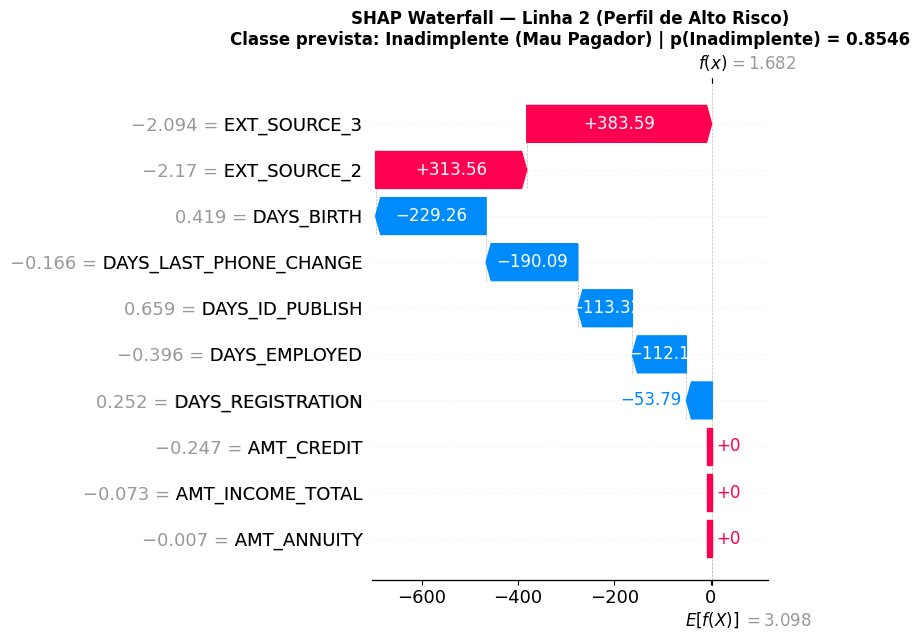

In [ ]:
# Waterfall Plot
exp = shap.Explanation(
    values=sv_vec,
    base_values=base_val,
    data=x1_scaled_df.values[0],
    feature_names=features_selecionadas_rl
)

shap.plots.waterfall(exp, show=False)
plt.title(f"SHAP Waterfall — Linha {linha} (Perfil de Alto Risco)\n"
          f"Classe prevista: {label2name.get(y_pred_1)} | p(Inadimplente) = {proba_1[1]:.4f}",
          fontweight='bold')
plt.tight_layout()
plt.show()

### Force Plot

O Force Plot (SHAP) explica a previsão de uma amostra específica. Mostra:

- Valor base E[f(X)] — a predição média do modelo no conjunto de teste; ponto de
  partida da explicação antes de considerar as características individuais do cliente;

- Setas vermelhas (push positive) — variáveis que aumentam a previsão em direção
  à classe prevista. Quanto mais larga a seta, maior a contribuição;

- Setas azuis (push negative) — variáveis que diminuem a previsão, puxando
  contra a classe prevista;

- Valor final f(x) — a predição do modelo para aquele cliente, depois de somar
  todas as contribuições individuais ao valor base.

SHAP Force Plot — Linha 2 (Perfil de Alto Risco)
p(Inadimplente) = 0.8546



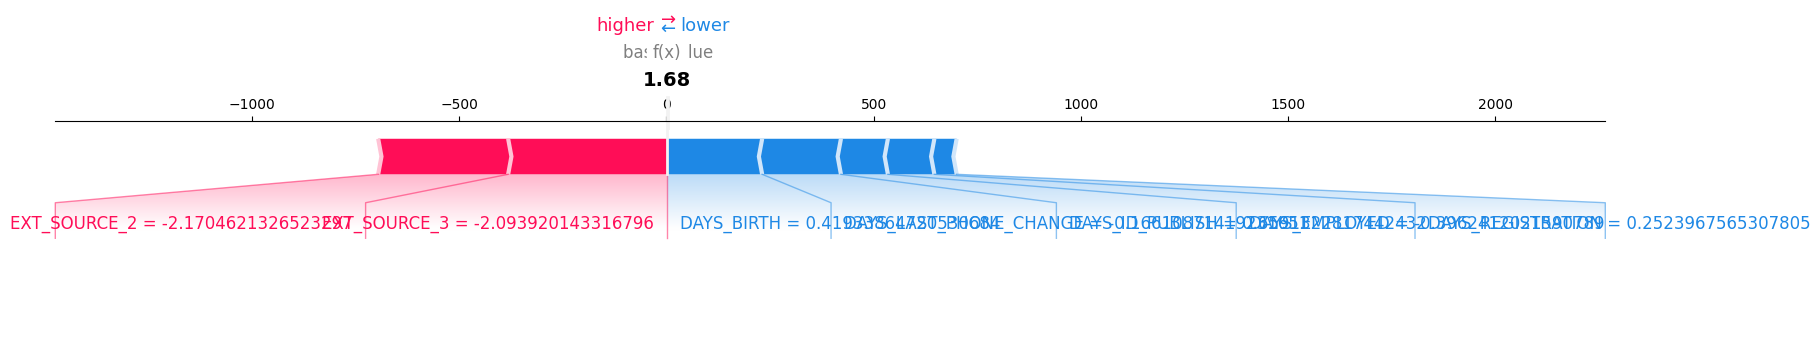

In [ ]:
import shap
import matplotlib.pyplot as plt

print(f"SHAP Force Plot — Linha {linha} (Perfil de Alto Risco)")
print(f"p(Inadimplente) = {proba_1[1]:.4f}")
print()

shap.force_plot(
    base_val,
    sv_vec,
    x1_scaled_df,
    feature_names=features_selecionadas_rl,
    matplotlib=True,
    show=True
)

#### Análise

> O Force Plot consolida visualmente as contribuições do Waterfall, mas em formato
> horizontal:
>
> - À esquerda (azul): forças que reduzem a probabilidade de inadimplência —
>   DAYS_BIRTH, DAYS_LAST_PHONE_CHANGE, DAYS_ID_PUBLISH, DAYS_EMPLOYED e
>   DAYS_REGISTRATION atuam como fatores protetores, todos com contribuição
>   negativa. Entre eles, DAYS_BIRTH apresenta a maior magnitude protetora,
>   seguido por DAYS_LAST_PHONE_CHANGE e DAYS_ID_PUBLISH. DAYS_EMPLOYED
>   contribui com estabilidade profissional e DAYS_REGISTRATION com menor
>   magnitude, ambos coerentes com o padrão geral do modelo;
>
> - À direita (vermelho): forças que aumentam a probabilidade de inadimplência —
>   dominadas por EXT_SOURCE_3 e EXT_SOURCE_2 baixos, que juntos respondem pela
>   maior parte do empurrão total na direção da inadimplência. As variáveis
>   financeiras brutas (AMT_CREDIT, AMT_ANNUITY, AMT_INCOME_TOTAL) não aparecem
>   como força de risco relevante, com contribuição próxima de zero para este perfil;
>
> - O valor final f(x) fica fortemente deslocado para a direita em relação ao valor
>   base, refletindo que as forças de risco superam amplamente as protetoras neste
>   perfil.
>
> A complementaridade entre o Waterfall e o Force Plot é intencional: o Waterfall
> detalha o caminho sequencial e quantitativo até a previsão, com cada contribuição
> expressa numericamente. O Force Plot sintetiza o balanço de forças em uma imagem
> única, priorizando a leitura visual imediata da direção e da proporção relativa
> de cada fator.
>
> Para relatórios de compliance e atendimento à LGPD, o Waterfall tende a ser mais
> adequado por sua leitura sequencial e quantitativa, que permite verificar o cálculo
> passo a passo. Para apresentações executivas e comitês de crédito, o Force Plot
> comunica a decisão de forma mais direta e acessível a audiências sem formação
> técnica em machine learning.

# Considerações Finais

## Forte desbalanceamento

A classe 0 (Bom Pagador) representa ~92% da base; a classe 1 (Inadimplente), apenas ~8%. Sem tratamento explícito, qualquer classificador atinge ~92% de acurácia simplesmente prevendo "0 para todos" — resultado tecnicamente correto, mas operacionalmente inútil para o problema de negócio. A estratégia `class_weight='balanced'` foi adotada como mecanismo de compensação, fazendo com que cada inadimplente contribua com peso ~11× maior para a função de perda durante o treinamento.

## Métrica principal alcançada

Conforme a régua quantitativa definida na seção "Definição da Métrica Principal de Avaliação", o modelo Base (parâmetros manuais, `C=0.1`, `penalty='l2'`, `solver='lbfgs'`) atingiu, na avaliação final sobre o conjunto de teste:

- **Recall (Inadimplente) = 0,6433** → meta do projeto superada (≥ 0,50) ✅
- **Balanced Accuracy = 0,6600** → patamar mínimo superado (≥ 0,60) ✅
- **FP rate = 0,3233** → dentro do limite gerenciável (≤ 30%) ✅

O pipeline otimizado (`RandomizedSearchCV`, 50 combinações, `cv=5`) foi avaliado com as mesmas métricas:

- **Recall (Inadimplente) = 0,6427**
- **Balanced Accuracy = 0,6600**
- **FP rate = 0,3227**

Os resultados do pipeline otimizado são praticamente idênticos ao modelo base, com diferenças da ordem de 0,0006 em todas as métricas. Isso indica que a escolha manual de `C=0.1` já estava próxima do ótimo para este dataset. A busca encontrou `C=3.746`, `class_weight='balanced'` e `penalty='l2'` como melhores hiperparâmetros, com Recall médio de validação cruzada de **0,6421** — coerente com o resultado no teste.

Vale registrar a correção metodológica feita nesta etapa: na versão anterior do pipeline, a busca utilizava `scoring='balanced_accuracy'`, o que causava colapso completo da detecção (Recall = 0,000, Balanced Accuracy = 0,500). Isso ocorria porque a `balanced_accuracy` aceita configurações que acertam bem a classe majoritária sem necessariamente detectar inadimplentes — o otimizador encontrava valores altos de `C` que enfraqueciam a regularização e faziam o modelo convergir para prever quase exclusivamente a classe 0. A correção foi substituir a métrica da busca por `Recall (Inadimplente)` diretamente via `make_scorer`, alinhando o critério de seleção de hiperparâmetros ao objetivo central do projeto. Adicionalmente, o `class_weight` foi incluído no espaço de busca e o `.fit()` passou a receber `X_train_raw` (dados brutos) em vez de `X_train_rl` (já padronizado), eliminando uma dupla padronização que ocorria porque o pipeline aplica o `StandardScaler` internamente.

Pela régua estabelecida a priori, o modelo é **operacionalmente aceitável**. A acurácia global de 0,67 abaixo dos ~92% triviais não é fraqueza — é evidência de que o `class_weight='balanced'` está funcionando como projetado: o modelo sacrifica acurácia geral para capturar inadimplentes.

## Efeito do SMOTE — resultado contra-intuitivo

Diferentemente do esperado pela literatura, o oversampling sintético piorou as métricas neste experimento: Recall da classe Inadimplente, Balanced Accuracy e Macro-F1 caíram em relação ao modelo Base. As hipóteses mais prováveis são: (i) com ~246 mil registros de treino, o `class_weight='balanced'` já compensa o desbalanceamento de forma adequada, tornando o oversampling redundante; (ii) o SMOTE gera amostras sintéticas em regiões do espaço de features onde as combinações de `EXT_SOURCE_2` e `EXT_SOURCE_3` raramente ocorrem na prática, introduzindo ruído em vez de sinal. O modelo Base, sem SMOTE, permanece como variante preferida.

## Calibração de probabilidades — trade-off severo

A Regressão Logística entrega probabilidades **estruturalmente mais calibradas** que modelos baseados em árvore, pois a função sigmoide é matematicamente uma função de probabilidade bem definida. O Brier score e o ECE do modelo Base refletem essa vantagem nativa. Contudo, ao aplicar `CalibratedClassifierCV` (sigmoid ou isotonic, `cv=5`), a calibração padrão retreina internamente o modelo e neutraliza o efeito do `class_weight='balanced'`, colapsando o Recall da classe Inadimplente para valores próximos de zero — o mesmo padrão destrutivo observado em experimentos anteriores com outros algoritmos. Conclusão: o fluxo padrão de calibração não é apropriado neste experimento. Para uso em pricing e provisionamento sem perda de detecção, a calibração deve ser aplicada apenas a posteriori sobre as probabilidades do modelo já treinado, sem retreino interno, ou o limiar de decisão deve ser ajustado diretamente via curva ROC/PR.

## Observação sobre os valores SHAP na simulação

Os valores SHAP exibidos na célula de explicação individual (Linha 2 — perfil de alto risco) apresentam magnitudes elevadas (`EXT_SOURCE_3 = 383,59`, `EXT_SOURCE_2 = 313,56`) e um valor base de **3,0978**, bem acima do intervalo [0, 1] esperado para probabilidades. Isso é um comportamento conhecido do `shap.LinearExplainer` com `feature_perturbation="correlation_dependent"` quando aplicado sobre dados padronizados: os valores SHAP operam no espaço do log-odds (escala irrestrita), não no espaço de probabilidade diretamente. A direção das contribuições (positivo = aumenta risco, negativo = reduz risco) e o ranking de importância entre features permanecem completamente válidos para interpretação — `EXT_SOURCE_3` e `EXT_SOURCE_2` são os principais fatores de risco, enquanto `DAYS_EMPLOYED`, `DAYS_BIRTH` e `DAYS_LAST_PHONE_CHANGE` atuam como fatores protetores. Para obter valores SHAP no espaço de probabilidade [0, 1], seria necessário aplicar o `LinearExplainer` com `feature_perturbation="interventional"` e usar `link="logit"` na visualização.

## Explicabilidade

`EXT_SOURCE_2` e `EXT_SOURCE_3` dominam absolutamente o poder preditivo em todos os métodos de interpretabilidade analisados — coeficientes padronizados, Permutation Importance e SHAP convergem para o mesmo ranking. `DAYS_EMPLOYED` (tempo de emprego) ocupa consistentemente o 3º lugar, seguido por `DAYS_BIRTH` (idade). Os três métodos confirmam ainda uma divergência relevante: a Permutation Importance calculada sobre o F1-macro revela que apenas os scores externos têm impacto positivo líquido na métrica geral; as demais features apresentam contribuição marginal ou nula quando avaliadas isoladamente. O `shap.LinearExplainer`, aplicado de forma analítica sobre o conjunto de teste, habilita explicações individualizadas por cliente — atendendo ao art. 20 da LGPD, que garante ao titular o direito de solicitar revisão de decisões automatizadas.

## Trade-off de negócio

O modelo atual recusa uma fração dos bons pagadores (FP rate = 0,3233) para capturar 0,6433 dos inadimplentes (Recall). A calibração do limiar de decisão com base na matriz de custos da instituição é o próximo passo natural: reduzir o limiar (ex.: de 0,5 para 0,3) aumenta o Recall ao custo de mais falsos positivos; elevá-lo reduz as recusas indevidas ao custo de deixar passar mais inadimplentes. A curva Precision-Recall gerada na avaliação final fornece a superfície completa para essa decisão.

**Modelo recomendado:** Regressão Logística Base com `C=0.1`, `penalty='l2'`, `solver='lbfgs'` e `class_weight='balanced'`, sem `CalibratedClassifierCV` padrão.

- Parâmetros finais disponíveis em `model_rl` (impressos na seção Parametrização)
- Resultados no teste: Recall = 0,6433 | Balanced Accuracy = 0,6600 | FP rate = 0,3233
- Coeficientes interpretáveis por feature em log-odds — atende à auditoria e à LGPD
- **NÃO usar SMOTE** neste dataset com a configuração atual (todas as métricas relevantes pioraram em relação ao Base)
- **NÃO usar `CalibratedClassifierCV`** em sua forma padrão (retreino interno neutraliza o `class_weight='balanced'` e colapsa a detecção de inadimplência)